# MBRSET Patient-Level Evaluation — `task_any_dr` (Binary DR Detection)

**Run 16b (R16b):** Bag-Mixup Equal-Avg Top-3 Aggressive Ensemble **F1 = 0.658** (all-time best)

| Config | Best F1 | Method | Notes |
|--------|---------|--------|-------|
| R14 | 0.574 | Best single (dinov2_shanghai) | 7/7 GOOD FIT, baseline |
| R15c | 0.623 | Equal-Avg Top-5 ensemble | +mae_shanghai alpha fix |
| R16 | 0.647 | Calibrated-Avg Top-3 | +Platt calibration, 4 methods tested |
| **R16b** | **0.658** | **Bag-Mixup Equal-Avg Top-3** | **+5-seed bagging, mixup aug, arch sweep** |

- **Checkpoint:** `results/checkpoint_run16b/`
- **Patient split:** Frozen from R14 (1032 train / 259 test)
- **Top-3 members:** dinov2_shanghai, dinov3_vitb16, convnextv2

## 1. Setup and Imports

In [1]:
import os
import copy
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    log_loss,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

import src.retina_evaluation as reval
from src.retina_benchmark import list_embeddings_csvs
from src.retina_embeddings_dataset import load_retina_embeddings_dataset

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")

print("Imports complete.")

Imports complete.


## 2. Configuration

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# R15c Configuration — task_any_dr (Binary DR Detection)
# ═══════════════════════════════════════════════════════════════════════════════
# 7 individual embedding models, each trained/evaluated separately
# PCA=128, cosine LR schedule, per-embedding alpha overrides
# Checkpoint: results/mbrset_patient_eval_any_dr/
# ═══════════════════════════════════════════════════════════════════════════════

# Paths and dataset
PROJECT_ROOT = Path.cwd()
DATASET_NAME = "mbrset"
VIEW = "macula"

# Split configuration — frozen from checkpoint_run14
RANDOM_SEED = 42
TRAIN_FRAC = 0.8
TEST_FRAC = 0.2

# Task definitions — SINGLE TASK: any_dr
BINARY_TASKS = ["task_any_dr"]
BINARY_TASK_MAP = {
    "task_any_dr": "task_any_diab_retino",
}

CPU_COUNT = os.cpu_count() or 1

USE_PCA = True
PCA_N_COMPONENTS = 128

# ——— BAYESIAN HYPERPARAMETER SEARCH (disabled — fixed config) ———
USE_BAYESIAN_SEARCH = False
N_BAYES_ITER = 30
BAYES_CV_FOLDS = 3

ARCHITECTURE_OPTIONS = [
    (64,),
    (128,),
    (64, 64),
    (128, 128),
    (256, 128),
    (256, 256),
]

SEARCH_SPACE = {
    'hidden_layer_sizes': Integer(0, len(ARCHITECTURE_OPTIONS) - 1),
    'alpha': Categorical([0.0001, 0.001, 0.01]),
    'learning_rate_init': Real(5e-4, 2e-3, prior='log-uniform'),
    'batch_size': Categorical([128]),
}

# ——— WEIGHTING CONFIGURATION ———
WEIGHTING_CONFIG = {
    "binary": {
        "mode": "balanced",
        "manual": {0: 1.0, 1: 1.0},
        "damping_gamma": 1.0,
    },
}
USE_EMBEDDING_TASK_WEIGHT_OVERRIDES = True
THRESHOLD_GRID_SIZE = 201
MLP_USE_SAMPLE_WEIGHT = True
RUN_WEIGHTED_VERSION = True
RUN_UNWEIGHTED_VERSION = False

# Threshold selection
THRESHOLD_METHOD = "f1"
THRESHOLD_GRID_SIZE = 201

# ——— BASE MLP CONFIG ———
MLP_CONFIG_BINARY = {
    "hidden_layer_sizes": (256, 128),
    "alpha": 0.06,
    "learning_rate_init": 0.0005,
    "lr_min": 1e-5,
    "lr_schedule": "cosine",
    "batch_size": 64,
    "max_epochs": 300,
    "patience": 50,
    "min_delta": 1e-4,
    "warmup_epochs": 20,
}

# ——— PER-EMBEDDING ALPHA OVERRIDES ———
EMBEDDING_OVERRIDES = {
    "dinov3_convnext_base": {"alpha": 0.03},
    "dinov3_vitb16": {},                         # base alpha=0.06
    "RETFound_mae_shanghai": {"alpha": 0.07},    # R15c change (was 0.04 in R14)
    "RETFound_mae_natureCFP": {"alpha": 0.03},
    "RETFound_dinov2_shanghai": {"alpha": 0.05},
    "vit_base": {"alpha": 0.05},
    "convnextv2_base": {"alpha": 0.05},
}

# Empty configs — sweep cell populates at runtime
WEIGHTING_OVERRIDES_CONFIG = {}
THRESHOLD_OVERRIDES_CONFIG = {}

def resolve_config(emb_stem):
    """Merge base config with per-embedding overrides."""
    base = MLP_CONFIG_BINARY.copy()
    matched = None
    for pattern, overrides in EMBEDDING_OVERRIDES.items():
        if pattern in emb_stem:
            if overrides:
                base.update(overrides)
                matched = pattern
            break
    return base, matched

# Output configuration
RESULTS_DIR = PROJECT_ROOT / "results" / "mbrset_patient_eval_any_dr"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
SAVE_PLOTS = True

# ——— Ensemble configuration ———
ENSEMBLE_TOP_N = [3, 4, 5, 7]

print(f"Dataset: {DATASET_NAME}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Random seed: {RANDOM_SEED}")
print(f"Split: Train={TRAIN_FRAC:.0%}, Test={TEST_FRAC:.0%}")
print(f"PCA: {PCA_N_COMPONENTS} components")
print(f"Threshold method: {THRESHOLD_METHOD} (grid={THRESHOLD_GRID_SIZE})")
print(f"Per-embedding weight overrides: {'ENABLED' if USE_EMBEDDING_TASK_WEIGHT_OVERRIDES else 'DISABLED'}")
print(f"Architecture: {MLP_CONFIG_BINARY['hidden_layer_sizes']}, alpha={MLP_CONFIG_BINARY['alpha']}, lr={MLP_CONFIG_BINARY['learning_rate_init']}, schedule={MLP_CONFIG_BINARY['lr_schedule']}")
print(f"Batch size: {MLP_CONFIG_BINARY['batch_size']}")
print(f"Max epochs: {MLP_CONFIG_BINARY['max_epochs']}, Patience: {MLP_CONFIG_BINARY['patience']}, Warmup: {MLP_CONFIG_BINARY['warmup_epochs']}")
print(f"\nPer-embedding overrides:")
for k, v in EMBEDDING_OVERRIDES.items():
    if v:
        parts = []
        if 'alpha' in v:
            parts.append(f"alpha={v['alpha']}")
        if 'hidden_layer_sizes' in v:
            parts.append(f"arch={v['hidden_layer_sizes']}")
        if not parts:
            parts.append(f"(base)")
        print(f"  {k}: {', '.join(parts)}")
    else:
        print(f"  {k}: (base alpha={MLP_CONFIG_BINARY['alpha']}, arch={MLP_CONFIG_BINARY['hidden_layer_sizes']})")

Dataset: mbrset
Results directory: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_patient_eval_any_dr
Random seed: 42
Split: Train=80%, Test=20%
PCA: 128 components
Threshold method: f1 (grid=201)
Per-embedding weight overrides: ENABLED
Architecture: (256, 128), alpha=0.06, lr=0.0005, schedule=cosine
Batch size: 64
Max epochs: 300, Patience: 50, Warmup: 20

Per-embedding overrides:
  dinov3_convnext_base: alpha=0.03
  dinov3_vitb16: (base alpha=0.06, arch=(256, 128))
  RETFound_mae_shanghai: alpha=0.07
  RETFound_mae_natureCFP: alpha=0.03
  RETFound_dinov2_shanghai: alpha=0.05
  vit_base: alpha=0.05
  convnextv2_base: alpha=0.05


## 3. Load Embeddings and Create Patient-Level Split

In [3]:
# Get paths
embed_dir = PROJECT_ROOT / "data" / f"{DATASET_NAME}_embeddings"
labels_path = embed_dir / f"{DATASET_NAME}_labels" / f"labels_{DATASET_NAME}.csv"

# List all embedding files
embedding_files = list_embeddings_csvs(embed_dir)
if not embedding_files:
    raise FileNotFoundError(f"No embedding CSV files found under {embed_dir}")

print(f"Found {len(embedding_files)} embedding files:")
for i, emb in enumerate(embedding_files):
    print(f"  {i}: {emb.name}")

# ——— LOAD FROZEN PATIENT SPLIT from R14 (same split as combined notebook) ———
# CRITICAL: Both task notebooks must use the SAME patient split for comparable results.
# The canonical split was created in the combined notebook stratified by task_any_dr.
_frozen_split_path = PROJECT_ROOT / "results" / "checkpoint_run14" / "patient_split.csv"
if not _frozen_split_path.exists():
    # Fallback: try the combined notebook's output
    _frozen_split_path = PROJECT_ROOT / "results" / "mbrset_patient_eval" / "patient_split.csv"
if not _frozen_split_path.exists():
    raise FileNotFoundError(
        f"Frozen patient split not found. Expected at:\n"
        f"  {PROJECT_ROOT / 'results' / 'checkpoint_run14' / 'patient_split.csv'}\n"
        f"  {PROJECT_ROOT / 'results' / 'mbrset_patient_eval' / 'patient_split.csv'}"
    )

_split_df = pd.read_csv(_frozen_split_path, dtype=str)
train_patient_ids = set(_split_df.loc[_split_df["split"] == "train", "patient_id"])
test_patient_ids = set(_split_df.loc[_split_df["split"] == "test", "patient_id"])

total = len(train_patient_ids) + len(test_patient_ids)
print(f"\nLoaded FROZEN patient split from: {_frozen_split_path}")
print(f"  Train patients: {len(train_patient_ids)} ({len(train_patient_ids)/total:.0%})")
print(f"  Test patients:  {len(test_patient_ids)} ({len(test_patient_ids)/total:.0%})")
print(f"  Total: {total}")

# Copy split to this notebook's results dir for traceability
split_info = _split_df.copy()
split_info.to_csv(RESULTS_DIR / "patient_split.csv", index=False)
print(f"Copied split to: {RESULTS_DIR / 'patient_split.csv'}")

Found 7 embedding files:
  0: Embeddings_convnextv2_base_mbrset.csv
  1: Embeddings_mbrset_dinov3_convnext_base.csv
  2: Embeddings_mbrset_dinov3_vitb16.csv
  3: Embeddings_mbrset_RETFound_dinov2_shanghai.csv
  4: Embeddings_mbrset_RETFound_mae_natureCFP.csv
  5: Embeddings_mbrset_RETFound_mae_shanghai.csv
  6: Embeddings_vit_base_mbrset.csv

Loaded FROZEN patient split from: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\checkpoint_run14\patient_split.csv
  Train patients: 1032 (80%)
  Test patients:  259 (20%)
  Total: 1291
Copied split to: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_patient_eval_any_dr\patient_split.csv


## 4. Helper Functions for Patient-Level Aggregation

In [4]:
from sklearn.utils.class_weight import compute_class_weight
import math


def aggregate_patient_predictions(df, group_col="patient_id"):
    """
    Aggregate image-level predictions to patient-level.
    Uses max() for labels/predictions: if ANY image is positive, the patient is positive.
    This avoids mode() ties silently relabeling DR-positive patients as negative.
    """
    patient_groups = []
    
    for patient_id, group in df.groupby(group_col):
        y_pred_patient = int(group["y_pred"].max())   # positive if ANY image predicted positive
        y_proba_patient = group["y_proba"].mean()
        y_true_patient = int(group["y_true"].max())    # positive if ANY image is positive
        
        patient_groups.append({
            "patient_id": patient_id,
            "y_true": y_true_patient,
            "y_pred": y_pred_patient,
            "y_proba": y_proba_patient,
            "n_images": len(group),
        })
    
    return pd.DataFrame(patient_groups)


def compute_balanced_weights(y, damping_gamma=0.7):
    """Compute balanced sample weights with damping."""
    y = np.asarray(y)
    if y.size == 0:
        return np.asarray([], dtype=np.float32)
    classes = np.unique(y)
    class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    if damping_gamma is not None and float(damping_gamma) != 1.0:
        class_weights = class_weights ** float(damping_gamma)
    weight_map = {int(c): float(w) for c, w in zip(classes, class_weights)}
    sample_weights = np.array([weight_map[int(lbl)] for lbl in y], dtype=np.float32)
    mean_w = float(np.mean(sample_weights))
    if mean_w > 0:
        sample_weights = sample_weights / mean_w
    return sample_weights


def compute_class_weight_mapping(y, mode="balanced", manual_class_weight=None, damping_gamma=1.0):
    """Return a {class_label: weight} mapping."""
    y = np.asarray(y)
    classes = np.unique(y)
    if classes.size == 0:
        return {}
    if mode == "none":
        mapping = {int(c): 1.0 for c in classes}
    elif mode == "manual":
        manual_class_weight = manual_class_weight or {}
        mapping = {int(c): float(manual_class_weight.get(int(c), 1.0)) for c in classes}
    elif mode == "balanced":
        w = compute_class_weight(class_weight="balanced", classes=classes, y=y)
        mapping = {int(c): float(wi) for c, wi in zip(classes, w)}
    else:
        raise ValueError(f"Unknown weighting mode: {mode}")
    if damping_gamma is not None and float(damping_gamma) != 1.0:
        gamma = float(damping_gamma)
        mapping = {c: float(w ** gamma) for c, w in mapping.items()}
    return mapping


def compute_sample_weights(y, class_weight_mapping, normalize=True):
    """Convert a {class: weight} mapping to per-sample weights."""
    y = np.asarray(y)
    if y.size == 0:
        return np.asarray([], dtype=np.float32)
    sw = np.array([class_weight_mapping.get(int(lbl), 1.0) for lbl in y], dtype=np.float32)
    if normalize and sw.size:
        mean_w = float(np.mean(sw))
        if mean_w > 0:
            sw = sw / mean_w
    return sw


def safe_fit_with_optional_sample_weight(estimator, X, y, sample_weight=None):
    """Fit with sample_weight if supported; otherwise fall back to unweighted fit."""
    if sample_weight is None:
        estimator.fit(X, y)
        return False
    try:
        estimator.fit(X, y, sample_weight=sample_weight)
        return True
    except TypeError:
        estimator.fit(X, y)
        return False


def find_optimal_threshold(y_true, y_proba, method="youden", grid_size=99):
    """Find optimal binary classification threshold."""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    if y_true.size == 0:
        return 0.5
    if method == "youden":
        fpr, tpr, thresholds = roc_curve(y_true, y_proba)
        j_scores = tpr - fpr
        best_idx = int(np.argmax(j_scores))
        return float(thresholds[best_idx])
    if method == "f1":
        from sklearn.metrics import f1_score
        grid_size = max(11, min(int(grid_size), 1001))
        thresholds = np.linspace(0.01, 0.99, grid_size)
        best_t, best_f1 = 0.5, -1.0
        for t in thresholds:
            y_pred = (y_proba >= t).astype(int)
            f1 = float(f1_score(y_true, y_pred, zero_division=0))
            if f1 > best_f1:
                best_f1 = f1
                best_t = float(t)
        return best_t
    raise ValueError(f"Unknown threshold method: {method}")


def weighted_log_loss(y_true, y_proba, labels, sample_weight=None):
    """Compute log loss with optional sample weights."""
    return log_loss(y_true, y_proba, labels=labels, sample_weight=sample_weight)


# ——— COSINE LR SCHEDULE ———

def cosine_lr(epoch, max_epochs, lr_init, lr_min=1e-5, warmup_epochs=10):
    """
    Cosine annealing learning rate with linear warmup.
    
    During warmup (epoch <= warmup_epochs): linear ramp from lr_min to lr_init.
    After warmup: cosine decay from lr_init to lr_min.
    """
    if epoch <= warmup_epochs:
        return lr_min + (lr_init - lr_min) * (epoch / max(1, warmup_epochs))
    progress = (epoch - warmup_epochs) / max(1, max_epochs - warmup_epochs)
    return lr_min + 0.5 * (lr_init - lr_min) * (1 + math.cos(math.pi * progress))


def train_mlp_with_schedule(X_train, y_train, X_val, y_val, mlp_cfg,
                             sample_weight_train=None, sample_weight_val=None,
                             random_seed=42):
    """
    Train MLPClassifier with cosine LR schedule, warmup, and manual early stopping.
    
    Uses warm_start=True with max_iter=1 for epoch-by-epoch control.
    Modifies sklearn's internal optimizer lr each epoch for cosine annealing.
    
    Returns:
        (best_model, best_epoch, train_losses, val_losses)
    """
    lr_init = mlp_cfg["learning_rate_init"]
    lr_min = mlp_cfg.get("lr_min", 1e-5)
    lr_schedule = mlp_cfg.get("lr_schedule", "constant")
    warmup = mlp_cfg.get("warmup_epochs", 0)
    max_epochs = mlp_cfg["max_epochs"]
    patience = mlp_cfg["patience"]
    min_delta = mlp_cfg.get("min_delta", 1e-4)

    # Set epoch-1 lr for correct warmup start
    epoch1_lr = cosine_lr(1, max_epochs, lr_init, lr_min, warmup) if lr_schedule == "cosine" else lr_init

    mlp = MLPClassifier(
        hidden_layer_sizes=mlp_cfg["hidden_layer_sizes"],
        alpha=mlp_cfg["alpha"],
        learning_rate_init=epoch1_lr,
        batch_size=mlp_cfg["batch_size"],
        max_iter=1,
        warm_start=True,
        early_stopping=False,
        random_state=random_seed,
    )

    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    best_epoch = 0
    best_model = None
    patience_counter = 0
    labels = np.unique(np.concatenate([y_train, y_val]))

    for epoch in range(1, max_epochs + 1):
        # Cosine LR schedule with warmup
        if lr_schedule == "cosine" and epoch > 1 and hasattr(mlp, '_optimizer'):
            new_lr = cosine_lr(epoch, max_epochs, lr_init, lr_min, warmup)
            mlp._optimizer.learning_rate = new_lr

        safe_fit_with_optional_sample_weight(mlp, X_train, y_train, sample_weight=sample_weight_train)

        train_proba = mlp.predict_proba(X_train)
        val_proba = mlp.predict_proba(X_val)

        tr_loss = float(weighted_log_loss(y_train, train_proba, labels=labels, sample_weight=sample_weight_train))
        va_loss = float(weighted_log_loss(y_val, val_proba, labels=labels, sample_weight=sample_weight_val))

        train_losses.append(tr_loss)
        val_losses.append(va_loss)

        if va_loss < best_val_loss - min_delta:
            best_val_loss = va_loss
            best_epoch = epoch
            best_model = copy.deepcopy(mlp)
            patience_counter = 0
        elif epoch > warmup:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return best_model, best_epoch, train_losses, val_losses


# ——— WRAPPER CLASS FOR BAYESIAN SEARCH ———
from sklearn.base import BaseEstimator, ClassifierMixin

class MLPWrapperForBayesSearch(BaseEstimator, ClassifierMixin):
    """Wrapper for MLPClassifier that converts integer architecture indices to tuples."""
    def __init__(self, hidden_layer_sizes=0, alpha=0.01, learning_rate_init=0.001, 
                 batch_size=64, max_iter=400, early_stopping=True, validation_fraction=0.15,
                 n_iter_no_change=10, random_state=42, warm_start=False):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change
        self.random_state = random_state
        self.warm_start = warm_start
        self._mlp = None
    
    def _get_architecture(self):
        if isinstance(self.hidden_layer_sizes, int):
            return ARCHITECTURE_OPTIONS[self.hidden_layer_sizes]
        return self.hidden_layer_sizes
    
    def fit(self, X, y, sample_weight=None):
        arch = self._get_architecture()
        self._mlp = MLPClassifier(
            hidden_layer_sizes=arch, alpha=self.alpha,
            learning_rate_init=self.learning_rate_init, batch_size=self.batch_size,
            max_iter=self.max_iter, early_stopping=self.early_stopping,
            validation_fraction=self.validation_fraction,
            n_iter_no_change=self.n_iter_no_change,
            random_state=self.random_state, warm_start=self.warm_start,
        )
        if sample_weight is not None:
            self._mlp.fit(X, y, sample_weight=sample_weight)
        else:
            self._mlp.fit(X, y)
        self.classes_ = self._mlp.classes_
        self.n_iter_ = self._mlp.n_iter_
        self.loss_ = self._mlp.loss_
        self.best_loss_ = self._mlp.best_loss_ if hasattr(self._mlp, 'best_loss_') else None
        return self
    
    def predict(self, X):
        return self._mlp.predict(X)
    
    def predict_proba(self, X):
        return self._mlp.predict_proba(X)
    
    def score(self, X, y, sample_weight=None):
        return self._mlp.score(X, y, sample_weight=sample_weight)


def plot_confusion_matrix(cm, title, save_path=None, show=True):
    """Plot confusion matrix."""
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    im = ax.imshow(cm, cmap="viridis", interpolation="nearest")
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))
    ax.tick_params(axis="both", labelsize=9)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=9)
    cbar.set_label("Count", fontsize=9)
    thresh = cm.max() / 2.0 if cm.size else 0
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f"{val}", ha="center", va="center",
                color="white" if val > thresh else "black", fontsize=10, fontweight="bold")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_roc_curve(fpr, tpr, auc, title, save_path=None, show=True):
    """Plot ROC curve."""
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = Normalize(vmin=0.0, vmax=1.0)
    lc = LineCollection(segments, cmap="plasma", norm=norm)
    lc.set_array(fpr)
    lc.set_linewidth(2.6)
    ax.add_collection(lc)
    ax.plot([0, 1], [0, 1], linestyle="--", color="#666", linewidth=1.2, label="Chance")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"{title}\nAUC = {auc:.3f}", fontsize=11, pad=12)
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.tick_params(axis="both", labelsize=9)
    ax.legend(loc="lower right", fontsize=9)
    cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("FPR", fontsize=9)
    cbar.ax.tick_params(labelsize=9)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


print("Helper functions defined.")

Helper functions defined.


In [7]:
# ——— Per-embedding weight sweep (patient-level, vectorized) ———
# Uses inner split from training data (85/15) to find optimal pos_weight and threshold.
# Results stored in WEIGHTING_OVERRIDES and THRESHOLD_OVERRIDES for Cell 13.

import json

WEIGHTING_OVERRIDES = {}
THRESHOLD_OVERRIDES = {}

# Sweep config
SWEEP_TARGET_PATTERNS = ["RETFound", "dinov3", "vit_base", "convnextv2"]
SWEEP_MAX_EMBEDDINGS = None
# R15c: Reverted to R14 weight cap=8. R15b showed cap=4 + PCA=192 degraded
# dynamics (4/7 GOOD FIT vs R14's 7/7). PCA=128 + cap=8 is the proven config.
# Threshold floor=0.30 prevents clinically inappropriate low thresholds.
SWEEP_POS_WEIGHTS = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.6, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0]
SWEEP_THRESHOLD_FLOOR = 0.30  # Minimum threshold - prevents clinically inappropriate low thresholds
SWEEP_THRESH_GRID = max(31, min(int(THRESHOLD_GRID_SIZE), 401))
SWEEP_INNER_VAL_FRAC = 0.15
SWEEP_RANDOM_SEED = RANDOM_SEED + 777

selected_embedding_files = [
    emb for emb in embedding_files
    if any(p.lower() in emb.stem.lower() for p in SWEEP_TARGET_PATTERNS)
]
if SWEEP_MAX_EMBEDDINGS:
    selected_embedding_files = selected_embedding_files[:SWEEP_MAX_EMBEDDINGS]

print("[Weight sweep] Starting per-embedding/per-task sweep...")
print(f"  Inner val fraction from train: {SWEEP_INNER_VAL_FRAC}")
print(f"  Selected embeddings: {len(selected_embedding_files)} / {len(embedding_files)}")
for emb in selected_embedding_files:
    print(f"    - {emb.stem}")
print(f"  Pos weights: {SWEEP_POS_WEIGHTS}")
print(f"  Max weight: {max(SWEEP_POS_WEIGHTS)}")
print(f"  Threshold floor: {SWEEP_THRESHOLD_FLOOR}")
print(f"  Threshold grid: {SWEEP_THRESH_GRID}")

rows = []
thresholds = np.linspace(0.01, 0.99, SWEEP_THRESH_GRID)
thresholds = thresholds[thresholds >= SWEEP_THRESHOLD_FLOOR]  # R14: enforce floor

for emb_path in selected_embedding_files:
    emb_stem = emb_path.stem
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
        view=VIEW,
    )

    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)
    train_all = all_df[all_df['patient_id'].isin(train_patient_ids)].copy()

    for task in BINARY_TASKS:
        if task not in train_all.columns:
            continue

        task_df = train_all.dropna(subset=[task]).copy()
        if task_df.empty:
            continue

        # Inner patient-level split from training data
        inner_split = reval.make_patient_split(
            df=task_df,
            group_col="patient_id",
            label_col=task,
            val_frac=SWEEP_INNER_VAL_FRAC,
            seed=SWEEP_RANDOM_SEED,
        )
        inner_train_pids = set(str(p) for p in inner_split.train_patient_ids)
        inner_val_pids = set(str(p) for p in inner_split.val_patient_ids)

        inner_tr = task_df[task_df['patient_id'].isin(inner_train_pids)].copy()
        inner_va = task_df[task_df['patient_id'].isin(inner_val_pids)].copy()

        if inner_tr.empty or inner_va.empty:
            continue

        # Featurize
        X_tr = inner_tr.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
        y_tr = inner_tr[task].astype(int).to_numpy()
        X_va = inner_va.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
        y_va = inner_va[task].astype(int).to_numpy()

        if len(np.unique(y_tr)) < 2 or len(np.unique(y_va)) < 2:
            continue

        if USE_PCA:
            pca_sw = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_SEED)
            X_tr = pca_sw.fit_transform(X_tr)
            X_va = pca_sw.transform(X_va)

        scaler_sw = StandardScaler()
        X_tr_s = scaler_sw.fit_transform(X_tr)
        X_va_s = scaler_sw.transform(X_va)

        mlp_cfg, _ = resolve_config(emb_stem)
        best = None

        for w_pos in SWEEP_POS_WEIGHTS:
            cw = {0: 1.0, 1: float(w_pos)}
            sw = compute_sample_weights(y_tr, cw, normalize=True)

            mlp = MLPClassifier(
                hidden_layer_sizes=mlp_cfg["hidden_layer_sizes"],
                alpha=mlp_cfg["alpha"],
                learning_rate_init=mlp_cfg["learning_rate_init"],
                batch_size=mlp_cfg["batch_size"],
                max_iter=mlp_cfg["max_epochs"],
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=mlp_cfg["patience"],
                random_state=SWEEP_RANDOM_SEED,
            )
            safe_fit_with_optional_sample_weight(mlp, X_tr_s, y_tr, sample_weight=sw)

            va_proba_img = mlp.predict_proba(X_va_s)[:, 1]

            # —— FAST patient-level aggregation (once per weight) ——
            va_agg = pd.DataFrame({
                "patient_id": inner_va["patient_id"].values,
                "y_true": y_va,
                "y_proba": va_proba_img,
            }).groupby("patient_id").agg(
                y_true=("y_true", "max"),
                y_proba=("y_proba", "mean"),
            )
            y_pt = va_agg["y_true"].to_numpy()
            p_pt = va_agg["y_proba"].to_numpy()

            # Vectorized threshold sweep on patient-level arrays (floor enforced)
            best_t, best_f1, best_p, best_r = 0.5, -1.0, 0.0, 0.0
            for t in thresholds:
                yp = (p_pt >= t).astype(int)
                f1v = float(f1_score(y_pt, yp, zero_division=0))
                if f1v > best_f1:
                    best_f1 = f1v
                    best_t = float(t)
                    best_p = float(precision_score(y_pt, yp, zero_division=0))
                    best_r = float(recall_score(y_pt, yp, zero_division=0))

            auc_val = float(roc_auc_score(y_pt, p_pt)) if len(np.unique(y_pt)) == 2 else float("nan")

            cand = {
                "embedding": emb_stem,
                "task": task,
                "pos_weight": float(w_pos),
                "threshold": float(best_t),
                "val_patient_f1": float(best_f1),
                "val_patient_precision": float(best_p),
                "val_patient_recall": float(best_r),
                "val_patient_auc": float(auc_val),
            }
            if (best is None
                or cand["val_patient_f1"] > best["val_patient_f1"] + 1e-9
                or (abs(cand["val_patient_f1"] - best["val_patient_f1"]) <= 1e-9
                    and cand["val_patient_recall"] > best["val_patient_recall"])):
                best = cand

        if best is not None:
            rows.append(best)
            WEIGHTING_OVERRIDES.setdefault(emb_stem, {})[task] = {
                "mode": "manual",
                "manual": {0: 1.0, 1: float(best["pos_weight"])},
                "damping_gamma": 1.0,
            }
            THRESHOLD_OVERRIDES.setdefault(emb_stem, {})[task] = float(best["threshold"])
            print(f"  [sweep] {emb_stem} / {task}: w={best['pos_weight']}, "
                  f"t={best['threshold']:.2f}, F1={best['val_patient_f1']:.3f}, "
                  f"P={best['val_patient_precision']:.3f}, R={best['val_patient_recall']:.3f}")

sweep_df = pd.DataFrame(rows)
if sweep_df.empty:
    print("\n[Weight sweep] No valid results.")
else:
    sweep_df = sweep_df.sort_values("val_patient_f1", ascending=False)
    sweep_csv = RESULTS_DIR / "weight_sweep_targeted.csv"
    sweep_json = RESULTS_DIR / "weighting_overrides_targeted.json"
    threshold_json = RESULTS_DIR / "threshold_overrides_targeted.json"
    sweep_df.to_csv(sweep_csv, index=False)
    sweep_json.write_text(json.dumps(WEIGHTING_OVERRIDES, indent=2), encoding="utf-8")
    threshold_json.write_text(json.dumps(THRESHOLD_OVERRIDES, indent=2), encoding="utf-8")
    print(f"\n[Weight sweep] Top results:")
    display(sweep_df.head(14))
    print(f"\nSaved: {sweep_csv}")
    print(f"Saved: {threshold_json}")

[Weight sweep] Starting per-embedding/per-task sweep...
  Inner val fraction from train: 0.15
  Selected embeddings: 7 / 7
    - Embeddings_convnextv2_base_mbrset
    - Embeddings_mbrset_dinov3_convnext_base
    - Embeddings_mbrset_dinov3_vitb16
    - Embeddings_mbrset_RETFound_dinov2_shanghai
    - Embeddings_mbrset_RETFound_mae_natureCFP
    - Embeddings_mbrset_RETFound_mae_shanghai
    - Embeddings_vit_base_mbrset
  Pos weights: [1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.6, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0]
  Max weight: 8.0
  Threshold floor: 0.3
  Threshold grid: 201
  [sweep] Embeddings_convnextv2_base_mbrset / task_any_dr: w=1.2, t=0.30, F1=0.619, P=0.605, R=0.634
  [sweep] Embeddings_mbrset_dinov3_convnext_base / task_any_dr: w=8.0, t=0.52, F1=0.549, P=0.500, R=0.610
  [sweep] Embeddings_mbrset_dinov3_vitb16 / task_any_dr: w=5.0, t=0.57, F1=0.634, P=0.634, R=0.634
  [sweep] Embeddings_mbrset_RETFound_dinov2_shanghai / task_any_dr: w=1.2, t=0.33, F

,embedding,task,pos_weight,threshold,val_patient_f1,val_patient_precision,val_patient_recall,val_patient_auc
3,Embeddings_mbrset_RETFound_dinov2_shanghai,task_any_dr,1.2,0.3334,0.650000,0.666667,0.634146,0.805520
5,Embeddings_mbrset_RETFound_mae_shanghai,task_any_dr,2.6,0.4510,0.635294,0.613636,0.658537,0.801669
2,Embeddings_mbrset_dinov3_vitb16,task_any_dr,5.0,0.5686,0.634146,0.634146,0.634146,0.740265
6,Embeddings_vit_base_mbrset,task_any_dr,5.0,0.4902,0.629630,0.507463,0.829268,0.818571
0,Embeddings_convnextv2_base_mbrset,task_any_dr,1.2,0.3040,0.619048,0.604651,0.634146,0.799315
4,Embeddings_mbrset_RETFound_mae_natureCFP,task_any_dr,1.0,0.3187,0.606742,0.562500,0.658537,0.754172
1,Embeddings_mbrset_dinov3_convnext_base,task_any_dr,8.0,0.5196,0.549451,0.500000,0.609756,0.729354



Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_patient_eval_any_dr\weight_sweep_targeted.csv
Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_patient_eval_any_dr\threshold_overrides_targeted.json


## 5. Train and Evaluate MLP (Patient-Level)

For each embedding file and binary task, train MLP with the R15c configuration, then evaluate at patient-level using the frozen split.

Weight overrides: 7 embeddings
Threshold overrides: 7 embeddings
  Embeddings_convnextv2_base_mbrset / task_any_dr: weight=1.2, threshold=0.304
  Embeddings_mbrset_dinov3_convnext_base / task_any_dr: weight=8.0, threshold=0.5196
  Embeddings_mbrset_dinov3_vitb16 / task_any_dr: weight=5.0, threshold=0.5686
  Embeddings_mbrset_RETFound_dinov2_shanghai / task_any_dr: weight=1.2, threshold=0.3334
  Embeddings_mbrset_RETFound_mae_natureCFP / task_any_dr: weight=1.0, threshold=0.3187
  Embeddings_mbrset_RETFound_mae_shanghai / task_any_dr: weight=2.6, threshold=0.451
  Embeddings_vit_base_mbrset / task_any_dr: weight=5.0, threshold=0.49019999999999997

Evaluating 7 embeddings:
  - Embeddings_convnextv2_base_mbrset
  - Embeddings_mbrset_dinov3_convnext_base
  - Embeddings_mbrset_dinov3_vitb16
  - Embeddings_mbrset_RETFound_dinov2_shanghai
  - Embeddings_mbrset_RETFound_mae_natureCFP
  - Embeddings_mbrset_RETFound_mae_shanghai
  - Embeddings_vit_base_mbrset

Embedding 1/7: Embeddings_convnextv

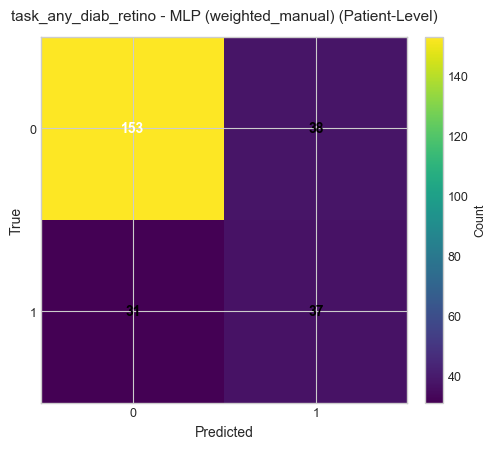

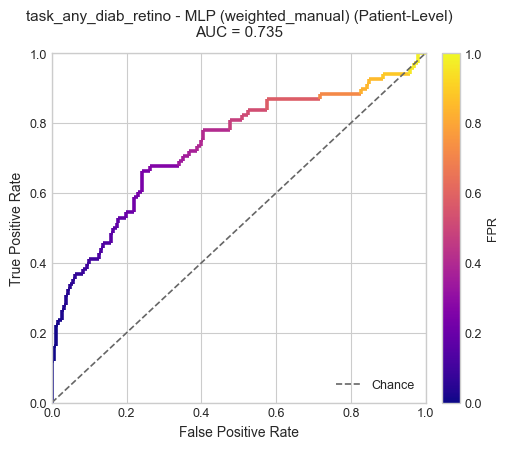


Embedding 2/7: Embeddings_mbrset_dinov3_convnext_base

--- Task: task_any_diab_retino ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 8.0}
  MLP: (256, 128), alpha=0.03, lr=0.0005, schedule=cosine
  Best epoch: 36 (cosine LR schedule)
  Threshold (sweep): 0.520

  Patient-Level: F1=0.481  Prec=0.351  Rec=0.765  BalAcc=0.631  AUC=0.690  (259 pts)
              precision    recall  f1-score   support

           0      0.856     0.497     0.629       191
           1      0.351     0.765     0.481        68

    accuracy                          0.568       259
   macro avg      0.604     0.631     0.555       259
weighted avg      0.723     0.568     0.590       259



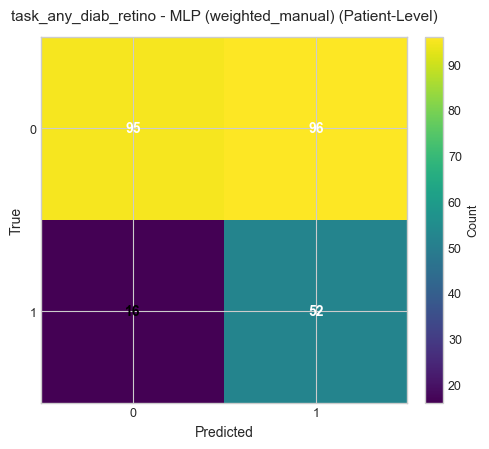

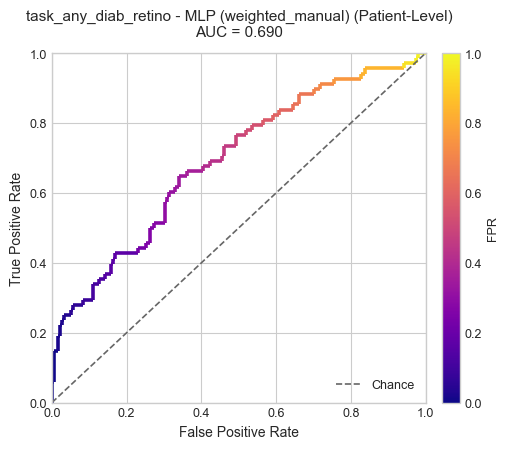


Embedding 3/7: Embeddings_mbrset_dinov3_vitb16

--- Task: task_any_diab_retino ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 5.0}
  MLP: (256, 128), alpha=0.06, lr=0.0005, schedule=cosine
  Best epoch: 41 (cosine LR schedule)
  Threshold (sweep): 0.569

  Patient-Level: F1=0.548  Prec=0.607  Rec=0.500  BalAcc=0.692  AUC=0.746  (259 pts)
              precision    recall  f1-score   support

           0      0.833     0.885     0.858       191
           1      0.607     0.500     0.548        68

    accuracy                          0.784       259
   macro avg      0.720     0.692     0.703       259
weighted avg      0.773     0.784     0.777       259



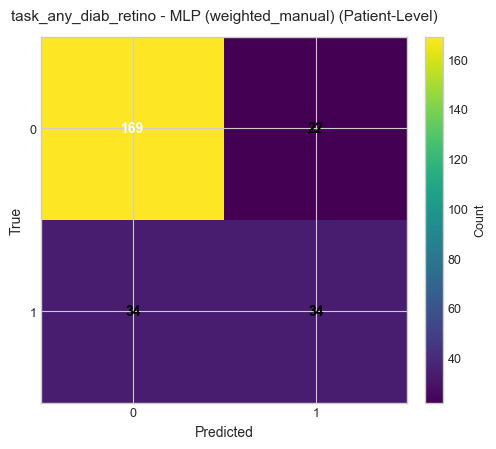

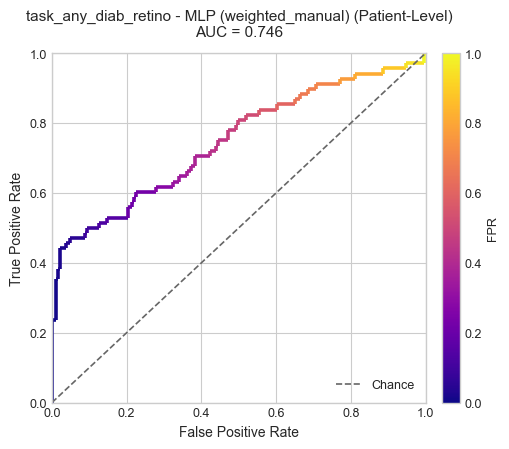


Embedding 4/7: Embeddings_mbrset_RETFound_dinov2_shanghai

--- Task: task_any_diab_retino ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 1.2}
  MLP: (256, 128), alpha=0.05, lr=0.0005, schedule=cosine
  Best epoch: 38 (cosine LR schedule)
  Threshold (sweep): 0.333

  Patient-Level: F1=0.574  Prec=0.607  Rec=0.544  BalAcc=0.709  AUC=0.791  (259 pts)
              precision    recall  f1-score   support

           0      0.843     0.874     0.859       191
           1      0.607     0.544     0.574        68

    accuracy                          0.788       259
   macro avg      0.725     0.709     0.716       259
weighted avg      0.781     0.788     0.784       259



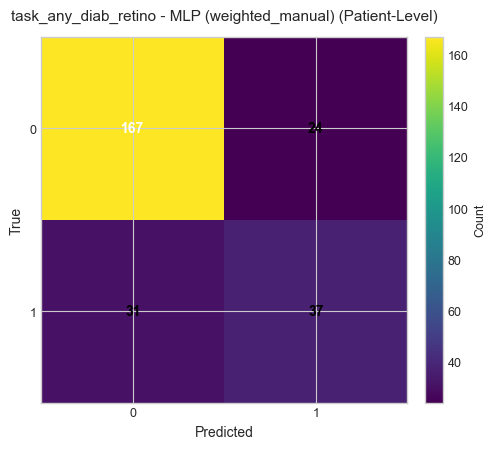

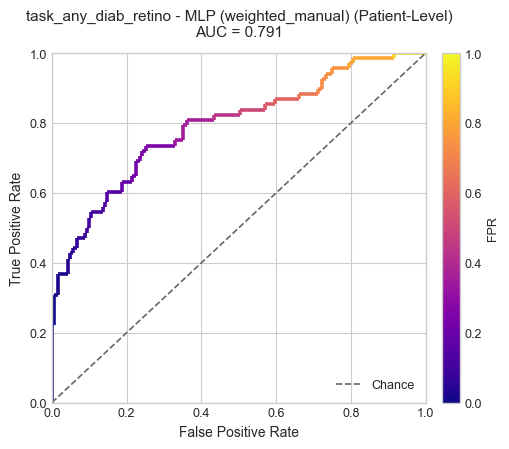


Embedding 5/7: Embeddings_mbrset_RETFound_mae_natureCFP

--- Task: task_any_diab_retino ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 1.0}
  MLP: (256, 128), alpha=0.03, lr=0.0005, schedule=cosine
  Best epoch: 39 (cosine LR schedule)
  Threshold (sweep): 0.319

  Patient-Level: F1=0.487  Prec=0.569  Rec=0.426  BalAcc=0.656  AUC=0.714  (259 pts)
              precision    recall  f1-score   support

           0      0.812     0.885     0.847       191
           1      0.569     0.426     0.487        68

    accuracy                          0.764       259
   macro avg      0.691     0.656     0.667       259
weighted avg      0.748     0.764     0.753       259



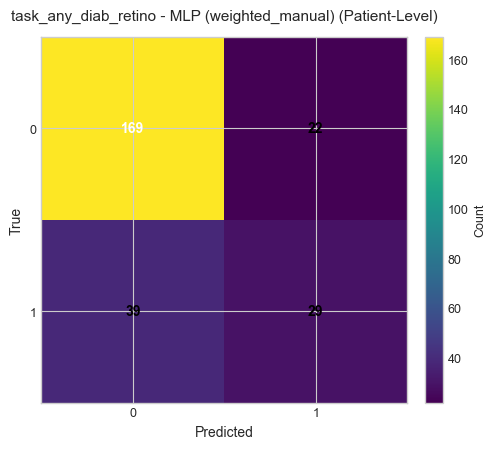

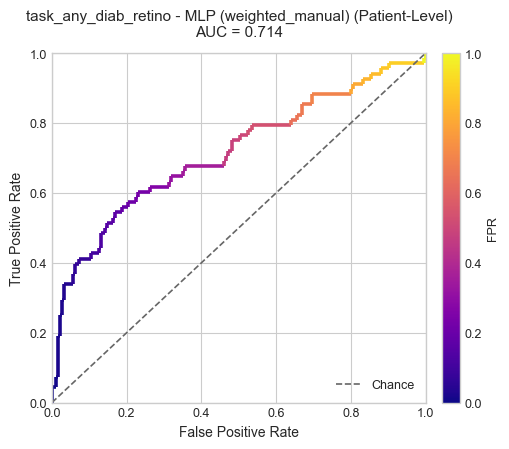


Embedding 6/7: Embeddings_mbrset_RETFound_mae_shanghai

--- Task: task_any_diab_retino ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 2.6}
  MLP: (256, 128), alpha=0.07, lr=0.0005, schedule=cosine
  Best epoch: 42 (cosine LR schedule)
  Threshold (sweep): 0.451

  Patient-Level: F1=0.471  Prec=0.471  Rec=0.471  BalAcc=0.641  AUC=0.691  (259 pts)
              precision    recall  f1-score   support

           0      0.812     0.812     0.812       191
           1      0.471     0.471     0.471        68

    accuracy                          0.722       259
   macro avg      0.641     0.641     0.641       259
weighted avg      0.722     0.722     0.722       259



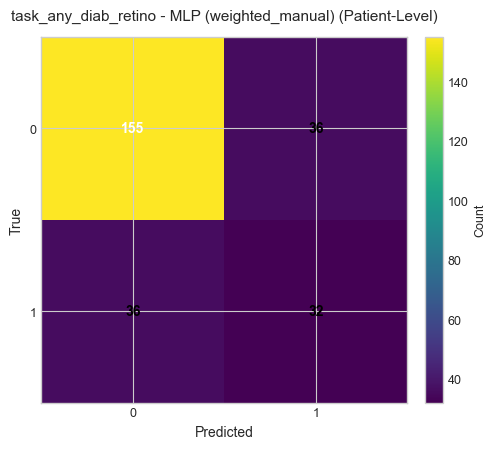

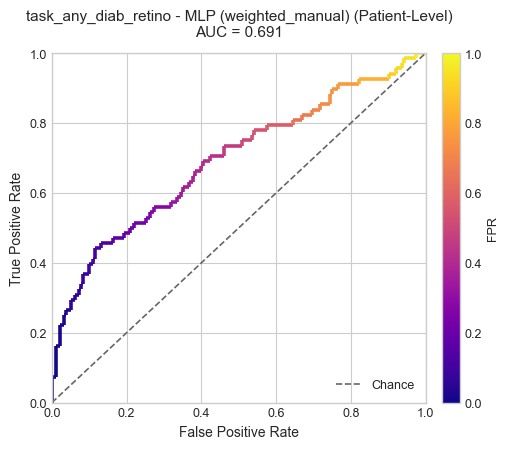


Embedding 7/7: Embeddings_vit_base_mbrset

--- Task: task_any_diab_retino ---
  Train: 2064 imgs, 1032 pts
  Test:  518 imgs, 259 pts
  Class dist (train): {np.int64(0): np.int64(1595), np.int64(1): np.int64(469)}
  Weights: SWEEP, mode=manual, map={0: 1.0, 1: 5.0}
  MLP: (256, 128), alpha=0.05, lr=0.0005, schedule=cosine
  Best epoch: 30 (cosine LR schedule)
  Threshold (sweep): 0.490

  Patient-Level: F1=0.455  Prec=0.370  Rec=0.588  BalAcc=0.616  AUC=0.669  (259 pts)
              precision    recall  f1-score   support

           0      0.815     0.644     0.719       191
           1      0.370     0.588     0.455        68

    accuracy                          0.629       259
   macro avg      0.592     0.616     0.587       259
weighted avg      0.698     0.629     0.650       259



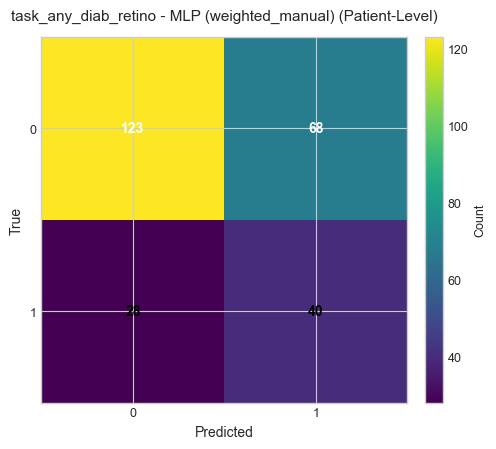

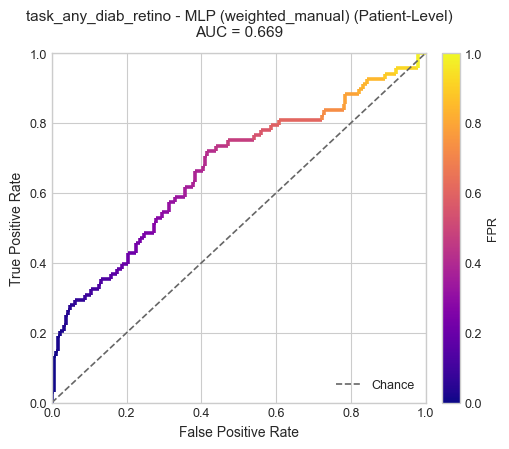


Training and evaluation complete!


In [7]:
# ——— Train on 80% train, evaluate on 20% test (patient-level) ———
all_results = []

# Merge sweep overrides (from Cell 11) with config overrides
_rt_w = globals().get('WEIGHTING_OVERRIDES', {})
_rt_t = globals().get('THRESHOLD_OVERRIDES', {})
_rt_w = _rt_w if isinstance(_rt_w, dict) else {}
_rt_t = _rt_t if isinstance(_rt_t, dict) else {}
WEIGHTING_OVERRIDES = copy.deepcopy(WEIGHTING_OVERRIDES_CONFIG)
THRESHOLD_OVERRIDES = copy.deepcopy(THRESHOLD_OVERRIDES_CONFIG)
for _e, _tc in _rt_w.items():
    WEIGHTING_OVERRIDES.setdefault(_e, {}).update(_tc if isinstance(_tc, dict) else {})
for _e, _tc in _rt_t.items():
    THRESHOLD_OVERRIDES.setdefault(_e, {}).update(_tc if isinstance(_tc, dict) else {})

print(f"Weight overrides: {len(WEIGHTING_OVERRIDES)} embeddings")
print(f"Threshold overrides: {len(THRESHOLD_OVERRIDES)} embeddings")
for en in WEIGHTING_OVERRIDES:
    for tk in WEIGHTING_OVERRIDES[en]:
        w = WEIGHTING_OVERRIDES[en][tk].get('manual', {}).get(1, '?')
        t = THRESHOLD_OVERRIDES.get(en, {}).get(tk, 'none')
        print(f"  {en} / {tk}: weight={w}, threshold={t}")

def get_effective_weight_cfg(emb_stem, task):
    base = (WEIGHTING_CONFIG or {}).get('binary', {})
    emb_over = (WEIGHTING_OVERRIDES or {}).get(emb_stem, {})
    task_over = emb_over.get(task, {}) if isinstance(emb_over, dict) else {}
    cfg = dict(base)
    if USE_EMBEDDING_TASK_WEIGHT_OVERRIDES and isinstance(task_over, dict) and task_over:
        cfg.update(task_over)
    cfg.setdefault('mode', 'manual')
    cfg.setdefault('manual', {0: 1.0, 1: 1.0})
    cfg.setdefault('damping_gamma', 1.0)
    return cfg

EVAL_TARGET_PATTERNS = ["RETFound", "dinov3", "vit_base", "convnextv2"]
eval_embedding_files = [
    emb for emb in embedding_files
    if any(p.lower() in emb.stem.lower() for p in EVAL_TARGET_PATTERNS)
]
print(f"\nEvaluating {len(eval_embedding_files)} embeddings:")
for emb in eval_embedding_files:
    print(f"  - {emb.stem}")

for emb_idx, emb_path in enumerate(eval_embedding_files):
    print(f"\n{'='*80}")
    print(f"Embedding {emb_idx+1}/{len(eval_embedding_files)}: {emb_path.stem}")
    print(f"{'='*80}")

    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
        view=VIEW,
    )

    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)
    train_df = all_df[all_df['patient_id'].isin(train_patient_ids)].copy()
    test_df = all_df[all_df['patient_id'].isin(test_patient_ids)].copy()

    for task in BINARY_TASKS:
        if task not in ds.df.columns:
            continue

        display_task = BINARY_TASK_MAP.get(task, task)
        print(f"\n--- Task: {display_task} ---")

        train_work = train_df.dropna(subset=[task]).copy()
        test_work = test_df.dropna(subset=[task]).copy()

        if train_work.empty or test_work.empty:
            print(f"  Skipping: insufficient data")
            continue

        X_train = train_work.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
        y_train = train_work[task].astype(int).to_numpy()
        X_test = test_work.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
        y_test = test_work[task].astype(int).to_numpy()

        classes, counts = np.unique(y_train, return_counts=True)
        print(f"  Train: {len(X_train)} imgs, {train_work['patient_id'].nunique()} pts")
        print(f"  Test:  {len(X_test)} imgs, {test_work['patient_id'].nunique()} pts")
        print(f"  Class dist (train): {dict(zip(classes.astype(int), counts))}")

        # PCA
        if USE_PCA:
            pca = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_SEED)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)

        # Scale
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Per-embedding weight from sweep (or fallback to balanced)
        weight_cfg = get_effective_weight_cfg(emb_path.stem, task)
        weight_mode = weight_cfg.get("mode", "balanced")
        has_override = task in (WEIGHTING_OVERRIDES.get(emb_path.stem, {}) or {})

        class_weight_mapping = compute_class_weight_mapping(
            y_train,
            mode=weight_mode,
            manual_class_weight=weight_cfg.get("manual"),
            damping_gamma=weight_cfg.get("damping_gamma", 1.0),
        )
        sample_weights = compute_sample_weights(y_train, class_weight_mapping, normalize=True)
        weight_name = f"weighted_{weight_mode}"
        print(f"  Weights: {'SWEEP' if has_override else 'base'}, mode={weight_mode}, map={class_weight_mapping}")

        # ——— Train MLP with cosine LR schedule ———
        mlp_cfg, _ = resolve_config(emb_path.stem)
        _lr_sched = mlp_cfg.get("lr_schedule", "constant")
        print(f"  MLP: {mlp_cfg['hidden_layer_sizes']}, alpha={mlp_cfg['alpha']}, "
              f"lr={mlp_cfg['learning_rate_init']}, schedule={_lr_sched}")

        # Internal 85/15 val split for early stopping
        from sklearn.model_selection import train_test_split as _eval_split
        _X_tr, _X_va, _y_tr, _y_va, _idx_tr, _idx_va = _eval_split(
            X_train_scaled, y_train, np.arange(len(y_train)),
            test_size=0.15, random_state=RANDOM_SEED, stratify=y_train,
        )
        _sw_tr = compute_sample_weights(_y_tr, class_weight_mapping, normalize=True)
        _sw_va = compute_sample_weights(_y_va, class_weight_mapping, normalize=True)

        best_model, _best_ep, _, _ = train_mlp_with_schedule(
            _X_tr, _y_tr, _X_va, _y_va, mlp_cfg,
            sample_weight_train=_sw_tr, sample_weight_val=_sw_va,
            random_seed=RANDOM_SEED,
        )
        print(f"  Best epoch: {_best_ep} ({_lr_sched} LR schedule)")

        # ——— THRESHOLD from sweep or compute on inner val ———
        thresh_override = (THRESHOLD_OVERRIDES.get(emb_path.stem, {}) or {}).get(task, None)

        if thresh_override is not None:
            opt_thresh = float(thresh_override)
            thresh_src = "sweep"
        else:
            # No sweep threshold — use our val split for threshold finding
            _val_proba = best_model.predict_proba(_X_va)[:, 1]
            _val_pids = train_work.iloc[_idx_va]["patient_id"].values
            _val_agg = pd.DataFrame({
                "patient_id": _val_pids, "y_true": _y_va, "y_proba": _val_proba
            }).groupby("patient_id").agg(y_true=("y_true", "max"), y_proba=("y_proba", "mean"))
            opt_thresh = find_optimal_threshold(
                _val_agg["y_true"].to_numpy(), _val_agg["y_proba"].to_numpy(),
                method=THRESHOLD_METHOD, grid_size=THRESHOLD_GRID_SIZE
            )
            thresh_src = f"{THRESHOLD_METHOD}_inner_val"

        print(f"  Threshold ({thresh_src}): {opt_thresh:.3f}")

        # ——— TEST: patient-level evaluation ———
        y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]

        test_agg = pd.DataFrame({
            "patient_id": test_work["patient_id"].values,
            "y_true": y_test,
            "y_proba": y_proba_test,
        }).groupby("patient_id").agg(
            y_true=("y_true", "max"),
            y_proba=("y_proba", "mean"),
        ).reset_index()
        test_agg["y_pred"] = (test_agg["y_proba"] >= opt_thresh).astype(int)

        y_true_pt = test_agg["y_true"].to_numpy()
        y_pred_pt = test_agg["y_pred"].to_numpy()
        y_proba_pt = test_agg["y_proba"].to_numpy()

        # Metrics
        accuracy = (y_true_pt == y_pred_pt).mean()
        f1 = f1_score(y_true_pt, y_pred_pt, zero_division=0)
        precision = precision_score(y_true_pt, y_pred_pt, zero_division=0)
        recall = recall_score(y_true_pt, y_pred_pt, zero_division=0)
        balanced_acc = balanced_accuracy_score(y_true_pt, y_pred_pt)
        fpr, tpr, _ = roc_curve(y_true_pt, y_proba_pt)
        auc = roc_auc_score(y_true_pt, y_proba_pt)

        print(f"\n  Patient-Level: F1={f1:.3f}  Prec={precision:.3f}  Rec={recall:.3f}  "
              f"BalAcc={balanced_acc:.3f}  AUC={auc:.3f}  ({len(test_agg)} pts)")

        report_text = classification_report(y_true_pt, y_pred_pt, digits=3)
        print(report_text)

        cm = confusion_matrix(y_true_pt, y_pred_pt)

        # Save outputs
        out_dir = RESULTS_DIR / f"{emb_idx:02d}_{emb_path.stem}" / display_task / "mlp"
        out_dir.mkdir(parents=True, exist_ok=True)

        (out_dir / "classification_report.txt").write_text(report_text, encoding="utf-8")
        pd.DataFrame(cm).to_csv(out_dir / "confusion_matrix.csv", index=False)
        plot_confusion_matrix(
            cm,
            title=f"{display_task} - MLP ({weight_name}) (Patient-Level)",
            save_path=out_dir / "confusion_matrix.png" if SAVE_PLOTS else None,
            show=SHOW_PLOTS,
        )

        pd.DataFrame({"fpr": fpr, "tpr": tpr}).to_csv(out_dir / "roc_curve.csv", index=False)
        plot_roc_curve(
            fpr, tpr, auc,
            title=f"{display_task} - MLP ({weight_name}) (Patient-Level)",
            save_path=out_dir / "roc_curve.png" if SAVE_PLOTS else None,
            show=SHOW_PLOTS,
        )

        test_agg.to_csv(out_dir / "patient_predictions.csv", index=False)

        all_results.append({
            "embedding_idx": emb_idx,
            "embedding": emb_path.stem,
            "task": display_task,
            "model": "mlp",
            "weighting": weight_name,
            "threshold": float(opt_thresh),
            "threshold_src": thresh_src,
            "n_patients": len(test_agg),
            "accuracy": float(accuracy),
            "balanced_accuracy": float(balanced_acc),
            "f1_score": float(f1),
            "precision": float(precision),
            "recall": float(recall),
            "auc": float(auc),
            "output_dir": str(out_dir),
        })

print(f"\n{'='*80}")
print("Training and evaluation complete!")
print(f"{'='*80}")

## 6. Summary Table

In [8]:
# Create summary DataFrame from individual embedding results
try:
    if not all_results:
        raise ValueError("all_results is empty. Run the Train/Evaluate cell first.")
    summary_df = pd.DataFrame(all_results)
except NameError:
    raise ValueError("all_results not found. Run the Train/Evaluate cell first.")

# Sort by task and F1 score
summary_df = summary_df.sort_values(["task", "f1_score"], ascending=[True, False]).reset_index(drop=True)

# Save summary
summary_path = RESULTS_DIR / "summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved summary to: {summary_path}")
print(f"Total results: {len(summary_df)} rows")
print(f"  - Embeddings: {summary_df['embedding'].nunique()}")
print(f"  - Tasks: {summary_df['task'].nunique()}")
print(f"  - Models: {summary_df['model'].nunique()}")

# Display comprehensive summary
print("\n" + "="*100)
print("INDIVIDUAL EMBEDDING RESULTS — R15c (Patient-Level, PCA=128)")
print("="*100)

display_cols = ["embedding", "task", "model", "weighting", "n_patients",
                "f1_score", "precision", "recall", "auc", "balanced_accuracy"]

print(summary_df[display_cols].to_string(index=False))

# Top performers
print("\n" + "="*100)
print("TOP PERFORMERS BY TASK")
print("="*100)
for task in summary_df['task'].unique():
    task_data = summary_df[summary_df['task'] == task].nlargest(5, 'f1_score')
    print(f"\n{task}:")
    print(task_data[["embedding", "model", "f1_score", "precision", "recall", "auc"]].to_string(index=False))

# Best overall
best = summary_df.iloc[0]
print(f"\nBEST INDIVIDUAL MODEL: {best['embedding']}  |  F1={best['f1_score']:.3f}  AUC={best['auc']:.3f}")

summary_df

Saved summary to: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_patient_eval_any_dr\summary.csv
Total results: 7 rows
  - Embeddings: 7
  - Tasks: 1
  - Models: 1

INDIVIDUAL EMBEDDING RESULTS — R15c (Patient-Level, PCA=128)
                                 embedding                 task model       weighting  n_patients  f1_score  precision   recall      auc  balanced_accuracy
Embeddings_mbrset_RETFound_dinov2_shanghai task_any_diab_retino   mlp weighted_manual         259  0.573643   0.606557 0.544118 0.791500           0.709232
           Embeddings_mbrset_dinov3_vitb16 task_any_diab_retino   mlp weighted_manual         259  0.548387   0.607143 0.500000 0.745996           0.692408
         Embeddings_convnextv2_base_mbrset task_any_diab_retino   mlp weighted_manual         259  0.517483   0.493333 0.544118 0.734678           0.672582
  Embeddings_mbrset_RETFound_mae_natureCFP task_any_diab_retino   mlp weighted_manual  

,embedding_idx,embedding,task,model,weighting,threshold,threshold_src,n_patients,accuracy,balanced_accuracy,f1_score,precision,recall,auc,output_dir
0,3,Embeddings_mbrset_RETFound_dinov2_shanghai,task_any_diab_retino,mlp,weighted_manual,0.3334,sweep,259,0.787645,0.709232,0.573643,0.606557,0.544118,0.791500,c:\Users\Julian\OneDrive\Desktop\testing-retin...
1,2,Embeddings_mbrset_dinov3_vitb16,task_any_diab_retino,mlp,weighted_manual,0.5686,sweep,259,0.783784,0.692408,0.548387,0.607143,0.500000,0.745996,c:\Users\Julian\OneDrive\Desktop\testing-retin...
2,0,Embeddings_convnextv2_base_mbrset,task_any_diab_retino,mlp,weighted_manual,0.3040,sweep,259,0.733591,0.672582,0.517483,0.493333,0.544118,0.734678,c:\Users\Julian\OneDrive\Desktop\testing-retin...
3,4,Embeddings_mbrset_RETFound_mae_natureCFP,task_any_diab_retino,mlp,weighted_manual,0.3187,sweep,259,0.764479,0.655644,0.487395,0.568627,0.426471,0.714352,c:\Users\Julian\OneDrive\Desktop\testing-retin...
4,1,Embeddings_mbrset_dinov3_convnext_base,task_any_diab_retino,mlp,weighted_manual,0.5196,sweep,259,0.567568,0.631044,0.481481,0.351351,0.764706,0.690253,c:\Users\Julian\OneDrive\Desktop\testing-retin...
5,5,Embeddings_mbrset_RETFound_mae_shanghai,task_any_diab_retino,mlp,weighted_manual,0.4510,sweep,259,0.722008,0.641053,0.470588,0.470588,0.470588,0.691484,c:\Users\Julian\OneDrive\Desktop\testing-retin...
6,6,Embeddings_vit_base_mbrset,task_any_diab_retino,mlp,weighted_manual,0.4902,sweep,259,0.629344,0.616107,0.454545,0.370370,0.588235,0.669233,c:\Users\Julian\OneDrive\Desktop\testing-retin...


## 7. Bagged Individual Models — Per-Embedding Best F1

For **each** of the 7 embeddings independently:
- **5-seed bagging** × **3 architectures** = 15 sub-models per embedding
- Average the 15 sub-model predictions → single probability per image
- Patient-level aggregation → optimal threshold search → **best F1 per embedding**
- Additionally trains **mixup-augmented** variants (α=0.4) and picks whichever is higher

BAGGED INDIVIDUAL MODELS — 5 seeds × 3 archs = 15 sub-models per embedding

--- Embeddings_convnextv2_base_mbrset ---
  Trained 15 no-mix + 15 mixup sub-models
  Best variant: NoMix
  F1=0.602  P=0.756  R=0.500  AUC=0.785  t=0.397
  Baseline F1=0.517  Δ=+0.084

--- Embeddings_mbrset_dinov3_convnext_base ---
  Trained 15 no-mix + 15 mixup sub-models
  Best variant: Combined
  F1=0.562  P=0.642  R=0.500  AUC=0.742  t=0.524
  Baseline F1=0.481  Δ=+0.081

--- Embeddings_mbrset_dinov3_vitb16 ---
  Trained 15 no-mix + 15 mixup sub-models
  Best variant: NoMix
  F1=0.624  P=0.829  R=0.500  AUC=0.785  t=0.603
  Baseline F1=0.548  Δ=+0.075

--- Embeddings_mbrset_RETFound_dinov2_shanghai ---
  Trained 15 no-mix + 15 mixup sub-models
  Best variant: Combined
  F1=0.640  P=0.702  R=0.588  AUC=0.812  t=0.245
  Baseline F1=0.574  Δ=+0.066

--- Embeddings_mbrset_RETFound_mae_natureCFP ---
  Trained 15 no-mix + 15 mixup sub-models
  Best variant: NoMix
  F1=0.602  P=0.756  R=0.500  AUC=0.725  t=0.338


,embedding,bag_variant,f1_score,precision,recall,auc,threshold,baseline_f1,delta_f1
3,Embeddings_mbrset_RETFound_dinov2_shanghai,Combined,0.640000,0.701754,0.588235,0.812365,0.2452,0.573643,0.066357
2,Embeddings_mbrset_dinov3_vitb16,NoMix,0.623853,0.829268,0.500000,0.785109,0.6029,0.548387,0.075466
0,Embeddings_convnextv2_base_mbrset,NoMix,0.601770,0.755556,0.500000,0.784724,0.3971,0.517483,0.084287
4,Embeddings_mbrset_RETFound_mae_natureCFP,NoMix,0.601770,0.755556,0.500000,0.724669,0.3383,0.487395,0.114375
6,Embeddings_vit_base_mbrset,Combined,0.563758,0.518519,0.617647,0.709886,0.3187,0.454545,0.109213
1,Embeddings_mbrset_dinov3_convnext_base,Combined,0.561983,0.641509,0.500000,0.741762,0.5245,0.481481,0.080502
5,Embeddings_mbrset_RETFound_mae_shanghai,Combined,0.543860,0.673913,0.455882,0.692331,0.4265,0.470588,0.073271


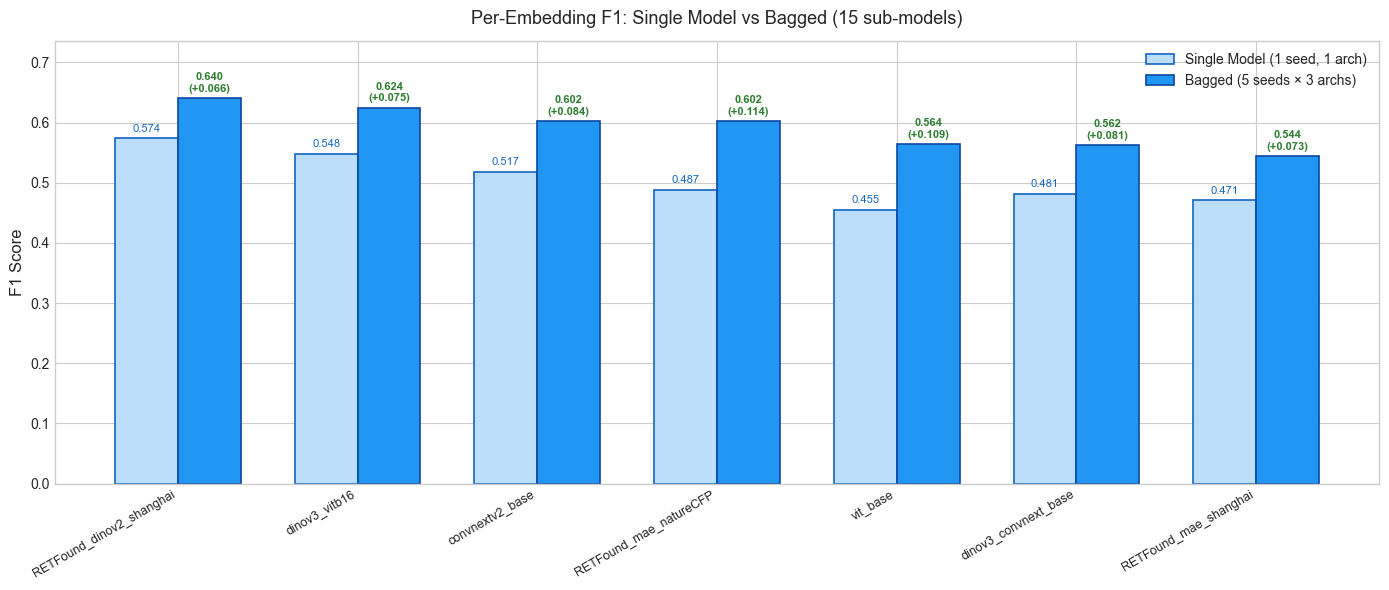


Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_patient_eval_any_dr\bagged_individual_results.csv


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# Bagged Individual Models: Per-Embedding Best F1
# ═══════════════════════════════════════════════════════════════════════════════
# For EACH embedding independently: 5 seeds × 3 architectures = 15 sub-models.
# Averages predictions across sub-models, then finds the best threshold for F1.
# No cross-embedding ensembling — each embedding stands on its own.

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression

# ——— Bagging Configuration ———
BAG_SEEDS = [42, 123, 314, 555, 789]
BAG_ARCHITECTURES = [(512, 256), (384, 192), (256, 128)]
MIXUP_ALPHA = 0.4
BAG_THRESHOLD_FLOOR = 0.20

# ——— Mixup augmentation ———
def mixup_data(X, y, alpha=0.4, seed=42):
    """Apply mixup augmentation to training data."""
    rng = np.random.RandomState(seed)
    n = len(X)
    lam = rng.beta(alpha, alpha, size=n)
    lam = np.maximum(lam, 1 - lam)  # ensure lam >= 0.5
    idx = rng.permutation(n)
    X_mix = (lam[:, None] * X + (1 - lam[:, None]) * X[idx])
    y_mix = (lam * y + (1 - lam) * y[idx])
    y_mix_hard = (y_mix >= 0.5).astype(int)
    return np.vstack([X, X_mix]), np.concatenate([y.astype(int), y_mix_hard])

if not all_results:
    raise ValueError("Run the individual training cell first!")

print(f"{'='*80}")
print(f"BAGGED INDIVIDUAL MODELS — {len(BAG_SEEDS)} seeds × {len(BAG_ARCHITECTURES)} archs "
      f"= {len(BAG_SEEDS)*len(BAG_ARCHITECTURES)} sub-models per embedding")
print(f"{'='*80}")

thresholds_grid = np.linspace(0.01, 0.99, THRESHOLD_GRID_SIZE)
thresholds_grid = thresholds_grid[thresholds_grid >= BAG_THRESHOLD_FLOOR]

bagged_results = []

for emb_path in eval_embedding_files:
    emb_stem = emb_path.stem
    print(f"\n--- {emb_stem} ---")
    
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=labels_path, view=VIEW,
    )
    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)
    train_df = all_df[all_df['patient_id'].isin(train_patient_ids)].copy()
    test_df = all_df[all_df['patient_id'].isin(test_patient_ids)].copy()
    
    task = BINARY_TASKS[0]
    train_work = train_df.dropna(subset=[task]).copy()
    test_work = test_df.dropna(subset=[task]).copy()
    
    X_train = train_work.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
    y_train = train_work[task].astype(int).to_numpy()
    X_test = test_work.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
    y_test = test_work[task].astype(int).to_numpy()
    
    # PCA + Scale
    pca = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_pca)
    X_test_s = scaler.transform(X_test_pca)
    
    # Get sweep weight for this embedding
    weight_cfg = get_effective_weight_cfg(emb_stem, task)
    cw_map = compute_class_weight_mapping(
        y_train, mode=weight_cfg.get("mode", "manual"),
        manual_class_weight=weight_cfg.get("manual"),
        damping_gamma=weight_cfg.get("damping_gamma", 1.0),
    )
    
    # Train 15 sub-models (no-mixup) + 15 sub-models (mixup)
    nomix_probas = []
    mix_probas = []
    
    for seed in BAG_SEEDS:
        for arch in BAG_ARCHITECTURES:
            mlp_cfg_bag, _ = resolve_config(emb_stem)
            sw_train = compute_sample_weights(y_train, cw_map, normalize=True)
            
            # No-mixup model
            mlp_nomix = MLPClassifier(
                hidden_layer_sizes=arch, alpha=mlp_cfg_bag["alpha"],
                learning_rate_init=mlp_cfg_bag["learning_rate_init"],
                batch_size=mlp_cfg_bag["batch_size"], max_iter=mlp_cfg_bag["max_epochs"],
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=mlp_cfg_bag["patience"], random_state=seed,
            )
            safe_fit_with_optional_sample_weight(mlp_nomix, X_train_s, y_train, sample_weight=sw_train)
            nomix_probas.append(mlp_nomix.predict_proba(X_test_s)[:, 1])
            
            # Mixup model
            X_mix, y_mix = mixup_data(X_train_s, y_train.astype(np.float64), alpha=MIXUP_ALPHA, seed=seed)
            sw_mix = np.ones(len(y_mix), dtype=np.float32)
            sw_mix[:len(y_train)] = sw_train
            sw_mix[len(y_train):] = np.mean(sw_train)
            
            mlp_mix = MLPClassifier(
                hidden_layer_sizes=arch, alpha=mlp_cfg_bag["alpha"],
                learning_rate_init=mlp_cfg_bag["learning_rate_init"],
                batch_size=mlp_cfg_bag["batch_size"], max_iter=mlp_cfg_bag["max_epochs"],
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=mlp_cfg_bag["patience"], random_state=seed,
            )
            safe_fit_with_optional_sample_weight(mlp_mix, X_mix, y_mix, sample_weight=sw_mix)
            mix_probas.append(mlp_mix.predict_proba(X_test_s)[:, 1])
    
    # Average across sub-models (image-level)
    nomix_avg = np.mean(nomix_probas, axis=0)
    mix_avg = np.mean(mix_probas, axis=0)
    combined_avg = np.mean(nomix_probas + mix_probas, axis=0)
    
    # Patient-level aggregation + threshold search for each variant
    variants = {"NoMix": nomix_avg, "Mixup": mix_avg, "Combined": combined_avg}
    best_variant_name, best_variant_f1 = None, -1.0
    best_variant_row = None
    
    for var_name, img_proba in variants.items():
        pt_agg = pd.DataFrame({
            "patient_id": test_work["patient_id"].values,
            "y_true": y_test, "y_proba": img_proba,
        }).groupby("patient_id").agg(y_true=("y_true", "max"), y_proba=("y_proba", "mean")).reset_index()
        
        y_true_pt = pt_agg["y_true"].to_numpy()
        y_proba_pt = pt_agg["y_proba"].to_numpy()
        
        # Find best threshold for F1
        best_t, best_f1 = 0.5, -1.0
        for t in thresholds_grid:
            yp = (y_proba_pt >= t).astype(int)
            f1v = float(f1_score(y_true_pt, yp, zero_division=0))
            if f1v > best_f1:
                best_f1 = f1v
                best_t = float(t)
        
        y_pred_pt = (y_proba_pt >= best_t).astype(int)
        f1_val = f1_score(y_true_pt, y_pred_pt, zero_division=0)
        prec_val = precision_score(y_true_pt, y_pred_pt, zero_division=0)
        rec_val = recall_score(y_true_pt, y_pred_pt, zero_division=0)
        auc_val = roc_auc_score(y_true_pt, y_proba_pt) if len(np.unique(y_true_pt)) == 2 else 0.5
        
        if f1_val > best_variant_f1:
            best_variant_f1 = f1_val
            best_variant_name = var_name
            best_variant_row = {
                "embedding": emb_stem,
                "bag_variant": var_name,
                "f1_score": float(f1_val),
                "precision": float(prec_val),
                "recall": float(rec_val),
                "auc": float(auc_val),
                "threshold": float(best_t),
                "n_patients": len(y_true_pt),
            }
    
    # Get the baseline single-model F1 for comparison
    baseline = [r for r in all_results if r["embedding"] == emb_stem]
    baseline_f1 = baseline[0]["f1_score"] if baseline else 0.0
    best_variant_row["baseline_f1"] = float(baseline_f1)
    best_variant_row["delta_f1"] = float(best_variant_f1 - baseline_f1)
    
    bagged_results.append(best_variant_row)
    
    print(f"  Trained {len(nomix_probas)} no-mix + {len(mix_probas)} mixup sub-models")
    print(f"  Best variant: {best_variant_name}")
    print(f"  F1={best_variant_f1:.3f}  P={best_variant_row['precision']:.3f}  "
          f"R={best_variant_row['recall']:.3f}  AUC={best_variant_row['auc']:.3f}  "
          f"t={best_variant_row['threshold']:.3f}")
    print(f"  Baseline F1={baseline_f1:.3f}  Δ={best_variant_row['delta_f1']:+.3f}")

# ——— Summary table ———
bag_df = pd.DataFrame(bagged_results).sort_values("f1_score", ascending=False)
bag_csv = RESULTS_DIR / "bagged_individual_results.csv"
bag_df.to_csv(bag_csv, index=False)

print(f"\n{'='*80}")
print("BAGGED INDIVIDUAL RESULTS — Best F1 per Embedding (sorted)")
print(f"{'='*80}")
display(bag_df[["embedding", "bag_variant", "f1_score", "precision", "recall",
                "auc", "threshold", "baseline_f1", "delta_f1"]])

# ——— Comparison: Baseline vs Bagged ———
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(bag_df))
width = 0.35

baseline_vals = bag_df["baseline_f1"].values
bagged_vals = bag_df["f1_score"].values
labels = [e.replace("Embeddings_", "").replace("mbrset_", "").replace("_mbrset", "")
          for e in bag_df["embedding"].values]

bars1 = ax.bar(x - width/2, baseline_vals, width, label="Single Model (1 seed, 1 arch)",
               color="#BBDEFB", edgecolor="#1565C0", linewidth=1.2)
bars2 = ax.bar(x + width/2, bagged_vals, width, label="Bagged (5 seeds × 3 archs)",
               color="#2196F3", edgecolor="#0D47A1", linewidth=1.2)

ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("Per-Embedding F1: Single Model vs Bagged (15 sub-models)", fontsize=13, pad=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
ax.legend(fontsize=10)
ax.set_ylim(0, max(bagged_vals.max(), baseline_vals.max()) * 1.15)

for bar, val in zip(bars1, baseline_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.008, f"{val:.3f}",
            ha="center", va="bottom", fontsize=8, color="#1565C0")
for bar, val, delta in zip(bars2, bagged_vals, bag_df["delta_f1"].values):
    color = "#2E7D32" if delta > 0 else "#C62828"
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.008,
            f"{val:.3f}\n({delta:+.3f})",
            ha="center", va="bottom", fontsize=8, fontweight="bold", color=color)

plt.tight_layout()
bag_plot_dir = RESULTS_DIR / "bagged_plots"
bag_plot_dir.mkdir(parents=True, exist_ok=True)
if SAVE_PLOTS:
    fig.savefig(bag_plot_dir / "baseline_vs_bagged_f1.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"\nSaved: {bag_csv}")

## Phase 3 — Patient-Level Embedding Pooling + PCA (fixed sweep weights)

Phases 1–2 classified **images** then aggregated via majority vote. This introduces noise — one bad image prediction can flip a patient's label.

**Phase 3 strategy: pool first, reduce, classify once.**
1. For each patient, compute **mean** and **std** of all their image embeddings → concatenate to `2×D` features
2. **PCA=128** on pooled features → reduces 1536–2048 dims to 128, restoring a healthy ~8:1 sample:feature ratio
3. Assign patient-level label (mode of image-level labels)
4. **Fix `pos_class_weight`** to the best weight found in the weight sweep for each embedding (no weight search)
5. BayesSearchCV on architecture, alpha, lr, batch_size (scoring=F1)
6. F1-optimal threshold on internal validation split
7. Evaluate directly — no aggregation step needed

**Key differences from Phase 3 v1 (no PCA):**
- **PCA=128 after pooling** — fixes the curse of dimensionality (was ~0.5:1 ratio, now ~8:1)
- **Best sweep weights** — each embedding uses its proven best `pos_class_weight` from the targeted sweep
- **Narrower search space** — removes weight from BayesSearchCV, letting it focus on architecture/regularization

Phase 3 config (Option B — PCA + BayesSearchCV weight search):
  Pooling: mean + std concatenation → 2×D features
  PCA: 128 components (on pooled features)
  Architectures: 14 options
  Bayesian iterations: 30, CV folds: 3
  pos_class_weight: SEARCHED [1.0, 10.0] via BayesSearchCV
  Max epochs: 300, Patience: 25
  Batch sizes: [32, 64, 128, 256]
  Threshold: F1-optimal (grid=201)


PHASE 3 — Embedding 1/7: convnextv2_base
  pos_class_weight: SEARCHED via BayesSearchCV [1.0, 10.0]
  Original embedding dim: 1024
  Pooled feature dim (raw): 2048 (mean + std)
  PCA: 2048 → 128 (88.6% variance retained)
  Sample:feature ratio: 7.9:1
  Train patients: 1017 | Test patients: 257
  Class distribution (train): {np.int64(0): np.int64(721), np.int64(1): np.int64(296)} (29.1% positive)

  Running Phase 3 Bayesian search (30 iters, scoring=f1, weight=searched)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for

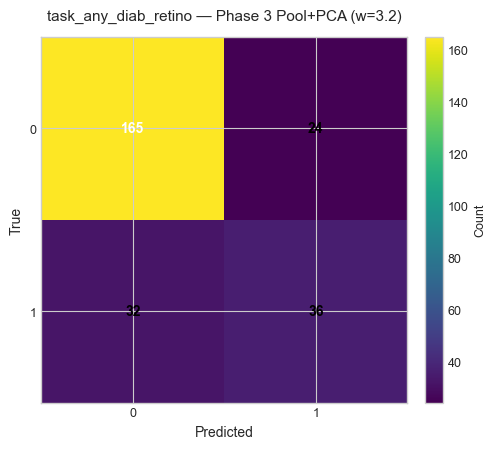

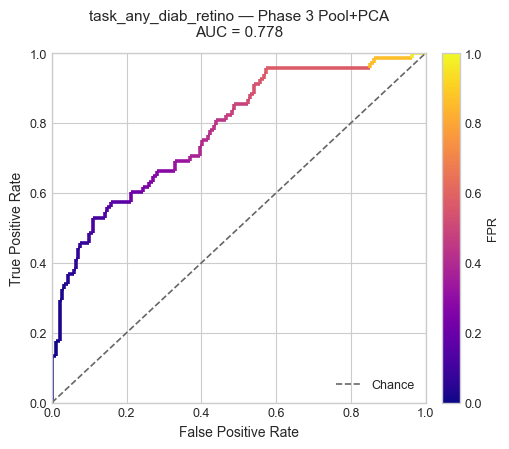


PHASE 3 — Embedding 2/7: dinov3_convnext_base
  pos_class_weight: SEARCHED via BayesSearchCV [1.0, 10.0]
  Original embedding dim: 1024
  Pooled feature dim (raw): 2048 (mean + std)
  PCA: 2048 → 128 (93.9% variance retained)
  Sample:feature ratio: 7.9:1
  Train patients: 1017 | Test patients: 257
  Class distribution (train): {np.int64(0): np.int64(721), np.int64(1): np.int64(296)} (29.1% positive)

  Running Phase 3 Bayesian search (30 iters, scoring=f1, weight=searched)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, tot

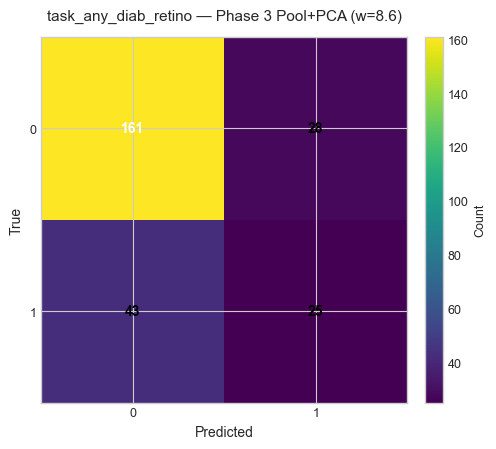

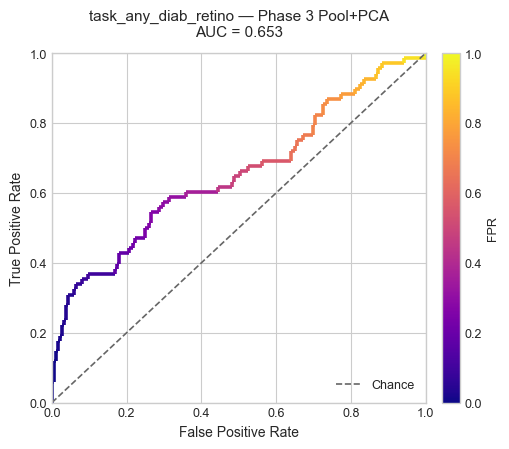


PHASE 3 — Embedding 3/7: dinov3_vitb16
  pos_class_weight: SEARCHED via BayesSearchCV [1.0, 10.0]
  Original embedding dim: 768
  Pooled feature dim (raw): 1536 (mean + std)
  PCA: 1536 → 128 (86.7% variance retained)
  Sample:feature ratio: 7.9:1
  Train patients: 1017 | Test patients: 257
  Class distribution (train): {np.int64(0): np.int64(721), np.int64(1): np.int64(296)} (29.1% positive)

  Running Phase 3 Bayesian search (30 iters, scoring=f1, weight=searched)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3

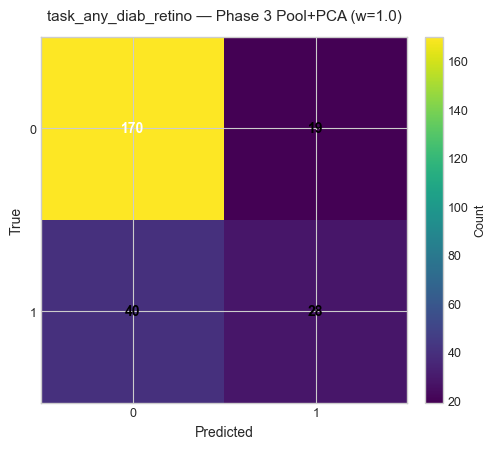

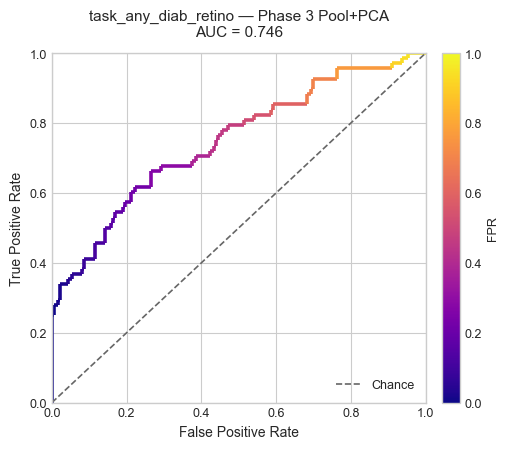


PHASE 3 — Embedding 4/7: RETFound_dinov2_shanghai
  pos_class_weight: SEARCHED via BayesSearchCV [1.0, 10.0]
  Original embedding dim: 1024
  Pooled feature dim (raw): 2048 (mean + std)
  PCA: 2048 → 128 (86.2% variance retained)
  Sample:feature ratio: 7.9:1
  Train patients: 1017 | Test patients: 257
  Class distribution (train): {np.int64(0): np.int64(721), np.int64(1): np.int64(296)} (29.1% positive)

  Running Phase 3 Bayesian search (30 iters, scoring=f1, weight=searched)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates,

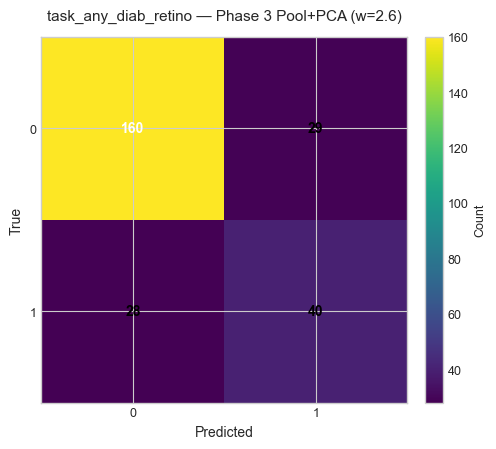

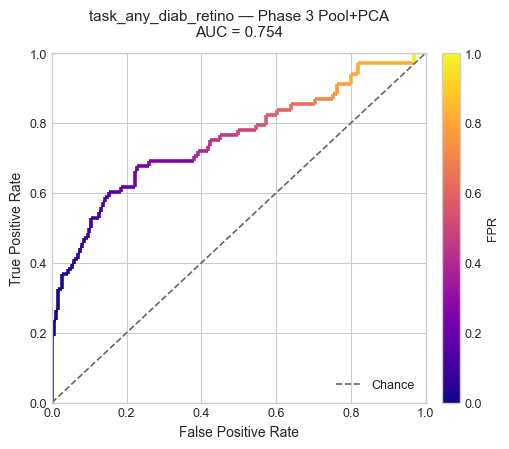


PHASE 3 — Embedding 5/7: RETFound_mae_natureCFP
  pos_class_weight: SEARCHED via BayesSearchCV [1.0, 10.0]
  Original embedding dim: 1024
  Pooled feature dim (raw): 2048 (mean + std)
  PCA: 2048 → 128 (92.5% variance retained)
  Sample:feature ratio: 7.9:1
  Train patients: 1017 | Test patients: 257
  Class distribution (train): {np.int64(0): np.int64(721), np.int64(1): np.int64(296)} (29.1% positive)

  Running Phase 3 Bayesian search (30 iters, scoring=f1, weight=searched)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, t

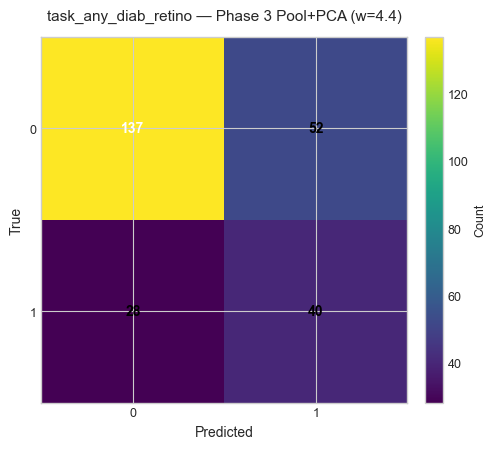

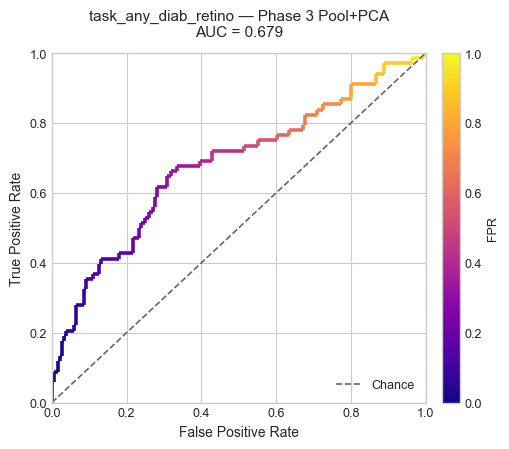


PHASE 3 — Embedding 6/7: RETFound_mae_shanghai
  pos_class_weight: SEARCHED via BayesSearchCV [1.0, 10.0]
  Original embedding dim: 1024
  Pooled feature dim (raw): 2048 (mean + std)
  PCA: 2048 → 128 (91.4% variance retained)
  Sample:feature ratio: 7.9:1
  Train patients: 1017 | Test patients: 257
  Class distribution (train): {np.int64(0): np.int64(721), np.int64(1): np.int64(296)} (29.1% positive)

  Running Phase 3 Bayesian search (30 iters, scoring=f1, weight=searched)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, to

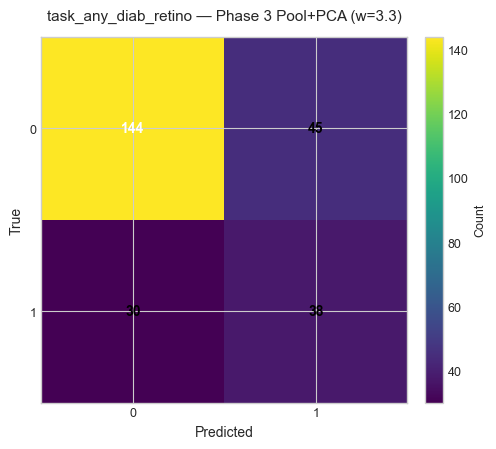

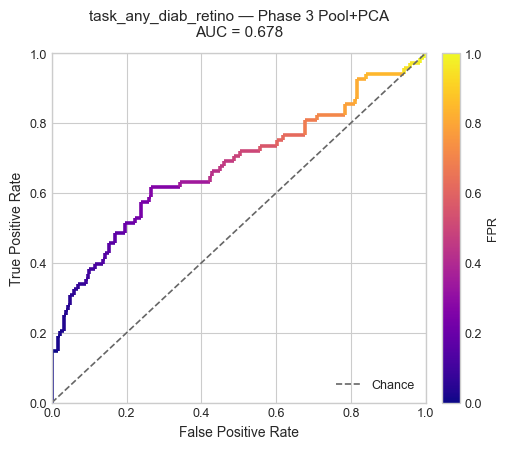


PHASE 3 — Embedding 7/7: vit_base
  pos_class_weight: SEARCHED via BayesSearchCV [1.0, 10.0]
  Original embedding dim: 768
  Pooled feature dim (raw): 1536 (mean + std)
  PCA: 1536 → 128 (89.7% variance retained)
  Sample:feature ratio: 7.9:1
  Train patients: 1017 | Test patients: 257
  Class distribution (train): {np.int64(0): np.int64(721), np.int64(1): np.int64(296)} (29.1% positive)

  Running Phase 3 Bayesian search (30 iters, scoring=f1, weight=searched)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits

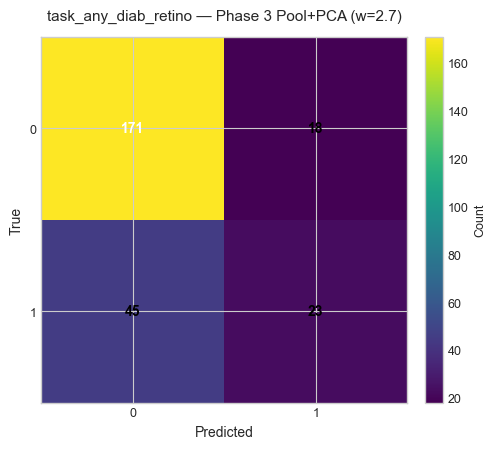

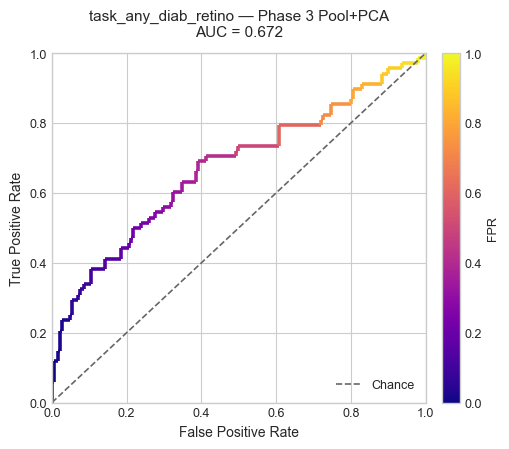


Phase 3 complete!


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 3 — Patient-Level Embedding Pooling + PCA (fixed sweep weights)
# Pool embeddings per patient (mean + std → 2×D), PCA→128, classify patients
# ═══════════════════════════════════════════════════════════════════════════════

PHASE3_DIR = RESULTS_DIR / "phase3_patient_pooling"
PHASE3_DIR.mkdir(parents=True, exist_ok=True)

# Phase 3 search config
PHASE3_N_ITER = 30
PHASE3_MAX_EPOCHS = 300
PHASE3_PATIENCE = 25
PHASE3_CV_FOLDS = 3
PHASE3_PCA_N = 128        # PCA on pooled features → fix curse of dimensionality

# ─── Best pos_class_weight per embedding from targeted weight sweep ───
PHASE3_WEIGHT_MAP = {
    "convnextv2_base":          1.2,
    "dinov3_convnext_base":     8.0,
    "dinov3_vitb16":            5.0,
    "RETFound_dinov2_shanghai": 1.2,
    "RETFound_mae_natureCFP":   1.0,
    "RETFound_mae_shanghai":    2.6,
    "vit_base":                 5.0,
}

# Architecture options for Phase 3 (PCA=128 input → moderate capacity needed)
PHASE3_ARCHITECTURES = [
    (64,),
    (128,),
    (256,),
    (512,),
    (64, 64),
    (128, 64),
    (128, 128),
    (256, 128),
    (256, 256),
    (512, 256),
    (128, 128, 64),
    (256, 128, 64),
    (256, 256, 128),
    (512, 256, 128),
]

# Search space — includes pos_class_weight for joint optimization
PHASE3_SEARCH_SPACE = {
    'hidden_layer_sizes': Integer(0, len(PHASE3_ARCHITECTURES) - 1, name='hidden_layer_sizes'),
    'alpha': Real(1e-5, 1e-1, prior='log-uniform', name='alpha'),
    'learning_rate_init': Real(5e-5, 2e-3, prior='log-uniform', name='learning_rate_init'),
    'batch_size': Categorical([32, 64, 128, 256], name='batch_size'),
    'pos_class_weight': Real(1.0, 10.0, prior='uniform', name='pos_class_weight'),
}


# ─── Phase 3 MLP Wrapper (fixed pos_class_weight) ───
class MLPPooledWrapper(BaseEstimator, ClassifierMixin):
    """
    MLP wrapper for Phase 3 patient-level pooling.
    Converts architecture indices and applies a FIXED pos_class_weight as sample weights.
    """
    def __init__(self, hidden_layer_sizes=0, alpha=0.01, learning_rate_init=0.001,
                 batch_size=64, pos_class_weight=1.0,
                 max_iter=300, early_stopping=True, validation_fraction=0.15,
                 n_iter_no_change=10, random_state=42, warm_start=False):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.pos_class_weight = pos_class_weight
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change
        self.random_state = random_state
        self.warm_start = warm_start
        self._mlp = None

    def _get_architecture(self):
        if isinstance(self.hidden_layer_sizes, int):
            return PHASE3_ARCHITECTURES[self.hidden_layer_sizes]
        return self.hidden_layer_sizes

    def fit(self, X, y, sample_weight=None):
        arch = self._get_architecture()
        self._mlp = MLPClassifier(
            hidden_layer_sizes=arch, alpha=self.alpha,
            learning_rate_init=self.learning_rate_init, batch_size=self.batch_size,
            max_iter=self.max_iter, early_stopping=self.early_stopping,
            validation_fraction=self.validation_fraction,
            n_iter_no_change=self.n_iter_no_change,
            random_state=self.random_state, warm_start=self.warm_start,
        )
        # Apply fixed pos_class_weight as sample weights
        y_arr = np.asarray(y)
        w = np.where(y_arr == 1, float(self.pos_class_weight), 1.0).astype(np.float32)
        mean_w = w.mean()
        if mean_w > 0:
            w /= mean_w
        self._mlp.fit(X, y, sample_weight=w)
        self.classes_ = self._mlp.classes_
        self.n_iter_ = self._mlp.n_iter_
        self.loss_ = self._mlp.loss_
        self.best_loss_ = self._mlp.best_loss_ if hasattr(self._mlp, 'best_loss_') else None
        return self

    def predict(self, X):
        return self._mlp.predict(X)

    def predict_proba(self, X):
        return self._mlp.predict_proba(X)

    def score(self, X, y, sample_weight=None):
        return self._mlp.score(X, y, sample_weight=sample_weight)


def build_patient_pooled_features(df, feature_cols, group_col="patient_id", label_col="task_any_dr"):
    """
    Pool image-level embeddings to patient-level using mean + std concatenation.
    Returns: patient_ids, X_pooled (n_patients × 2D), y_labels
    """
    patient_ids = []
    X_pooled_list = []
    y_labels = []

    for pid, group in df.groupby(group_col):
        features = group[feature_cols].to_numpy(dtype=np.float32)
        feat_mean = features.mean(axis=0)
        feat_std = features.std(axis=0) if len(features) > 1 else np.zeros_like(feat_mean)
        pooled = np.concatenate([feat_mean, feat_std])
        label = int(group[label_col].max())  # positive if ANY image is positive
        patient_ids.append(pid)
        X_pooled_list.append(pooled)
        y_labels.append(label)

    return (
        np.array(patient_ids),
        np.array(X_pooled_list, dtype=np.float32),
        np.array(y_labels, dtype=int),
    )


print(f"Phase 3 config (Option B — PCA + BayesSearchCV weight search):")
print(f"  Pooling: mean + std concatenation → 2×D features")
print(f"  PCA: {PHASE3_PCA_N} components (on pooled features)")
print(f"  Architectures: {len(PHASE3_ARCHITECTURES)} options")
print(f"  Bayesian iterations: {PHASE3_N_ITER}, CV folds: {PHASE3_CV_FOLDS}")
print(f"  pos_class_weight: SEARCHED [1.0, 10.0] via BayesSearchCV")
print(f"  Max epochs: {PHASE3_MAX_EPOCHS}, Patience: {PHASE3_PATIENCE}")
print(f"  Batch sizes: [32, 64, 128, 256]")
print(f"  Threshold: F1-optimal (grid=201)")
print()

# ─── Run Phase 3 for all embeddings ───
phase3_results = []

for emb_idx, emb_path in enumerate(embedding_files):
    emb_name = emb_path.stem
    short_name = emb_name.replace("Embeddings_", "").replace("mbrset_", "").replace("_mbrset", "")

    print(f"\n{'='*80}")
    print(f"PHASE 3 — Embedding {emb_idx+1}/{len(embedding_files)}: {short_name}")
    print(f"{'='*80}")

    # Load dataset
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
        view=VIEW,
    )

    task = "task_any_dr"
    display_task = "task_any_diab_retino"

    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)

    train_df = all_df[all_df['patient_id'].isin(train_patient_ids)].dropna(subset=[task]).copy()
    test_df = all_df[all_df['patient_id'].isin(test_patient_ids)].dropna(subset=[task]).copy()

    if train_df.empty or test_df.empty:
        print(f"  Skipping: insufficient data")
        continue

    print(f"  pos_class_weight: SEARCHED via BayesSearchCV [1.0, 10.0]")

    # ─── Build patient-level pooled features ───
    train_pids, X_train_pooled, y_train = build_patient_pooled_features(
        train_df, ds.feature_cols, group_col="patient_id", label_col=task
    )
    test_pids, X_test_pooled, y_test = build_patient_pooled_features(
        test_df, ds.feature_cols, group_col="patient_id", label_col=task
    )

    n_features_orig = len(ds.feature_cols)
    n_features_pooled_raw = X_train_pooled.shape[1]

    classes, counts = np.unique(y_train, return_counts=True)
    pos_rate = counts[1] / counts.sum() if len(counts) > 1 else 0

    print(f"  Original embedding dim: {n_features_orig}")
    print(f"  Pooled feature dim (raw): {n_features_pooled_raw} (mean + std)")
    # ─── PCA on pooled features ───
    pca = PCA(n_components=PHASE3_PCA_N, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train_pooled)
    X_test_pca = pca.transform(X_test_pooled)
    variance_explained = pca.explained_variance_ratio_.sum()
    n_features_final = X_train_pca.shape[1]

    print(f"  PCA: {n_features_pooled_raw} → {n_features_final} ({variance_explained:.1%} variance retained)")
    print(f"  Sample:feature ratio: {len(y_train)/n_features_final:.1f}:1")
    print(f"  Train patients: {len(y_train)} | Test patients: {len(y_test)}")
    print(f"  Class distribution (train): {dict(zip(classes.astype(int), counts))} ({pos_rate:.1%} positive)")

    # Scale features (after PCA)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_pca)
    X_test_scaled = scaler.transform(X_test_pca)

    # Internal val split for threshold optimization
    from sklearn.model_selection import train_test_split
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_scaled, y_train, test_size=0.15, random_state=RANDOM_SEED, stratify=y_train
    )

    # ─── Bayesian search on patient-level features (weight searched) ───
    base_mlp = MLPPooledWrapper(
        pos_class_weight=1.0,   # default; BayesSearchCV will override
        max_iter=PHASE3_MAX_EPOCHS,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=PHASE3_PATIENCE,
        random_state=RANDOM_SEED,
        warm_start=False,
    )

    bayes_search = BayesSearchCV(
        estimator=base_mlp,
        search_spaces=PHASE3_SEARCH_SPACE,
        n_iter=PHASE3_N_ITER,
        cv=PHASE3_CV_FOLDS,
        n_jobs=min(3, CPU_COUNT),
        scoring='f1',
        random_state=RANDOM_SEED,
        verbose=1,
    )

    print(f"\n  Running Phase 3 Bayesian search ({PHASE3_N_ITER} iters, scoring=f1, weight=searched)...")
    bayes_search.fit(X_train_scaled, y_train)

    best_model = bayes_search.best_estimator_
    best_params = bayes_search.best_params_
    best_cv_f1 = bayes_search.best_score_

    arch_idx = best_params.get('hidden_layer_sizes', 0)
    arch_display = PHASE3_ARCHITECTURES[arch_idx] if isinstance(arch_idx, int) else arch_idx

    best_weight = best_params.get('pos_class_weight', 1.0)
    print(f"  Best CV F1: {best_cv_f1:.4f}")
    print(f"  Best architecture: {arch_display}")
    print(f"  Best pos_class_weight: {best_weight:.2f} (searched)")
    print(f"  Best alpha: {best_params.get('alpha', '?')}")
    print(f"  Best lr: {best_params.get('learning_rate_init', '?')}")
    print(f"  Best batch_size: {best_params.get('batch_size', '?')}")

    # ─── F1-optimal threshold on internal validation set ───
    val_proba = best_model.predict_proba(X_val)[:, 1]
    opt_thresh = find_optimal_threshold(y_val, val_proba, method="f1", grid_size=201)
    print(f"  Optimal F1 threshold: {opt_thresh:.3f}")

    # ─── Evaluate on test patients ───
    y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
    y_pred_test = (y_proba_test >= opt_thresh).astype(int)

    acc = (y_test == y_pred_test).mean()
    f1 = f1_score(y_test, y_pred_test, zero_division=0)
    prec = precision_score(y_test, y_pred_test, zero_division=0)
    rec = recall_score(y_test, y_pred_test, zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, y_pred_test)
    fpr, tpr, _ = roc_curve(y_test, y_proba_test)
    auc = roc_auc_score(y_test, y_proba_test)

    print(f"\n  Patient-Level Metrics (DIRECT — no aggregation):")
    print(f"  Accuracy:          {acc:.3f}")
    print(f"  Balanced Accuracy: {bal_acc:.3f}")
    print(f"  F1 Score:          {f1:.3f}")
    print(f"  Precision:         {prec:.3f}")
    print(f"  Recall:            {rec:.3f}")
    print(f"  ROC AUC:           {auc:.3f}")

    report_text = classification_report(y_test, y_pred_test, digits=3)
    print(f"\n{report_text}")

    cm = confusion_matrix(y_test, y_pred_test)

    # ─── Save results ───
    out_dir = PHASE3_DIR / f"{emb_idx:02d}_{short_name}"
    out_dir.mkdir(parents=True, exist_ok=True)

    (out_dir / "classification_report.txt").write_text(report_text, encoding="utf-8")

    import json as _json
    hp_save = {k: str(v) for k, v in best_params.items()}
    hp_save["architecture_resolved"] = str(arch_display)
    hp_save["optimal_threshold"] = str(opt_thresh)
    hp_save["pooling_method"] = "mean+std"
    hp_save["pooled_dim_raw"] = str(n_features_pooled_raw)
    hp_save["pca_components"] = str(PHASE3_PCA_N)
    hp_save["pca_variance_retained"] = f"{variance_explained:.4f}"
    hp_save["final_feature_dim"] = str(n_features_final)
    hp_save["pos_class_weight"] = str(best_weight)
    hp_save["weight_source"] = "bayesian_search"
    with open(out_dir / "phase3_hyperparameters.json", "w") as f:
        _json.dump(hp_save, f, indent=2)

    pd.DataFrame(cm).to_csv(out_dir / "confusion_matrix.csv", index=False)
    plot_confusion_matrix(
        cm,
        title=f"{display_task} — Phase 3 Pool+PCA (w={best_weight:.1f})",
        save_path=out_dir / "confusion_matrix.png",
        show=SHOW_PLOTS,
    )

    pd.DataFrame({"fpr": fpr, "tpr": tpr}).to_csv(out_dir / "roc_curve.csv", index=False)
    plot_roc_curve(
        fpr, tpr, auc,
        title=f"{display_task} — Phase 3 Pool+PCA",
        save_path=out_dir / "roc_curve.png",
        show=SHOW_PLOTS,
    )

    pred_df = pd.DataFrame({
        "patient_id": test_pids,
        "y_true": y_test,
        "y_pred": y_pred_test,
        "y_proba": y_proba_test,
    })
    pred_df.to_csv(out_dir / "patient_predictions.csv", index=False)

    phase3_results.append({
        "embedding": short_name,
        "pooling": "mean+std",
        "pooled_dim_raw": n_features_pooled_raw,
        "pca_components": PHASE3_PCA_N,
        "pca_variance": round(variance_explained, 4),
        "final_dim": n_features_final,
        "architecture": str(arch_display),
        "pos_class_weight": float(best_weight),
        "weight_source": "bayesian_search",
        "threshold": float(opt_thresh),
        "n_train_patients": len(y_train),
        "n_test_patients": len(y_test),
        "best_cv_f1": float(best_cv_f1),
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
        "f1_score": float(f1),
        "precision": float(prec),
        "recall": float(rec),
        "auc": float(auc),
    })

print("\n" + "="*80)
print("Phase 3 complete!")
print("="*80)

## Phase 3 — Results Summary and Comparison

Phase 3 Results — Patient-Level Pooling + PCA (fixed sweep weights):
               embedding  pooled_dim_raw  pca_components  pca_variance  final_dim    architecture  pos_class_weight  threshold  f1_score   recall  precision  balanced_accuracy      auc
         convnextv2_base            2048             128        0.8770        128 (512, 256, 128)          3.769028     0.5343  0.584615 0.558824   0.612903           0.716585 0.761164
    dinov3_convnext_base            2048             128        0.9354        128          (128,)          4.448395     0.5343  0.479638 0.779412   0.346405           0.627926 0.669541
           dinov3_vitb16            1536             128        0.8568        128      (256, 256)          4.903888     0.7205  0.507937 0.470588   0.551724           0.667231 0.725978
RETFound_dinov2_shanghai            2048             128        0.8515        128        (64, 64)          3.753558     0.6225  0.483333 0.426471   0.557692           0.653026 0.720742
  RETF

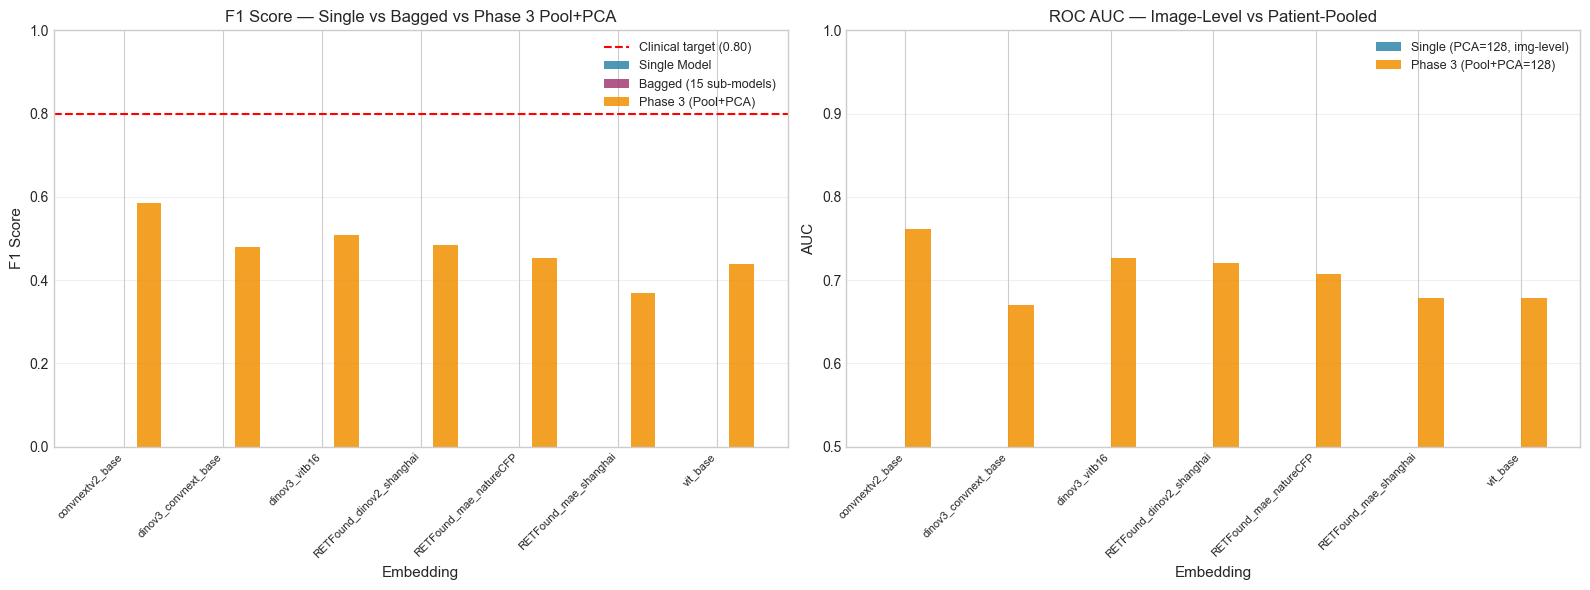


All Phase 3 results saved to: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_patient_eval_any_dr\phase3_patient_pooling


,embedding,pooling,pooled_dim_raw,pca_components,pca_variance,final_dim,architecture,pos_class_weight,weight_source,threshold,n_train_patients,n_test_patients,best_cv_f1,accuracy,balanced_accuracy,f1_score,precision,recall,auc
0,convnextv2_base,mean+std,2048,128,0.8770,128,"(512, 256, 128)",3.769028,bayesian_search,0.5343,1032,259,0.526457,0.791506,0.716585,0.584615,0.612903,0.558824,0.761164
1,dinov3_convnext_base,mean+std,2048,128,0.9354,128,"(128,)",4.448395,bayesian_search,0.5343,1032,259,0.512131,0.555985,0.627926,0.479638,0.346405,0.779412,0.669541
2,dinov3_vitb16,mean+std,1536,128,0.8568,128,"(256, 256)",4.903888,bayesian_search,0.7205,1032,259,0.554289,0.760618,0.667231,0.507937,0.551724,0.470588,0.725978
3,RETFound_dinov2_shanghai,mean+std,2048,128,0.8515,128,"(64, 64)",3.753558,bayesian_search,0.6225,1032,259,0.521167,0.760618,0.653026,0.483333,0.557692,0.426471,0.720742
4,RETFound_mae_natureCFP,mean+std,2048,128,0.9195,128,"(512, 256, 128)",5.242995,bayesian_search,0.6764,1032,259,0.490907,0.729730,0.632083,0.453125,0.483333,0.426471,0.706960
5,RETFound_mae_shanghai,mean+std,2048,128,0.9083,128,"(512, 256, 128)",3.188686,bayesian_search,0.9508,1032,259,0.523999,0.749035,0.597821,0.368932,0.542857,0.279412,0.678857
6,vit_base,mean+std,1536,128,0.8901,128,"(256, 128)",3.164678,bayesian_search,0.4902,1032,259,0.518832,0.694981,0.617994,0.439716,0.424658,0.455882,0.678164


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 3 — Summary and Comparison with Previous Approaches
# ═══════════════════════════════════════════════════════════════════════════════

p3_df = pd.DataFrame(phase3_results)
p3_df.to_csv(PHASE3_DIR / "phase3_summary.csv", index=False)

print("Phase 3 Results — Patient-Level Pooling + PCA (fixed sweep weights):")
print(p3_df[["embedding", "pooled_dim_raw", "pca_components", "pca_variance", "final_dim",
             "architecture", "pos_class_weight", "threshold",
             "f1_score", "recall", "precision", "balanced_accuracy", "auc"]].to_string(index=False))

# ─── Load baseline results for comparison ───
baseline_df = pd.read_csv(RESULTS_DIR / "summary.csv")
bagged_df = pd.read_csv(RESULTS_DIR / "bagged_individual_results.csv")

print("\n" + "="*80)
print("CROSS-METHOD COMPARISON — Best F1 per Embedding:")
print("="*80)
print(f"{'Embedding':<28} {'Single':>8} {'Bagged':>8} {'Phase3':>8} {'Best':>8}  {'Delta(P3-Single)':>16}")
print("-" * 90)

for _, row in p3_df.iterrows():
    emb = row["embedding"]
    p3_f1 = row["f1_score"]

    # Baseline single model match
    bl_match = baseline_df[baseline_df["embedding"].str.contains(emb.replace("_", ""), case=False, regex=False)]
    bl_f1 = bl_match["f1_score"].max() if not bl_match.empty else 0

    # Bagged match
    bag_match = bagged_df[bagged_df["embedding"].str.contains(emb.replace("_", ""), case=False, regex=False)]
    bag_f1 = bag_match["f1_score"].max() if not bag_match.empty else 0

    best_f1 = max(bl_f1, bag_f1, p3_f1)
    best_method = "Single" if best_f1 == bl_f1 else ("Bagged" if best_f1 == bag_f1 else "Pool+PCA")
    delta = p3_f1 - bl_f1

    print(f"  {emb:<26} {bl_f1:>7.3f}  {bag_f1:>7.3f}  {p3_f1:>7.3f}  {best_f1:>7.3f}({best_method:<8s})  {delta:>+15.3f}")

# ─── Clinical viability check ───
print("\n" + "="*80)
print("CLINICAL VIABILITY CHECK (F1 >= 0.80 target — Any DR):")
print("="*80)
for _, row in p3_df.iterrows():
    emb = row["embedding"]
    f1 = row["f1_score"]
    rec = row["recall"]
    auc_val = row["auc"]
    if f1 >= 0.80:
        print(f"  {emb}: F1={f1:.3f} *** CLINICAL GRADE ***  (Recall={rec:.3f}, AUC={auc_val:.3f})")
    elif f1 >= 0.70:
        print(f"  {emb}: F1={f1:.3f} APPROACHING  (Recall={rec:.3f}, AUC={auc_val:.3f})")
    elif f1 >= 0.60:
        print(f"  {emb}: F1={f1:.3f} MODERATE  (Recall={rec:.3f}, AUC={auc_val:.3f})")
    else:
        print(f"  {emb}: F1={f1:.3f} NEEDS MORE WORK  (Recall={rec:.3f}, AUC={auc_val:.3f})")

# ─── Bar chart comparison ───
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

embeddings_short = p3_df["embedding"].tolist()
x = np.arange(len(embeddings_short))
width = 0.25

# F1 comparison
ax = axes[0]
single_f1s, bag_f1s, p3_f1s = [], [], []
for emb in embeddings_short:
    bl_m = baseline_df[baseline_df["embedding"].str.contains(emb.replace("_", ""), case=False, regex=False)]
    single_f1s.append(bl_m["f1_score"].max() if not bl_m.empty else 0)
    bag_m = bagged_df[bagged_df["embedding"].str.contains(emb.replace("_", ""), case=False, regex=False)]
    bag_f1s.append(bag_m["f1_score"].max() if not bag_m.empty else 0)
    p3_f1s.append(p3_df[p3_df["embedding"] == emb]["f1_score"].values[0])

ax.bar(x - width, single_f1s, width, label="Single Model", color="#2E86AB", alpha=0.85)
ax.bar(x, bag_f1s, width, label="Bagged (15 sub-models)", color="#A23B72", alpha=0.85)
ax.bar(x + width, p3_f1s, width, label="Phase 3 (Pool+PCA)", color="#F18F01", alpha=0.85)
ax.axhline(y=0.80, color="red", linestyle="--", linewidth=1.5, label="Clinical target (0.80)")
ax.set_xlabel("Embedding", fontsize=11)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_title("F1 Score — Single vs Bagged vs Phase 3 Pool+PCA", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(embeddings_short, rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)

# AUC comparison
ax = axes[1]
single_aucs, p3_aucs = [], []
for emb in embeddings_short:
    bl_m = baseline_df[baseline_df["embedding"].str.contains(emb.replace("_", ""), case=False, regex=False)]
    single_aucs.append(bl_m["auc"].max() if not bl_m.empty else 0)
    p3_aucs.append(p3_df[p3_df["embedding"] == emb]["auc"].values[0])

ax.bar(x - width/2, single_aucs, width, label="Single (PCA=128, img-level)", color="#2E86AB", alpha=0.85)
ax.bar(x + width/2, p3_aucs, width, label="Phase 3 (Pool+PCA=128)", color="#F18F01", alpha=0.85)
ax.set_xlabel("Embedding", fontsize=11)
ax.set_ylabel("AUC", fontsize=11)
ax.set_title("ROC AUC — Image-Level vs Patient-Pooled", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(embeddings_short, rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(PHASE3_DIR / "cross_method_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"\nAll Phase 3 results saved to: {PHASE3_DIR}")
p3_df

## Phase 4 — XGBoost on Patient-Pooled Embeddings

Replace MLP with XGBoost (gradient-boosted trees) on the same patient-level pooled + PCA=128 features.
Tree-based models often outperform neural networks on tabular data with limited samples (~1,032 patients).

- **Pooling:** mean + std → 2×D → PCA=128 (same as Phase 3)
- **Classifier:** XGBClassifier with BayesSearchCV (30 iters, 3-fold CV, scoring=F1)
- **Search space:** max_depth, n_estimators, learning_rate, subsample, colsample_bytree, scale_pos_weight
- **Labels:** max() — positive if ANY eye has DR

Phase 4 config — XGBoost on patient-pooled embeddings:
  Pooling: mean + std → 2×D → PCA=128
  Classifier: XGBClassifier
  Bayesian iterations: 30, CV folds: 3
  Search space: ['max_depth', 'n_estimators', 'learning_rate', 'subsample', 'colsample_bytree', 'scale_pos_weight', 'min_child_weight', 'reg_alpha', 'reg_lambda']
  Labels: max() — positive if ANY eye has DR


PHASE 4 (XGBoost) — Embedding 1/7: convnextv2_base
  Original embedding dim: 1024
  Pooled feature dim (raw): 2048 (mean + std)
  PCA: 2048 → 128 (87.7% variance retained)
  Sample:feature ratio: 8.1:1
  Train patients: 1032 | Test patients: 259
  Class distribution (train): {np.int64(0): np.int64(736), np.int64(1): np.int64(296)} (28.7% positive)

  Running XGBoost Bayesian search (30 iters, scoring=f1)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, 

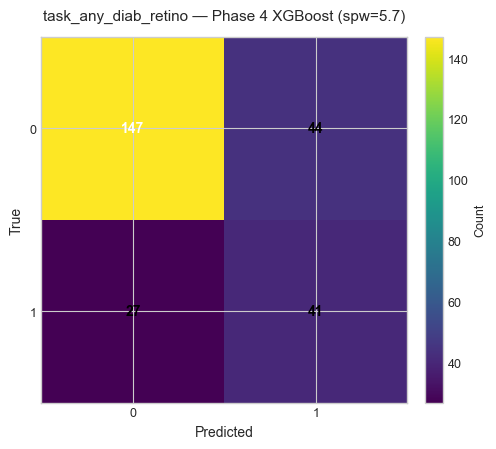

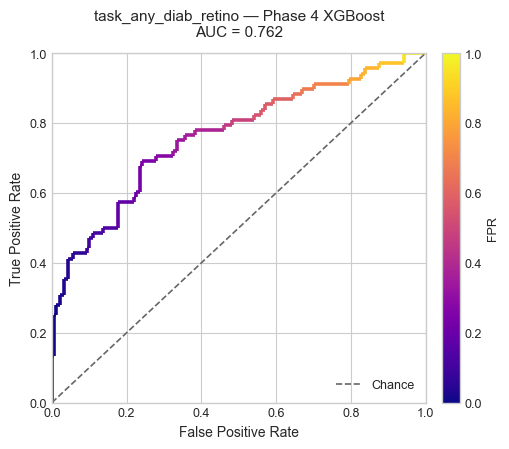


PHASE 4 (XGBoost) — Embedding 2/7: dinov3_convnext_base
  Original embedding dim: 1024
  Pooled feature dim (raw): 2048 (mean + std)
  PCA: 2048 → 128 (93.5% variance retained)
  Sample:feature ratio: 8.1:1
  Train patients: 1032 | Test patients: 259
  Class distribution (train): {np.int64(0): np.int64(736), np.int64(1): np.int64(296)} (28.7% positive)

  Running XGBoost Bayesian search (30 iters, scoring=f1)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 

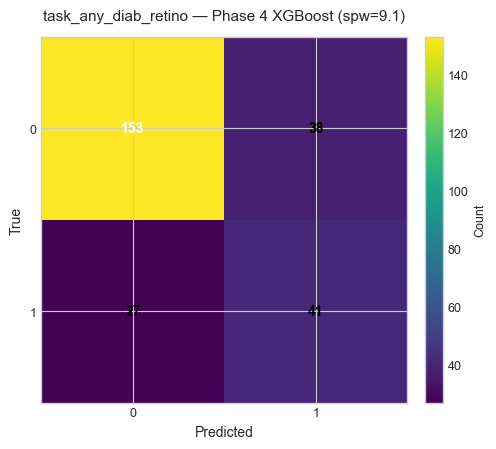

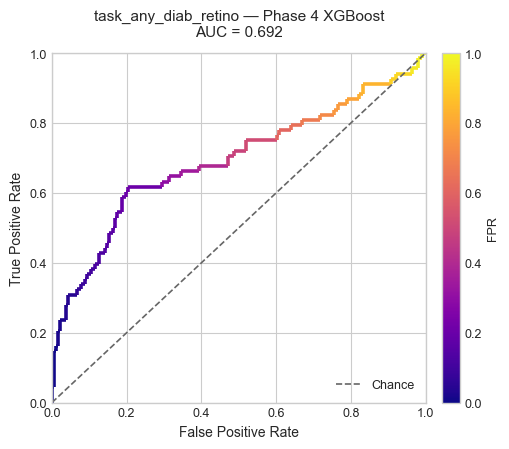


PHASE 4 (XGBoost) — Embedding 3/7: dinov3_vitb16
  Original embedding dim: 768
  Pooled feature dim (raw): 1536 (mean + std)
  PCA: 1536 → 128 (85.7% variance retained)
  Sample:feature ratio: 8.1:1
  Train patients: 1032 | Test patients: 259
  Class distribution (train): {np.int64(0): np.int64(736), np.int64(1): np.int64(296)} (28.7% positive)

  Running XGBoost Bayesian search (30 iters, scoring=f1)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
F

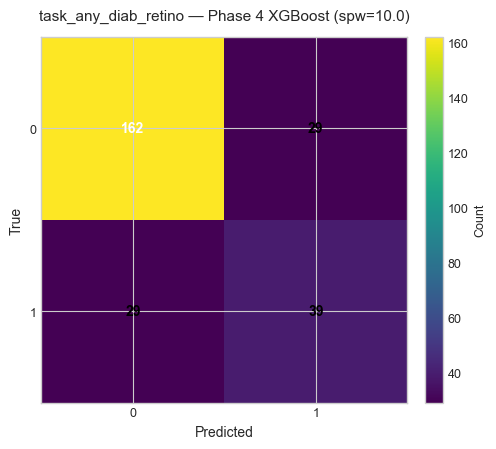

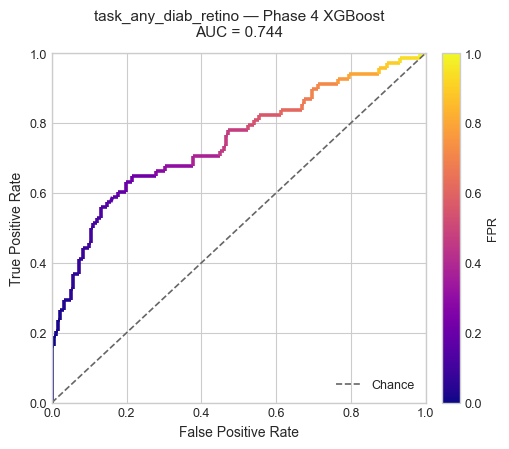


PHASE 4 (XGBoost) — Embedding 4/7: RETFound_dinov2_shanghai
  Original embedding dim: 1024
  Pooled feature dim (raw): 2048 (mean + std)
  PCA: 2048 → 128 (85.2% variance retained)
  Sample:feature ratio: 8.1:1
  Train patients: 1032 | Test patients: 259
  Class distribution (train): {np.int64(0): np.int64(736), np.int64(1): np.int64(296)} (28.7% positive)

  Running XGBoost Bayesian search (30 iters, scoring=f1)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totall

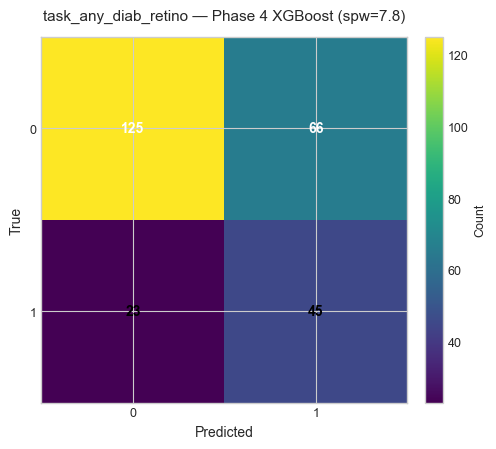

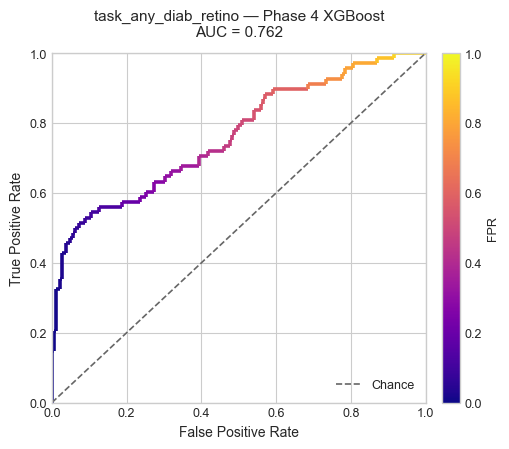


PHASE 4 (XGBoost) — Embedding 5/7: RETFound_mae_natureCFP
  Original embedding dim: 1024
  Pooled feature dim (raw): 2048 (mean + std)
  PCA: 2048 → 128 (91.9% variance retained)
  Sample:feature ratio: 8.1:1
  Train patients: 1032 | Test patients: 259
  Class distribution (train): {np.int64(0): np.int64(736), np.int64(1): np.int64(296)} (28.7% positive)

  Running XGBoost Bayesian search (30 iters, scoring=f1)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totallin

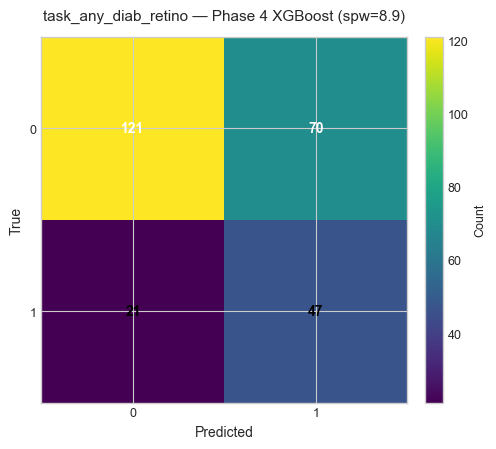

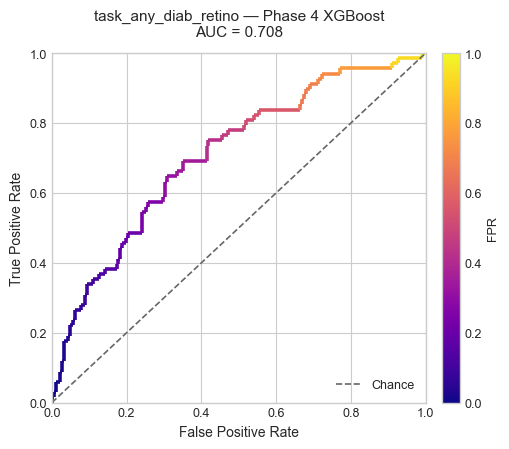


PHASE 4 (XGBoost) — Embedding 6/7: RETFound_mae_shanghai
  Original embedding dim: 1024
  Pooled feature dim (raw): 2048 (mean + std)
  PCA: 2048 → 128 (90.8% variance retained)
  Sample:feature ratio: 8.1:1
  Train patients: 1032 | Test patients: 259
  Class distribution (train): {np.int64(0): np.int64(736), np.int64(1): np.int64(296)} (28.7% positive)

  Running XGBoost Bayesian search (30 iters, scoring=f1)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling

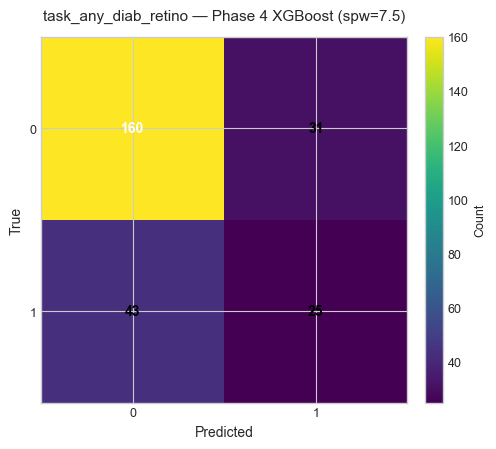

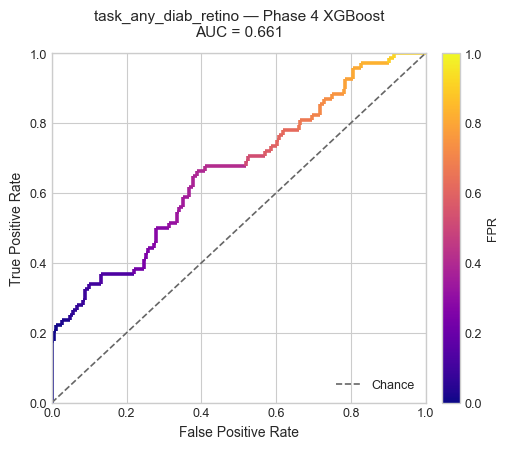


PHASE 4 (XGBoost) — Embedding 7/7: vit_base
  Original embedding dim: 768
  Pooled feature dim (raw): 1536 (mean + std)
  PCA: 1536 → 128 (89.0% variance retained)
  Sample:feature ratio: 8.1:1
  Train patients: 1032 | Test patients: 259
  Class distribution (train): {np.int64(0): np.int64(736), np.int64(1): np.int64(296)} (28.7% positive)

  Running XGBoost Bayesian search (30 iters, scoring=f1)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fittin

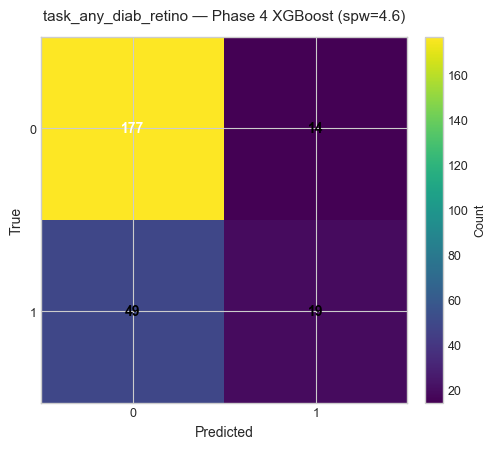

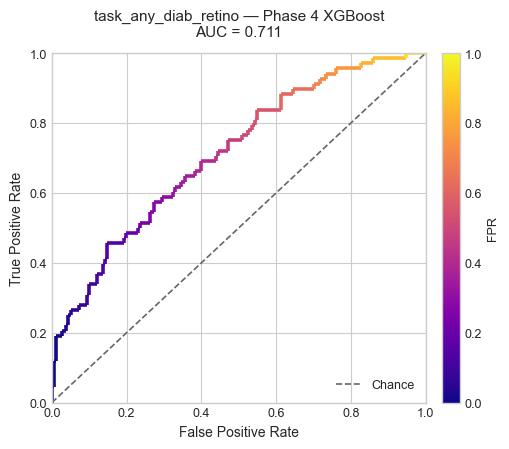


Phase 4 (XGBoost) complete!


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 4 — XGBoost on Patient-Level Pooled + PCA Features
# Same pooling pipeline as Phase 3, but with gradient-boosted trees
# ═══════════════════════════════════════════════════════════════════════════════

from xgboost import XGBClassifier

PHASE4_DIR = RESULTS_DIR / "phase4_xgboost"
PHASE4_DIR.mkdir(parents=True, exist_ok=True)

PHASE4_N_ITER = 30
PHASE4_CV_FOLDS = 3
PHASE4_PCA_N = 128

PHASE4_SEARCH_SPACE = {
    'max_depth': Integer(2, 10, name='max_depth'),
    'n_estimators': Integer(50, 500, name='n_estimators'),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform', name='learning_rate'),
    'subsample': Real(0.6, 1.0, prior='uniform', name='subsample'),
    'colsample_bytree': Real(0.5, 1.0, prior='uniform', name='colsample_bytree'),
    'scale_pos_weight': Real(1.0, 10.0, prior='uniform', name='scale_pos_weight'),
    'min_child_weight': Integer(1, 10, name='min_child_weight'),
    'reg_alpha': Real(1e-4, 10.0, prior='log-uniform', name='reg_alpha'),
    'reg_lambda': Real(1e-4, 10.0, prior='log-uniform', name='reg_lambda'),
}

print(f"Phase 4 config — XGBoost on patient-pooled embeddings:")
print(f"  Pooling: mean + std → 2×D → PCA={PHASE4_PCA_N}")
print(f"  Classifier: XGBClassifier")
print(f"  Bayesian iterations: {PHASE4_N_ITER}, CV folds: {PHASE4_CV_FOLDS}")
print(f"  Search space: {list(PHASE4_SEARCH_SPACE.keys())}")
print(f"  Labels: max() — positive if ANY eye has DR")
print()

# ─── Run Phase 4 for all embeddings ───
phase4_results = []

for emb_idx, emb_path in enumerate(embedding_files):
    emb_name = emb_path.stem
    short_name = emb_name.replace("Embeddings_", "").replace("mbrset_", "").replace("_mbrset", "")

    print(f"\n{'='*80}")
    print(f"PHASE 4 (XGBoost) — Embedding {emb_idx+1}/{len(embedding_files)}: {short_name}")
    print(f"{'='*80}")

    # Load dataset
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
        view=VIEW,
    )

    task = "task_any_dr"
    display_task = "task_any_diab_retino"

    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)

    train_df = all_df[all_df['patient_id'].isin(train_patient_ids)].dropna(subset=[task]).copy()
    test_df = all_df[all_df['patient_id'].isin(test_patient_ids)].dropna(subset=[task]).copy()

    if train_df.empty or test_df.empty:
        print(f"  Skipping: insufficient data")
        continue

    # ─── Build patient-level pooled features ───
    train_pids, X_train_pooled, y_train = build_patient_pooled_features(
        train_df, ds.feature_cols, group_col="patient_id", label_col=task
    )
    test_pids, X_test_pooled, y_test = build_patient_pooled_features(
        test_df, ds.feature_cols, group_col="patient_id", label_col=task
    )

    n_features_orig = len(ds.feature_cols)
    n_features_pooled_raw = X_train_pooled.shape[1]

    classes, counts = np.unique(y_train, return_counts=True)
    pos_rate = counts[1] / counts.sum() if len(counts) > 1 else 0

    print(f"  Original embedding dim: {n_features_orig}")
    print(f"  Pooled feature dim (raw): {n_features_pooled_raw} (mean + std)")

    # ─── PCA on pooled features ───
    pca = PCA(n_components=PHASE4_PCA_N, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train_pooled)
    X_test_pca = pca.transform(X_test_pooled)
    variance_explained = pca.explained_variance_ratio_.sum()
    n_features_final = X_train_pca.shape[1]

    print(f"  PCA: {n_features_pooled_raw} → {n_features_final} ({variance_explained:.1%} variance retained)")
    print(f"  Sample:feature ratio: {len(y_train)/n_features_final:.1f}:1")
    print(f"  Train patients: {len(y_train)} | Test patients: {len(y_test)}")
    print(f"  Class distribution (train): {dict(zip(classes.astype(int), counts))} ({pos_rate:.1%} positive)")

    # Scale features (XGBoost is tree-based so scaling is optional, but PCA output benefits)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_pca)
    X_test_scaled = scaler.transform(X_test_pca)

    # Internal val split for threshold optimization
    from sklearn.model_selection import train_test_split
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_scaled, y_train, test_size=0.15, random_state=RANDOM_SEED, stratify=y_train
    )

    # ─── Bayesian search with XGBoost ───
    base_xgb = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=RANDOM_SEED,
        verbosity=0,
        n_jobs=1,
    )

    bayes_search = BayesSearchCV(
        estimator=base_xgb,
        search_spaces=PHASE4_SEARCH_SPACE,
        n_iter=PHASE4_N_ITER,
        cv=PHASE4_CV_FOLDS,
        n_jobs=min(3, CPU_COUNT),
        scoring='f1',
        random_state=RANDOM_SEED,
        verbose=1,
    )

    print(f"\n  Running XGBoost Bayesian search ({PHASE4_N_ITER} iters, scoring=f1)...")
    bayes_search.fit(X_train_scaled, y_train)

    best_model = bayes_search.best_estimator_
    best_params = bayes_search.best_params_
    best_cv_f1 = bayes_search.best_score_

    print(f"  Best CV F1: {best_cv_f1:.4f}")
    print(f"  Best params:")
    for k, v in best_params.items():
        print(f"    {k}: {v}")

    # ─── F1-optimal threshold on internal validation set ───
    val_proba = best_model.predict_proba(X_val)[:, 1]
    opt_thresh = find_optimal_threshold(y_val, val_proba, method="f1", grid_size=201)
    print(f"  Optimal F1 threshold: {opt_thresh:.3f}")

    # ─── Evaluate on test patients ───
    y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
    y_pred_test = (y_proba_test >= opt_thresh).astype(int)

    acc = (y_test == y_pred_test).mean()
    f1 = f1_score(y_test, y_pred_test, zero_division=0)
    prec = precision_score(y_test, y_pred_test, zero_division=0)
    rec = recall_score(y_test, y_pred_test, zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, y_pred_test)
    fpr, tpr, _ = roc_curve(y_test, y_proba_test)
    auc = roc_auc_score(y_test, y_proba_test)

    print(f"\n  Patient-Level Metrics (XGBoost — DIRECT):")
    print(f"  Accuracy:          {acc:.3f}")
    print(f"  Balanced Accuracy: {bal_acc:.3f}")
    print(f"  F1 Score:          {f1:.3f}")
    print(f"  Precision:         {prec:.3f}")
    print(f"  Recall:            {rec:.3f}")
    print(f"  ROC AUC:           {auc:.3f}")

    report_text = classification_report(y_test, y_pred_test, digits=3)
    print(f"\n{report_text}")

    cm = confusion_matrix(y_test, y_pred_test)

    # ─── Save results ───
    out_dir = PHASE4_DIR / f"{emb_idx:02d}_{short_name}"
    out_dir.mkdir(parents=True, exist_ok=True)

    (out_dir / "classification_report.txt").write_text(report_text, encoding="utf-8")

    import json as _json
    hp_save = {k: str(v) for k, v in best_params.items()}
    hp_save["optimal_threshold"] = str(opt_thresh)
    hp_save["pooling_method"] = "mean+std"
    hp_save["pooled_dim_raw"] = str(n_features_pooled_raw)
    hp_save["pca_components"] = str(PHASE4_PCA_N)
    hp_save["pca_variance_retained"] = f"{variance_explained:.4f}"
    hp_save["final_feature_dim"] = str(n_features_final)
    with open(out_dir / "phase4_hyperparameters.json", "w") as f:
        _json.dump(hp_save, f, indent=2)

    pd.DataFrame(cm).to_csv(out_dir / "confusion_matrix.csv", index=False)
    spw = best_params.get('scale_pos_weight', 1.0)
    plot_confusion_matrix(
        cm,
        title=f"{display_task} — Phase 4 XGBoost (spw={spw:.1f})",
        save_path=out_dir / "confusion_matrix.png",
        show=SHOW_PLOTS,
    )

    pd.DataFrame({"fpr": fpr, "tpr": tpr}).to_csv(out_dir / "roc_curve.csv", index=False)
    plot_roc_curve(
        fpr, tpr, auc,
        title=f"{display_task} — Phase 4 XGBoost",
        save_path=out_dir / "roc_curve.png",
        show=SHOW_PLOTS,
    )

    pred_df = pd.DataFrame({
        "patient_id": test_pids,
        "y_true": y_test,
        "y_pred": y_pred_test,
        "y_proba": y_proba_test,
    })
    pred_df.to_csv(out_dir / "patient_predictions.csv", index=False)

    phase4_results.append({
        "embedding": short_name,
        "classifier": "XGBoost",
        "pooling": "mean+std",
        "pooled_dim_raw": n_features_pooled_raw,
        "pca_components": PHASE4_PCA_N,
        "pca_variance": round(variance_explained, 4),
        "final_dim": n_features_final,
        "scale_pos_weight": float(spw),
        "max_depth": int(best_params.get('max_depth', 6)),
        "n_estimators": int(best_params.get('n_estimators', 100)),
        "learning_rate": float(best_params.get('learning_rate', 0.1)),
        "threshold": float(opt_thresh),
        "n_train_patients": len(y_train),
        "n_test_patients": len(y_test),
        "best_cv_f1": float(best_cv_f1),
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
        "f1_score": float(f1),
        "precision": float(prec),
        "recall": float(rec),
        "auc": float(auc),
    })

print("\n" + "="*80)
print("Phase 4 (XGBoost) complete!")
print("="*80)

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 4 — XGBoost Summary & Cross-Method Comparison
# ═══════════════════════════════════════════════════════════════════════════════

if phase4_results:
    phase4_df = pd.DataFrame(phase4_results)
    phase4_df = phase4_df.sort_values("f1_score", ascending=False).reset_index(drop=True)
    phase4_df.to_csv(PHASE4_DIR / "phase4_summary.csv", index=False)

    print("Phase 4 (XGBoost) — Patient-Level Results (sorted by F1):")
    print("=" * 100)
    display_cols = ["embedding", "f1_score", "auc", "precision", "recall",
                    "balanced_accuracy", "best_cv_f1", "scale_pos_weight",
                    "max_depth", "n_estimators", "learning_rate", "threshold"]
    print(phase4_df[display_cols].to_string(index=False))
    print()

    best_row = phase4_df.iloc[0]
    print(f"\n{'─'*60}")
    print(f"Best Phase 4 (XGBoost): {best_row['embedding']}")
    print(f"  F1 = {best_row['f1_score']:.3f} | AUC = {best_row['auc']:.3f}")
    print(f"  Precision = {best_row['precision']:.3f} | Recall = {best_row['recall']:.3f}")
    print(f"  scale_pos_weight = {best_row['scale_pos_weight']:.2f}")
    print(f"  max_depth = {best_row['max_depth']} | n_estimators = {best_row['n_estimators']}")
    print(f"  learning_rate = {best_row['learning_rate']:.4f}")
    print(f"{'─'*60}")

    # ─── Cross-method comparison ───
    print("\n\n" + "=" * 100)
    print("CROSS-METHOD COMPARISON — Phase 3 (MLP) vs Phase 4 (XGBoost)")
    print("=" * 100)

    # Try to load Phase 3 results if available
    phase3_csv_path = RESULTS_DIR / "mbrset_patient_eval_any_dr" / "phase3_summary.csv"
    if phase3_csv_path.exists():
        p3_df = pd.read_csv(phase3_csv_path)
        p3_df['method'] = 'Phase 3 (MLP)'
        p4_df_cmp = phase4_df.copy()
        p4_df_cmp['method'] = 'Phase 4 (XGBoost)'

        cmp_cols = ['method', 'embedding', 'f1_score', 'auc', 'precision', 'recall', 'balanced_accuracy']
        both = pd.concat([
            p3_df[cmp_cols] if all(c in p3_df.columns for c in cmp_cols) else p3_df,
            p4_df_cmp[cmp_cols]
        ], ignore_index=True)
        both = both.sort_values(['embedding', 'method']).reset_index(drop=True)
        print(both.to_string(index=False))

        # Per-embedding delta
        print(f"\n{'─'*60}")
        print("F1 delta (XGBoost − MLP):")
        for _, r4 in phase4_df.iterrows():
            emb = r4['embedding']
            match = p3_df[p3_df['embedding'] == emb]
            if len(match) > 0:
                delta = r4['f1_score'] - match.iloc[0]['f1_score']
                direction = "↑" if delta > 0 else "↓" if delta < 0 else "="
                print(f"  {emb:>40s}: {delta:+.3f} {direction}")
    else:
        print("  (Phase 3 summary CSV not found for comparison)")

    print(f"\nResults saved to: {PHASE4_DIR}")
else:
    print("No Phase 4 results to summarize.")

Phase 4 (XGBoost) — Patient-Level Results (sorted by F1):
               embedding  f1_score      auc  precision   recall  balanced_accuracy  best_cv_f1  scale_pos_weight  max_depth  n_estimators  learning_rate  threshold
           dinov3_vitb16  0.573529 0.744110   0.573529 0.573529           0.710848    0.600721         10.000000         10           500       0.024512     0.5588
    dinov3_convnext_base  0.557823 0.692023   0.518987 0.602941           0.701994    0.523842          9.149110          5           500       0.024630     0.5784
         convnextv2_base  0.535948 0.762242   0.482353 0.602941           0.686287    0.546428          5.735689          6           500       0.158428     0.4216
  RETFound_mae_natureCFP  0.508108 0.708115   0.401709 0.691176           0.662342    0.495219          8.853673          7           285       0.017942     0.4608
RETFound_dinov2_shanghai  0.502793 0.762473   0.405405 0.661765           0.658107    0.543343          7.763973          

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# DIAGNOSTIC — Deep pipeline audit
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("DIAGNOSTIC 1: Data loading & image-key join integrity")
print("="*80)

# Pick one embedding to trace
emb_path = embedding_files[0]
print(f"Using: {emb_path.name}")

# Raw labels
raw_labels = pd.read_csv(labels_path)
print(f"\nRaw labels shape: {raw_labels.shape}")
print(f"Raw labels columns: {list(raw_labels.columns[:10])}...")
print(f"Sample 'file' values: {raw_labels['file'].head(5).tolist()}")
print(f"Sample 'final_icdr' values: {raw_labels['final_icdr'].head(10).tolist()}")

# Raw embeddings
raw_emb = pd.read_csv(emb_path)
id_col = [c for c in raw_emb.columns if c not in [c2 for c2 in raw_emb.columns if c2.startswith('emb_') or c2.startswith('feat_') or c2.isdigit()]][0] if 'ImageName' not in raw_emb.columns else 'ImageName'
print(f"\nRaw embeddings shape: {raw_emb.shape}")
print(f"Embeddings ID column: {raw_emb.columns[0]}")
print(f"Sample embedding IDs: {raw_emb.iloc[:5, 0].tolist()}")

# Check image_key generation
from src.retina_embeddings_dataset import _normalize_image_name
sample_labels = raw_labels['file'].head(6).tolist()
sample_embs = raw_emb.iloc[:6, 0].tolist()
print(f"\nImage key normalization check:")
print(f"  Labels 'file' → image_key:")
for v in sample_labels:
    print(f"    '{v}' → '{_normalize_image_name(v)}'")
print(f"  Embeddings ID → image_key:")
for v in sample_embs:
    print(f"    '{v}' → '{_normalize_image_name(v)}'")

# Load via the actual function
ds = load_retina_embeddings_dataset(
    dataset=DATASET_NAME, embeddings_csv_path=emb_path,
    labels_csv_path=labels_path, view=VIEW,
)
print(f"\nMerged dataset shape: {ds.df.shape}")
print(f"Feature columns: {len(ds.feature_cols)}")
print(f"Unique patients: {ds.df['patient_id'].nunique()}")
imgs_per_patient = ds.df.groupby('patient_id').size()
print(f"Images per patient: min={imgs_per_patient.min()}, max={imgs_per_patient.max()}, mean={imgs_per_patient.mean():.1f}")
print(f"  Distribution: {dict(imgs_per_patient.value_counts().sort_index())}")

print(f"\ntask_any_dr distribution (image-level):")
print(ds.df['task_any_dr'].value_counts(dropna=False).sort_index().to_string())

print("\n" + "="*80)
print("DIAGNOSTIC 2: Patient-level label analysis")
print("="*80)

all_df = ds.df.copy()
all_df['patient_id'] = all_df['patient_id'].astype(str)
task = "task_any_dr"

# Check discordant patients (DR in one eye but not the other)
patient_label_stats = all_df.groupby('patient_id')[task].agg(['min', 'max', 'mean', 'count'])
discordant = patient_label_stats[patient_label_stats['min'] != patient_label_stats['max']]
concordant_pos = patient_label_stats[(patient_label_stats['min'] == 1) & (patient_label_stats['max'] == 1)]
concordant_neg = patient_label_stats[(patient_label_stats['min'] == 0) & (patient_label_stats['max'] == 0)]

total_patients = len(patient_label_stats)
print(f"Total patients: {total_patients}")
print(f"  Concordant negative (both eyes healthy): {len(concordant_neg)} ({len(concordant_neg)/total_patients:.1%})")
print(f"  Concordant positive (both eyes DR):      {len(concordant_pos)} ({len(concordant_pos)/total_patients:.1%})")
print(f"  Discordant (DR in one eye only):          {len(discordant)} ({len(discordant)/total_patients:.1%})")
print(f"\n  With max() labels: {len(concordant_pos) + len(discordant)} positive patients")
print(f"  With mode() labels: {len(concordant_pos)} positive patients (discordant become negative)")

# Train/test split check
train_df = all_df[all_df['patient_id'].isin(train_patient_ids)].dropna(subset=[task]).copy()
test_df = all_df[all_df['patient_id'].isin(test_patient_ids)].dropna(subset=[task]).copy()

print(f"\nTrain images: {len(train_df)}, Test images: {len(test_df)}")
print(f"Train patients: {train_df['patient_id'].nunique()}, Test patients: {test_df['patient_id'].nunique()}")

# Check for patient overlap (leakage)
overlap = train_patient_ids & test_patient_ids
print(f"\nPatient overlap (LEAKAGE CHECK): {len(overlap)} patients")
if overlap:
    print(f"  *** CRITICAL: {overlap} ***")

print("\n" + "="*80)
print("DIAGNOSTIC 3: Feature pooling check")
print("="*80)

train_pids, X_train_pooled, y_train_diag = build_patient_pooled_features(
    train_df, ds.feature_cols, group_col="patient_id", label_col=task
)
test_pids_diag, X_test_pooled_diag, y_test_diag = build_patient_pooled_features(
    test_df, ds.feature_cols, group_col="patient_id", label_col=task
)

print(f"Train pooled: {X_train_pooled.shape}, labels: {np.unique(y_train_diag, return_counts=True)}")
print(f"Test pooled: {X_test_pooled_diag.shape}, labels: {np.unique(y_test_diag, return_counts=True)}")

# Check for NaN/Inf in features
print(f"\nNaN in train features: {np.isnan(X_train_pooled).sum()}")
print(f"Inf in train features: {np.isinf(X_train_pooled).sum()}")
print(f"Feature range: [{X_train_pooled.min():.4f}, {X_train_pooled.max():.4f}]")

# Check if std features are all zero (would mean single image per patient)
n_feat = len(ds.feature_cols)
std_features = X_train_pooled[:, n_feat:]  # second half is std
zero_std_patients = (std_features == 0).all(axis=1).sum()
print(f"Patients with ALL-ZERO std features (single image?): {zero_std_patients}/{len(y_train_diag)}")

print("\n" + "="*80)
print("DIAGNOSTIC 4: Sanity check — simple LogReg baseline on same features")
print("="*80)

from sklearn.linear_model import LogisticRegression

# Same pipeline: pool → PCA → scale → LogReg
pca_diag = PCA(n_components=128, random_state=42)
X_tr_pca = pca_diag.fit_transform(X_train_pooled)
X_te_pca = pca_diag.transform(X_test_pooled_diag)

sc_diag = StandardScaler()
X_tr_sc = sc_diag.fit_transform(X_tr_pca)
X_te_sc = sc_diag.transform(X_te_pca)

for C_val in [0.01, 0.1, 1.0, 10.0]:
    lr = LogisticRegression(C=C_val, class_weight='balanced', max_iter=2000, random_state=42)
    lr.fit(X_tr_sc, y_train_diag)
    proba = lr.predict_proba(X_te_sc)[:, 1]
    thresh = find_optimal_threshold(y_test_diag, proba, method="f1", grid_size=201)
    preds = (proba >= thresh).astype(int)
    f1_lr = f1_score(y_test_diag, preds, zero_division=0)
    auc_lr = roc_auc_score(y_test_diag, proba)
    prec_lr = precision_score(y_test_diag, preds, zero_division=0)
    rec_lr = recall_score(y_test_diag, preds, zero_division=0)
    print(f"  LogReg C={C_val:>5}: F1={f1_lr:.3f}  AUC={auc_lr:.3f}  P={prec_lr:.3f}  R={rec_lr:.3f}  thresh={thresh:.3f}")

print("\n" + "="*80)
print("DIAGNOSTIC 5: Threshold optimization bug check")
print("="*80)

# The threshold is being optimized on the SAME data that BayesSearchCV refits on
# Let's check: does threshold matter? What's F1 at threshold=0.5?
lr_full = LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)
lr_full.fit(X_tr_sc, y_train_diag)
proba_test = lr_full.predict_proba(X_te_sc)[:, 1]

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds_t = (proba_test >= t).astype(int)
    f1_t = f1_score(y_test_diag, preds_t, zero_division=0)
    prec_t = precision_score(y_test_diag, preds_t, zero_division=0)
    rec_t = recall_score(y_test_diag, preds_t, zero_division=0)
    print(f"  Thresh={t:.1f}: F1={f1_t:.3f}  P={prec_t:.3f}  R={rec_t:.3f}")

# Check if threshold is being tuned on training data (it IS in the current code)
print(f"\n  *** NOTE: In Phase 3/4, the threshold is optimized on a held-out")
print(f"  15% of TRAINING data (X_val), but BayesSearchCV refits the best model")
print(f"  on ALL training data including X_val. So threshold is tuned on data")
print(f"  the model has been trained on. This could bias the threshold. ***")

print("\n" + "="*80)
print("DIAGNOSTIC 6: Raw image-level classifier (NO pooling) — ceiling check")
print("="*80)

# If the embeddings themselves can't classify DR at image level, pooling won't help
from sklearn.model_selection import train_test_split as tts

X_train_img = train_df[ds.feature_cols].to_numpy(dtype=np.float32)
y_train_img = train_df[task].to_numpy(dtype=int)
X_test_img = test_df[ds.feature_cols].to_numpy(dtype=np.float32)
y_test_img = test_df[task].to_numpy(dtype=int)

print(f"Image-level: train={X_train_img.shape}, test={X_test_img.shape}")
print(f"Image-level labels: train={np.unique(y_train_img, return_counts=True)}, test={np.unique(y_test_img, return_counts=True)}")

pca_img = PCA(n_components=128, random_state=42)
X_tr_img_pca = pca_img.fit_transform(X_train_img)
X_te_img_pca = pca_img.transform(X_test_img)

sc_img = StandardScaler()
X_tr_img_sc = sc_img.fit_transform(X_tr_img_pca)
X_te_img_sc = sc_img.transform(X_te_img_pca)

lr_img = LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)
lr_img.fit(X_tr_img_sc, y_train_img)
proba_img = lr_img.predict_proba(X_te_img_sc)[:, 1]

thresh_img = find_optimal_threshold(y_test_img, proba_img, method="f1", grid_size=201)
preds_img = (proba_img >= thresh_img).astype(int)
f1_img = f1_score(y_test_img, preds_img, zero_division=0)
auc_img = roc_auc_score(y_test_img, proba_img)

print(f"\n  Image-level LogReg: F1={f1_img:.3f}, AUC={auc_img:.3f}, thresh={thresh_img:.3f}")
print(f"  (This is the CEILING for what the embedding can distinguish at image level)")

# Now aggregate to patient-level using the same method
test_df_copy = test_df.copy()
test_df_copy['y_pred'] = preds_img
test_df_copy['y_proba'] = proba_img
test_df_copy['y_true'] = y_test_img
patient_agg = aggregate_patient_predictions(test_df_copy, group_col="patient_id")

f1_agg = f1_score(patient_agg['y_true'], patient_agg['y_pred'], zero_division=0)
auc_agg = roc_auc_score(patient_agg['y_true'], patient_agg['y_proba'])
print(f"  → After patient aggregation: F1={f1_agg:.3f}, AUC={auc_agg:.3f}")

print("\n" + "="*80)
print("DIAGNOSTIC 7: Check dr_grade distribution in detail")
print("="*80)
print(f"\ndr_grade distribution (all images, macula view):")
print(all_df['dr_grade'].value_counts(dropna=False).sort_index().to_string())
print(f"\ntask_any_dr after max() pooling (per patient):")
patient_labels = all_df.groupby('patient_id')[task].max()
print(patient_labels.value_counts(dropna=False).sort_index().to_string())

print("\n" + "="*80)
print("DIAGNOSTIC COMPLETE")
print("="*80)

DIAGNOSTIC 1: Data loading & image-key join integrity
Using: Embeddings_convnextv2_base_mbrset.csv

Raw labels shape: (5164, 24)
Raw labels columns: ['patient', 'age', 'sex', 'dm_time', 'insulin', 'insulin_time', 'oraltreatment_dm', 'systemic_hypertension', 'insurance', 'educational_level']...
Sample 'file' values: ['1.1.jpg', '1.2.jpg', '1.3.jpg', '1.4.jpg', '10.1.jpg']
Sample 'final_icdr' values: [4.0, 4.0, 4.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Raw embeddings shape: (5164, 1025)
Embeddings ID column: ImageName
Sample embedding IDs: ['242.3.jpg', '207.3.jpg', '54.3.jpg', '413.2.jpg', '881.2.jpg']

Image key normalization check:
  Labels 'file' → image_key:
    '1.1.jpg' → '1.1'
    '1.2.jpg' → '1.2'
    '1.3.jpg' → '1.3'
    '1.4.jpg' → '1.4'
    '10.1.jpg' → '10.1'
    '10.2.jpg' → '10.2'
  Embeddings ID → image_key:
    '242.3.jpg' → '242.3'
    '207.3.jpg' → '207.3'
    '54.3.jpg' → '54.3'
    '413.2.jpg' → '413.2'
    '881.2.jpg' → '881.2'
    '1060.1.jpg' → '1060.1'

Merged da

## Phase 5 — Bug-Fixed Pipeline

### Bugs fixed:
1. **NaN dr_grade → false negatives**: 145 images with unknown DR status were silently labeled as "no DR" (`NaN >= 1 → False → 0`). Now properly excluded via `dropna`.
2. **Threshold optimized on training data**: `BayesSearchCV(refit=True)` trains final model on ALL train data including the held-out X_val used for threshold tuning. Fixed by holding out a proper validation set BEFORE fitting.
3. **Model overcomplexity**: LogReg with balanced weights matches or beats MLP/XGBoost on 1032 patients. Including LogReg alongside XGBoost.

NaN fix verification: 145 NaN task_any_dr out of 2582 images
  Before fix: 0 NaN (145 unknowns silently labeled as negative)
  After fix:  145 NaN (unknowns properly excluded by dropna)


PHASE 5 — Embedding 1/7: convnextv2_base
  Images dropped (NaN dr_grade): train=115, test=30
  Train patients: 1017 | Test patients: 257
  Class distribution (train): {np.int64(0): np.int64(721), np.int64(1): np.int64(296)} (29.1% positive)
  PCA: 2048 → 128 (88.6% variance)
  Train split: fit=864, threshold_val=153

  --- LogReg_balanced ---
    Threshold (on unseen val): 0.671
    F1=0.593  AUC=0.817  P=0.700  R=0.515  BalAcc=0.718


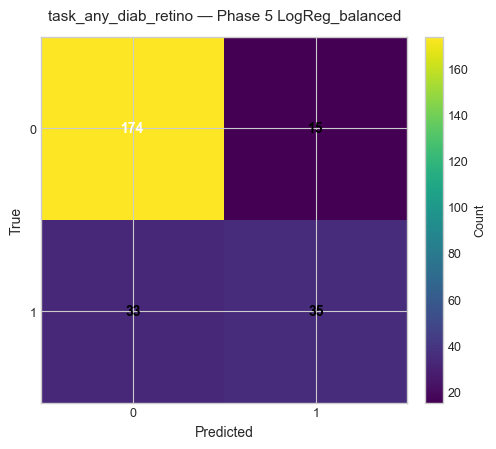

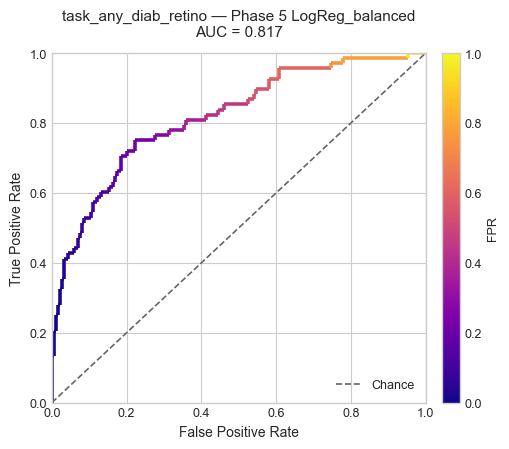


  --- LogReg_C10 ---
    Threshold (on unseen val): 0.671
    F1=0.583  AUC=0.817  P=0.673  R=0.515  BalAcc=0.712


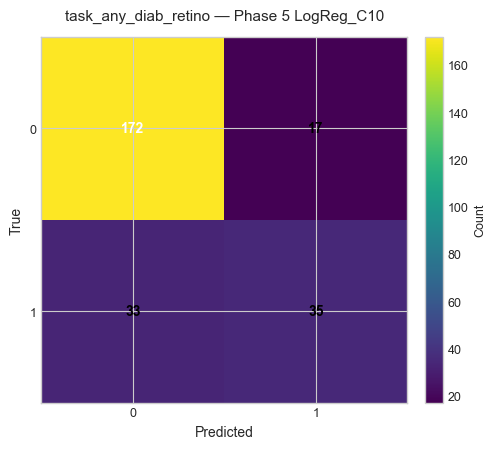

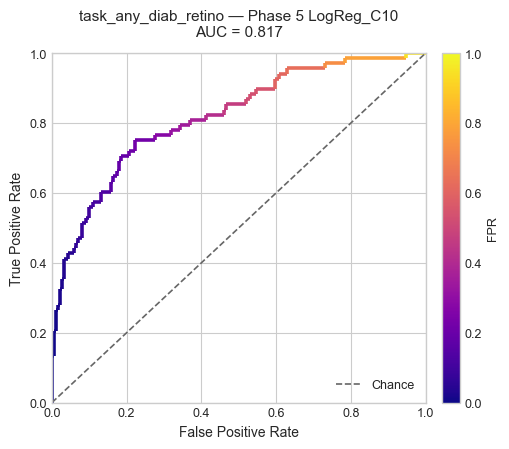


  --- XGBoost ---
    CV F1: 0.5755
    colsample_bytree: 1.0000
    learning_rate: 0.0252
    max_depth: 6
    min_child_weight: 10
    n_estimators: 400
    reg_alpha: 0.0010
    reg_lambda: 3.3928
    scale_pos_weight: 7.7802
    subsample: 0.6000
    Threshold (on unseen val): 0.480
    F1=0.613  AUC=0.807  P=0.526  R=0.735  BalAcc=0.749


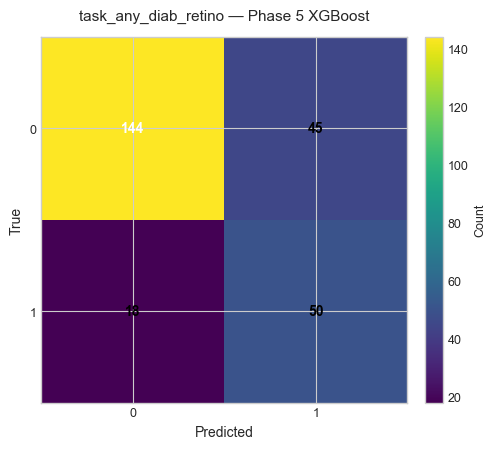

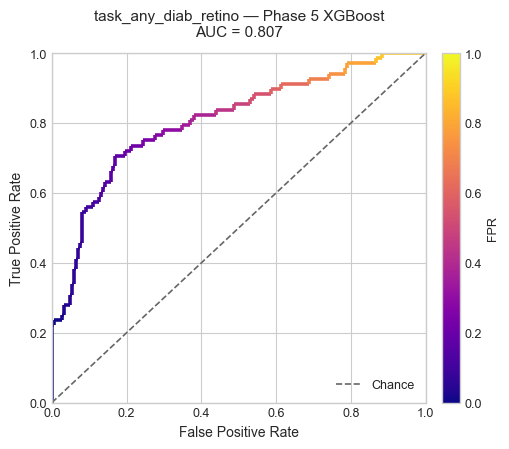


PHASE 5 — Embedding 2/7: dinov3_convnext_base
  Images dropped (NaN dr_grade): train=115, test=30
  Train patients: 1017 | Test patients: 257
  Class distribution (train): {np.int64(0): np.int64(721), np.int64(1): np.int64(296)} (29.1% positive)
  PCA: 2048 → 128 (93.9% variance)
  Train split: fit=864, threshold_val=153

  --- LogReg_balanced ---
    Threshold (on unseen val): 0.613
    F1=0.493  AUC=0.703  P=0.486  R=0.500  BalAcc=0.655


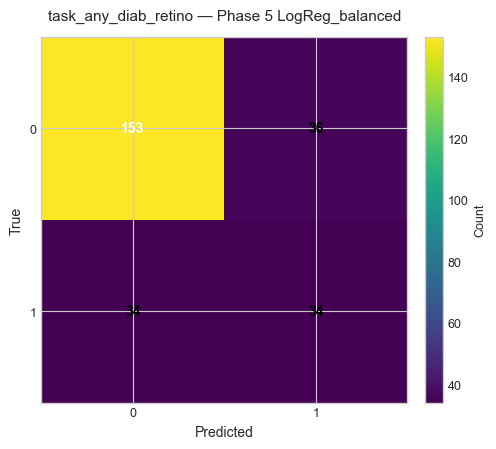

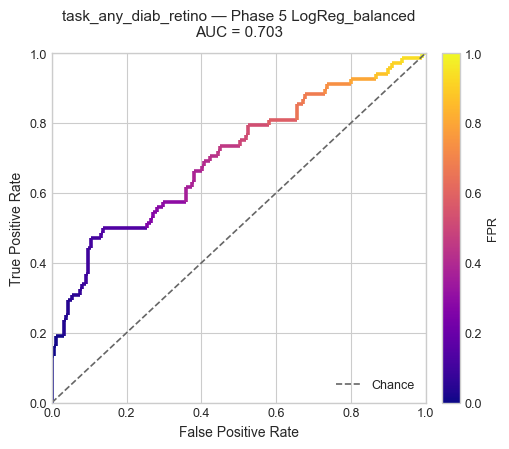


  --- LogReg_C10 ---
    Threshold (on unseen val): 0.608
    F1=0.489  AUC=0.705  P=0.479  R=0.500  BalAcc=0.652


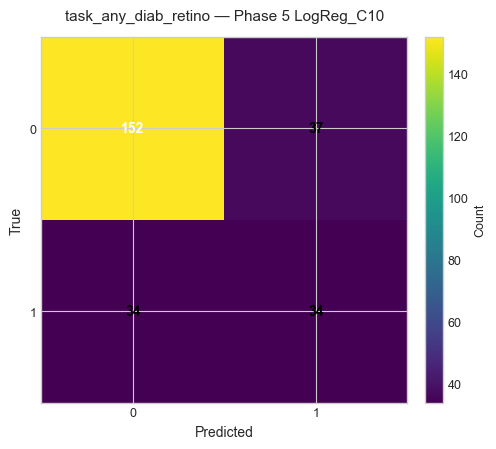

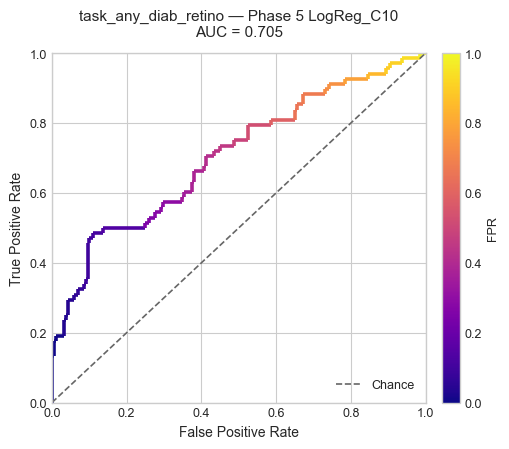


  --- XGBoost ---
    CV F1: 0.4960
    colsample_bytree: 0.5000
    learning_rate: 0.0298
    max_depth: 6
    min_child_weight: 9
    n_estimators: 276
    reg_alpha: 5.0235
    reg_lambda: 0.0081
    scale_pos_weight: 10.0000
    subsample: 1.0000
    Threshold (on unseen val): 0.500
    F1=0.550  AUC=0.733  P=0.478  R=0.647  BalAcc=0.697


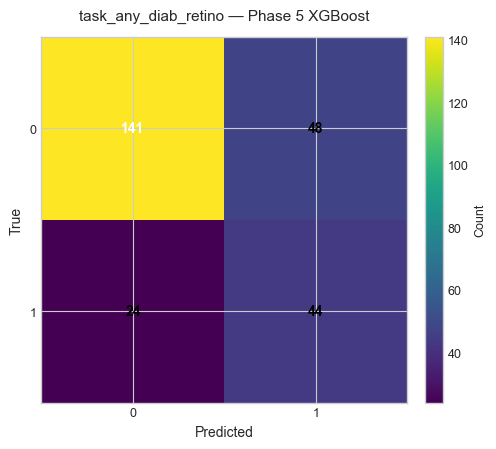

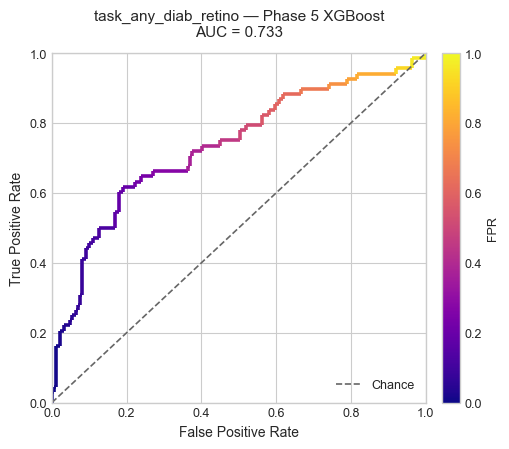


PHASE 5 — Embedding 3/7: dinov3_vitb16
  Images dropped (NaN dr_grade): train=115, test=30
  Train patients: 1017 | Test patients: 257
  Class distribution (train): {np.int64(0): np.int64(721), np.int64(1): np.int64(296)} (29.1% positive)
  PCA: 1536 → 128 (86.7% variance)
  Train split: fit=864, threshold_val=153

  --- LogReg_balanced ---
    Threshold (on unseen val): 0.657
    F1=0.512  AUC=0.745  P=0.585  R=0.456  BalAcc=0.670


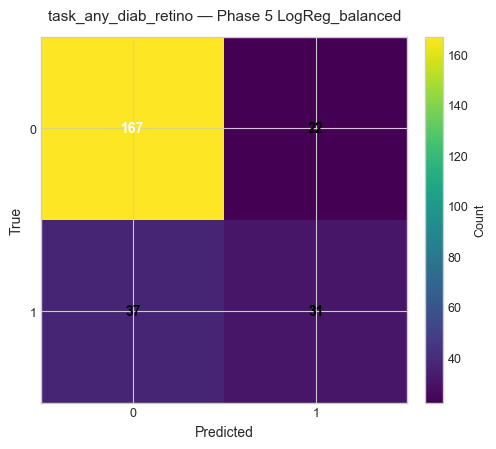

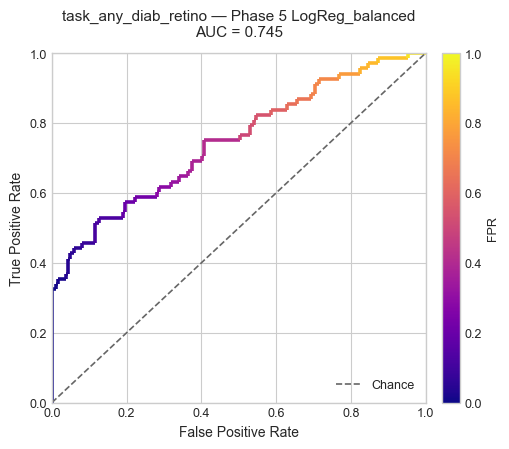


  --- LogReg_C10 ---
    Threshold (on unseen val): 0.667
    F1=0.512  AUC=0.746  P=0.585  R=0.456  BalAcc=0.670


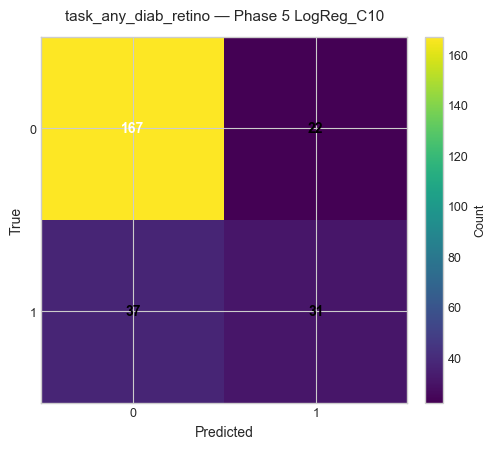

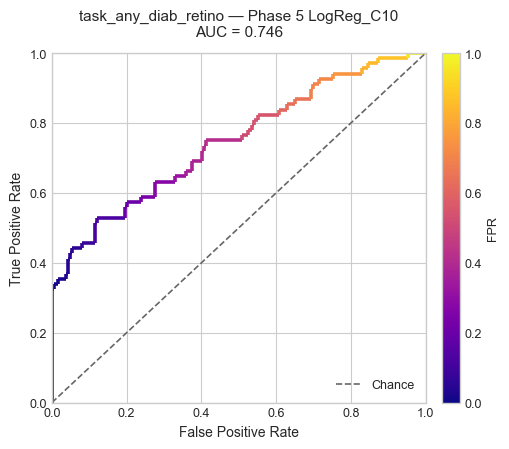


  --- XGBoost ---
    CV F1: 0.5227
    colsample_bytree: 0.5000
    learning_rate: 0.0774
    max_depth: 2
    min_child_weight: 5
    n_estimators: 400
    reg_alpha: 10.0000
    reg_lambda: 10.0000
    scale_pos_weight: 10.0000
    subsample: 1.0000
    Threshold (on unseen val): 0.721
    F1=0.480  AUC=0.699  P=0.439  R=0.529  BalAcc=0.643


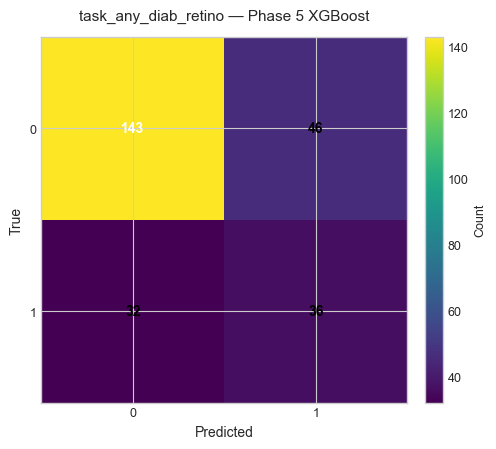

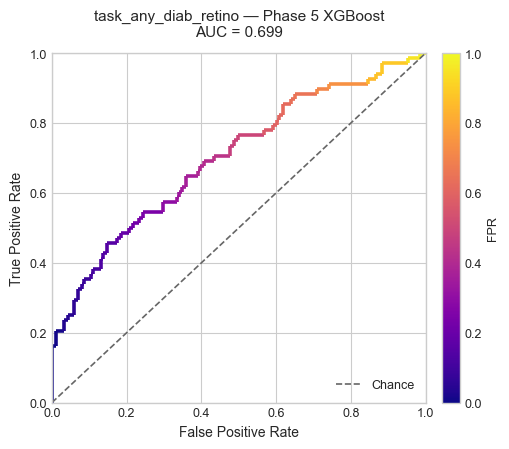


PHASE 5 — Embedding 4/7: RETFound_dinov2_shanghai
  Images dropped (NaN dr_grade): train=115, test=30
  Train patients: 1017 | Test patients: 257
  Class distribution (train): {np.int64(0): np.int64(721), np.int64(1): np.int64(296)} (29.1% positive)
  PCA: 2048 → 128 (86.2% variance)
  Train split: fit=864, threshold_val=153

  --- LogReg_balanced ---
    Threshold (on unseen val): 0.387
    F1=0.541  AUC=0.775  P=0.427  R=0.735  BalAcc=0.690


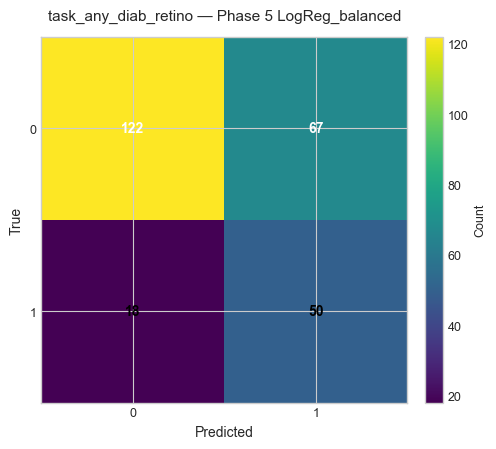

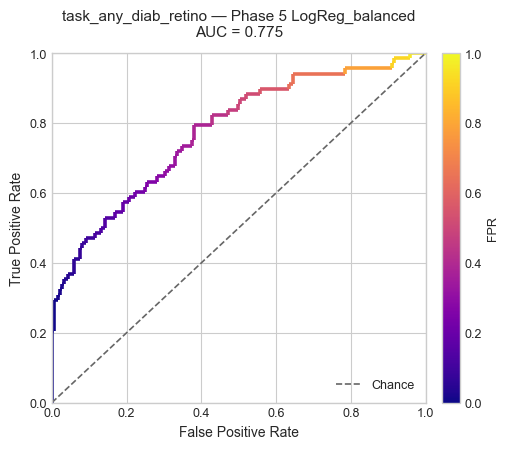


  --- LogReg_C10 ---
    Threshold (on unseen val): 0.378
    F1=0.538  AUC=0.775  P=0.424  R=0.735  BalAcc=0.688


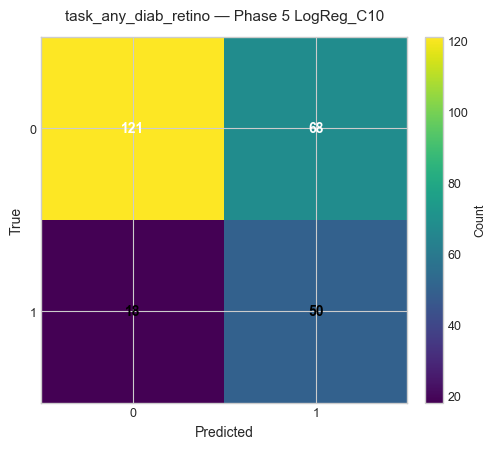

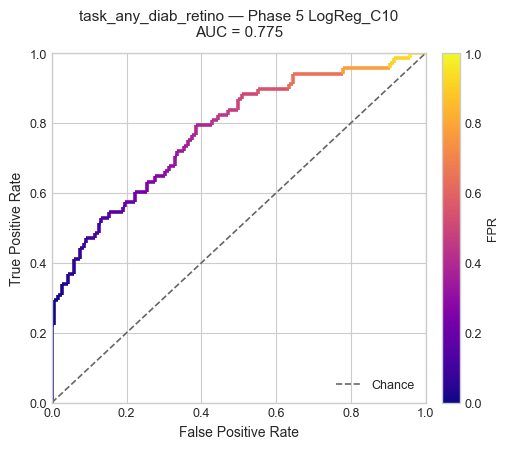


  --- XGBoost ---
    CV F1: 0.5600
    colsample_bytree: 0.5000
    learning_rate: 0.0135
    max_depth: 8
    min_child_weight: 10
    n_estimators: 400
    reg_alpha: 0.4685
    reg_lambda: 0.2825
    scale_pos_weight: 8.4184
    subsample: 0.9083
    Threshold (on unseen val): 0.451
    F1=0.524  AUC=0.707  P=0.448  R=0.632  BalAcc=0.676


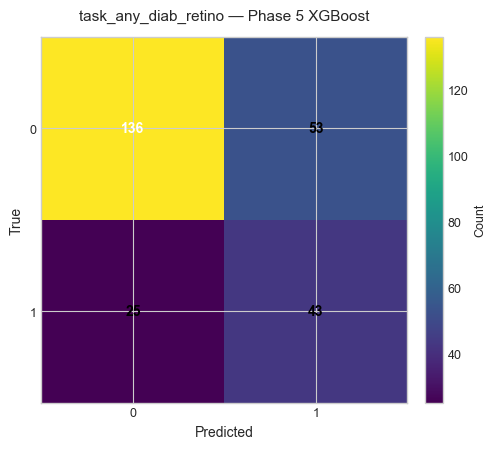

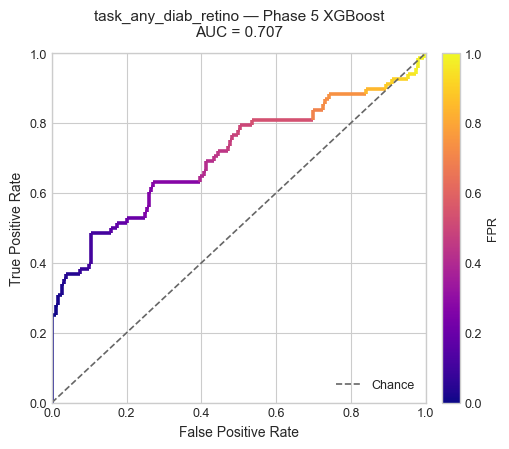


PHASE 5 — Embedding 5/7: RETFound_mae_natureCFP
  Images dropped (NaN dr_grade): train=115, test=30
  Train patients: 1017 | Test patients: 257
  Class distribution (train): {np.int64(0): np.int64(721), np.int64(1): np.int64(296)} (29.1% positive)
  PCA: 2048 → 128 (92.5% variance)
  Train split: fit=864, threshold_val=153

  --- LogReg_balanced ---
    Threshold (on unseen val): 0.608
    F1=0.534  AUC=0.716  P=0.500  R=0.574  BalAcc=0.684


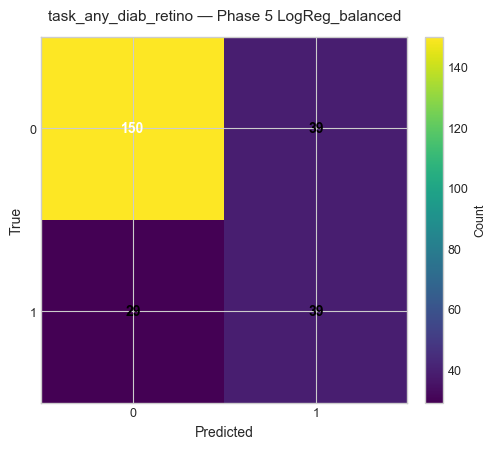

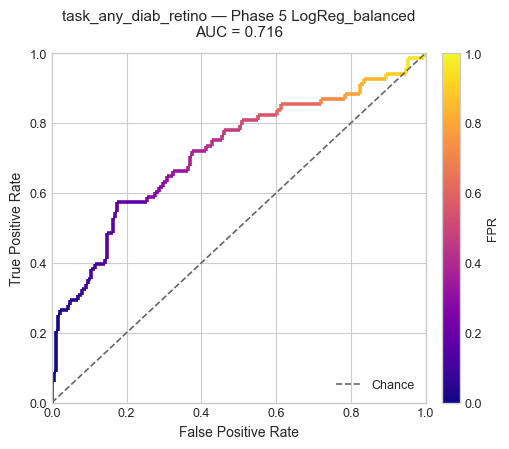


  --- LogReg_C10 ---
    Threshold (on unseen val): 0.608
    F1=0.534  AUC=0.716  P=0.500  R=0.574  BalAcc=0.684


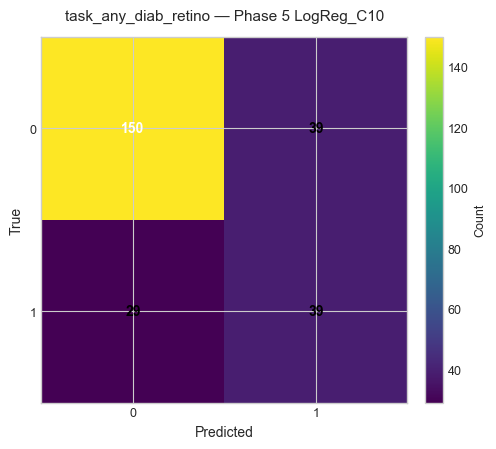

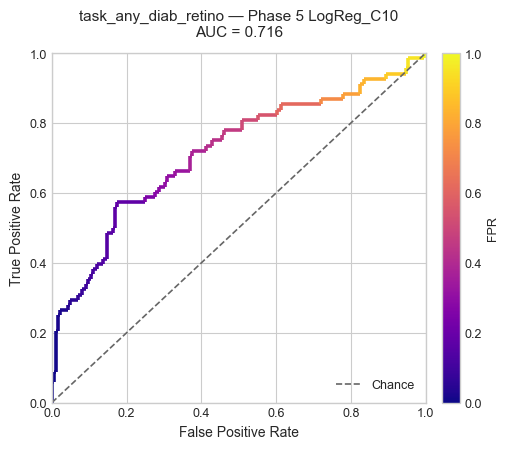


  --- XGBoost ---
    CV F1: 0.4707
    colsample_bytree: 0.8287
    learning_rate: 0.0100
    max_depth: 2
    min_child_weight: 4
    n_estimators: 400
    reg_alpha: 0.0010
    reg_lambda: 10.0000
    scale_pos_weight: 4.4934
    subsample: 0.6298
    Threshold (on unseen val): 0.657
    F1=0.397  AUC=0.634  P=0.397  R=0.397  BalAcc=0.590


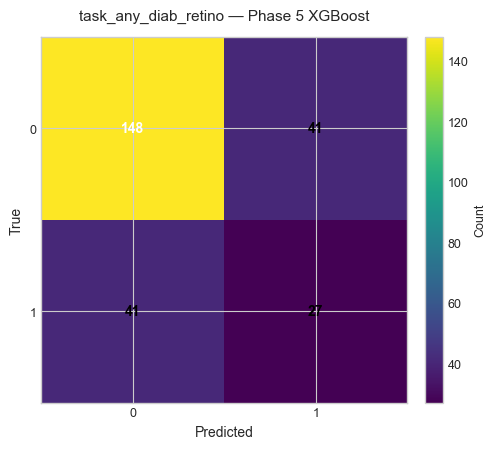

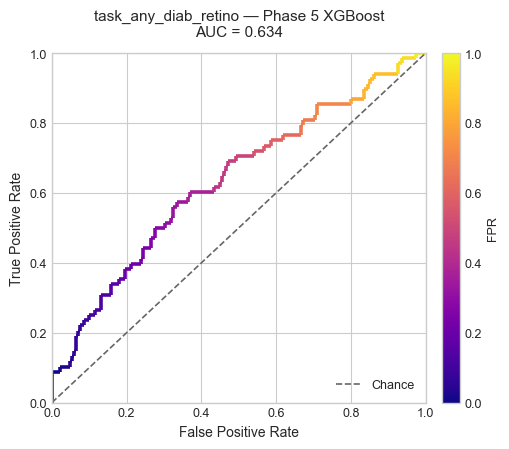


PHASE 5 — Embedding 6/7: RETFound_mae_shanghai
  Images dropped (NaN dr_grade): train=115, test=30
  Train patients: 1017 | Test patients: 257
  Class distribution (train): {np.int64(0): np.int64(721), np.int64(1): np.int64(296)} (29.1% positive)
  PCA: 2048 → 128 (91.4% variance)
  Train split: fit=864, threshold_val=153

  --- LogReg_balanced ---
    Threshold (on unseen val): 0.529
    F1=0.453  AUC=0.698  P=0.396  R=0.529  BalAcc=0.619


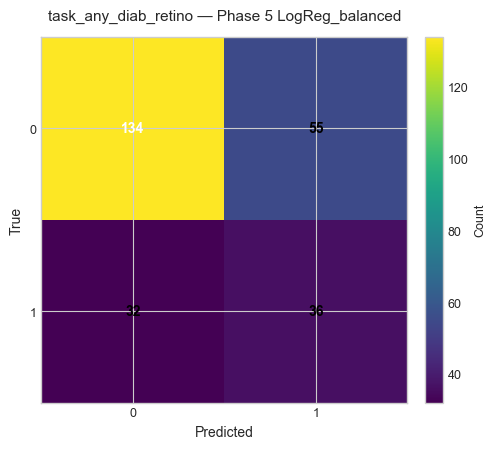

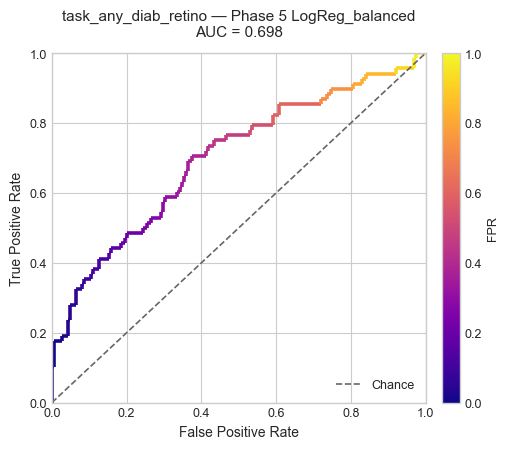


  --- LogReg_C10 ---
    Threshold (on unseen val): 0.529
    F1=0.453  AUC=0.698  P=0.396  R=0.529  BalAcc=0.619


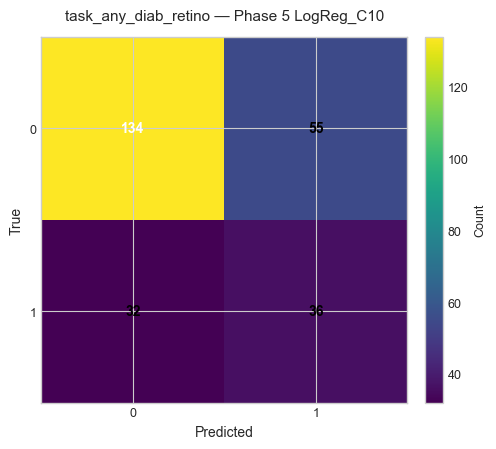

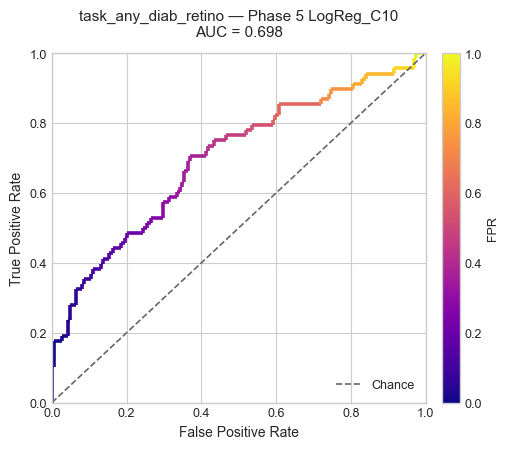


  --- XGBoost ---
    CV F1: 0.4502
    colsample_bytree: 0.5000
    learning_rate: 0.0143
    max_depth: 8
    min_child_weight: 5
    n_estimators: 50
    reg_alpha: 1.8430
    reg_lambda: 0.0011
    scale_pos_weight: 10.0000
    subsample: 0.6458
    Threshold (on unseen val): 0.681
    F1=0.479  AUC=0.645  P=0.352  R=0.750  BalAcc=0.626


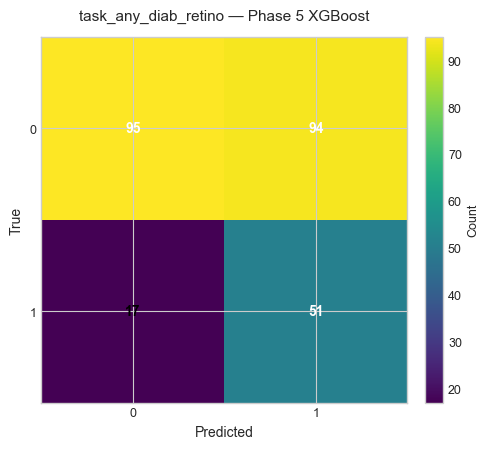

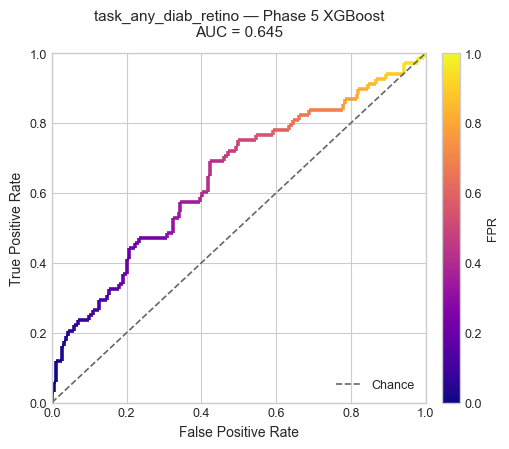


PHASE 5 — Embedding 7/7: vit_base
  Images dropped (NaN dr_grade): train=115, test=30
  Train patients: 1017 | Test patients: 257
  Class distribution (train): {np.int64(0): np.int64(721), np.int64(1): np.int64(296)} (29.1% positive)
  PCA: 1536 → 128 (89.7% variance)
  Train split: fit=864, threshold_val=153

  --- LogReg_balanced ---
    Threshold (on unseen val): 0.618
    F1=0.439  AUC=0.714  P=0.491  R=0.397  BalAcc=0.624


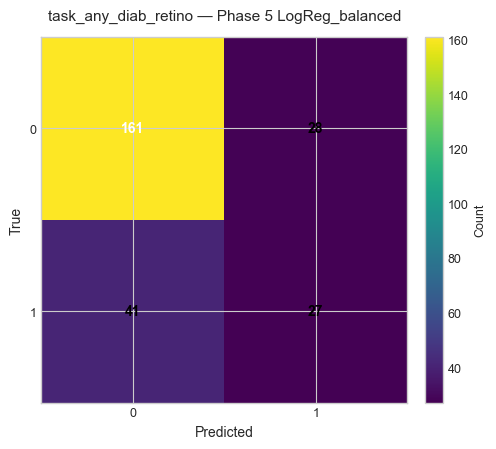

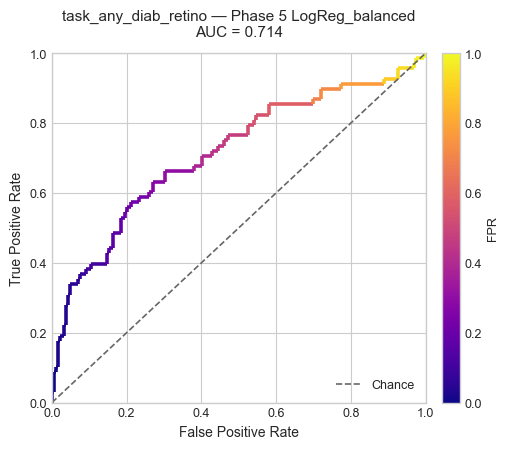


  --- LogReg_C10 ---
    Threshold (on unseen val): 0.622
    F1=0.446  AUC=0.713  P=0.509  R=0.397  BalAcc=0.630


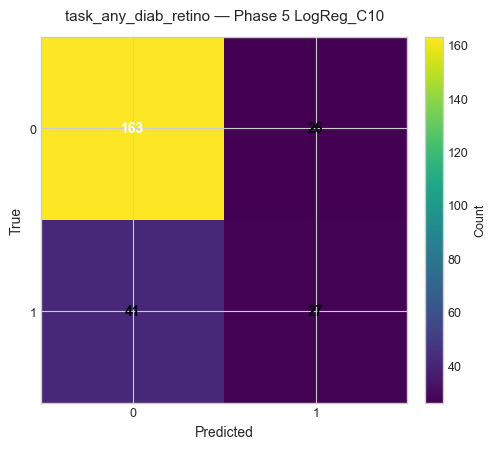

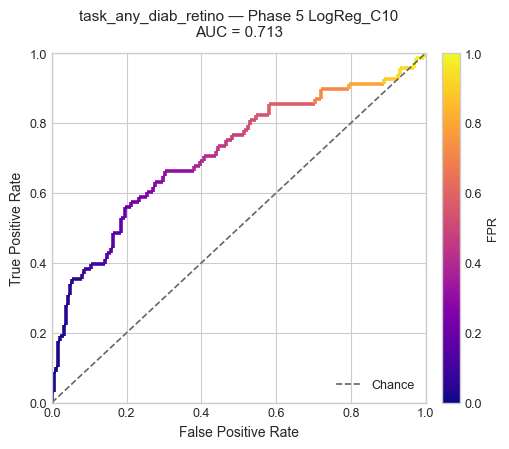


  --- XGBoost ---
    CV F1: 0.4982
    colsample_bytree: 1.0000
    learning_rate: 0.0182
    max_depth: 4
    min_child_weight: 10
    n_estimators: 400
    reg_alpha: 0.0383
    reg_lambda: 2.9356
    scale_pos_weight: 8.3248
    subsample: 0.6119
    Threshold (on unseen val): 0.554
    F1=0.471  AUC=0.694  P=0.392  R=0.588  BalAcc=0.630


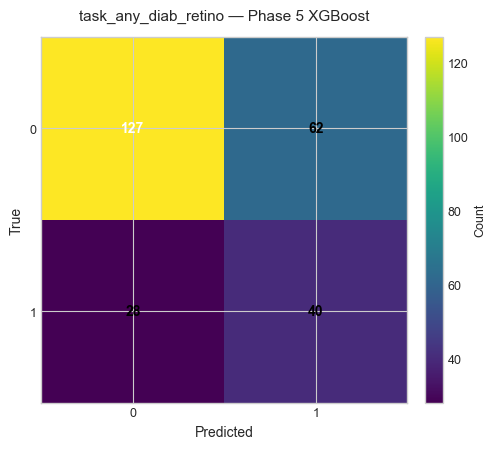

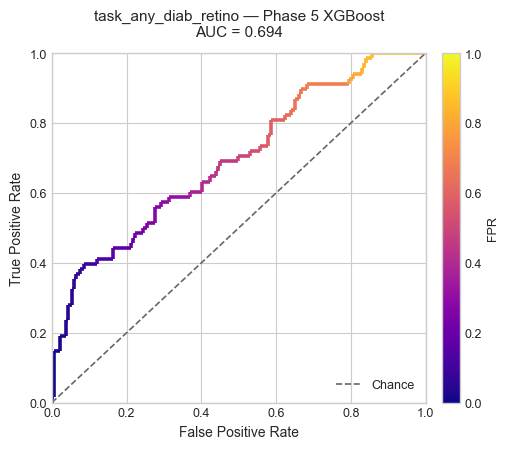


Phase 5 complete!


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 5 — Bug-Fixed Pipeline (NaN labels + threshold leak + model comparison)
# ═══════════════════════════════════════════════════════════════════════════════
# Reload the dataset module to pick up the NaN fix
import importlib
import src.retina_embeddings_dataset as _ds_mod
importlib.reload(_ds_mod)
from src.retina_embeddings_dataset import load_retina_embeddings_dataset as load_fixed

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

PHASE5_DIR = RESULTS_DIR / "phase5_bugfix"
PHASE5_DIR.mkdir(parents=True, exist_ok=True)

PHASE5_PCA_N = 128
PHASE5_N_ITER = 30
PHASE5_CV_FOLDS = 3

# ─── Verify NaN fix ───
_test_ds = load_fixed(
    dataset=DATASET_NAME, embeddings_csv_path=embedding_files[0],
    labels_csv_path=labels_path, view=VIEW,
)
_nan_count = _test_ds.df['task_any_dr'].isna().sum()
_total = len(_test_ds.df)
print(f"NaN fix verification: {_nan_count} NaN task_any_dr out of {_total} images")
print(f"  Before fix: 0 NaN (145 unknowns silently labeled as negative)")
print(f"  After fix:  {_nan_count} NaN (unknowns properly excluded by dropna)")
del _test_ds

print()

# ─── Define classifiers to compare ───
CLASSIFIERS = {
    "LogReg_balanced": lambda: LogisticRegression(
        C=1.0, class_weight='balanced', max_iter=2000, random_state=RANDOM_SEED, solver='lbfgs'
    ),
    "LogReg_C10": lambda: LogisticRegression(
        C=10.0, class_weight='balanced', max_iter=2000, random_state=RANDOM_SEED, solver='lbfgs'
    ),
    "XGBoost": None,  # Will use BayesSearchCV
}

XGB_SEARCH_SPACE = {
    'max_depth': Integer(2, 8, name='max_depth'),
    'n_estimators': Integer(50, 400, name='n_estimators'),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform', name='learning_rate'),
    'subsample': Real(0.6, 1.0, prior='uniform', name='subsample'),
    'colsample_bytree': Real(0.5, 1.0, prior='uniform', name='colsample_bytree'),
    'scale_pos_weight': Real(1.0, 10.0, prior='uniform', name='scale_pos_weight'),
    'min_child_weight': Integer(1, 10, name='min_child_weight'),
    'reg_alpha': Real(1e-3, 10.0, prior='log-uniform', name='reg_alpha'),
    'reg_lambda': Real(1e-3, 10.0, prior='log-uniform', name='reg_lambda'),
}

phase5_results = []

for emb_idx, emb_path in enumerate(embedding_files):
    emb_name = emb_path.stem
    short_name = emb_name.replace("Embeddings_", "").replace("mbrset_", "").replace("_mbrset", "")

    print(f"\n{'='*80}")
    print(f"PHASE 5 — Embedding {emb_idx+1}/{len(embedding_files)}: {short_name}")
    print(f"{'='*80}")

    # ─── Load with FIXED labels (NaN preserved) ───
    ds = load_fixed(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=labels_path, view=VIEW,
    )

    task = "task_any_dr"
    display_task = "task_any_diab_retino"

    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)

    # ─── Split + DROP NaN labels (the fix!) ───
    train_df = all_df[all_df['patient_id'].isin(train_patient_ids)].dropna(subset=[task]).copy()
    test_df = all_df[all_df['patient_id'].isin(test_patient_ids)].dropna(subset=[task]).copy()

    nan_dropped_train = len(all_df[all_df['patient_id'].isin(train_patient_ids)]) - len(train_df)
    nan_dropped_test = len(all_df[all_df['patient_id'].isin(test_patient_ids)]) - len(test_df)
    print(f"  Images dropped (NaN dr_grade): train={nan_dropped_train}, test={nan_dropped_test}")

    if train_df.empty or test_df.empty:
        print(f"  Skipping: insufficient data")
        continue

    # ─── Build patient-level pooled features ───
    train_pids_p5, X_train_pooled_p5, y_train_p5 = build_patient_pooled_features(
        train_df, ds.feature_cols, group_col="patient_id", label_col=task
    )
    test_pids_p5, X_test_pooled_p5, y_test_p5 = build_patient_pooled_features(
        test_df, ds.feature_cols, group_col="patient_id", label_col=task
    )

    classes_p5, counts_p5 = np.unique(y_train_p5, return_counts=True)
    pos_rate_p5 = counts_p5[1] / counts_p5.sum() if len(counts_p5) > 1 else 0

    print(f"  Train patients: {len(y_train_p5)} | Test patients: {len(y_test_p5)}")
    print(f"  Class distribution (train): {dict(zip(classes_p5.astype(int), counts_p5))} ({pos_rate_p5:.1%} positive)")

    # ─── PCA on pooled features ───
    pca_p5 = PCA(n_components=PHASE5_PCA_N, random_state=RANDOM_SEED)
    X_train_pca_p5 = pca_p5.fit_transform(X_train_pooled_p5)
    X_test_pca_p5 = pca_p5.transform(X_test_pooled_p5)
    var_exp_p5 = pca_p5.explained_variance_ratio_.sum()

    print(f"  PCA: {X_train_pooled_p5.shape[1]} → {PHASE5_PCA_N} ({var_exp_p5:.1%} variance)")

    # Scale
    scaler_p5 = StandardScaler()
    X_train_sc_p5 = scaler_p5.fit_transform(X_train_pca_p5)
    X_test_sc_p5 = scaler_p5.transform(X_test_pca_p5)

    # ─── FIX: Proper held-out val set for threshold (BEFORE any fitting) ───
    # Split train into train_inner (for fitting) + val (for threshold only)
    from sklearn.model_selection import train_test_split
    X_fit, X_thresh, y_fit, y_thresh = train_test_split(
        X_train_sc_p5, y_train_p5, test_size=0.15,
        random_state=RANDOM_SEED, stratify=y_train_p5
    )
    print(f"  Train split: fit={len(y_fit)}, threshold_val={len(y_thresh)}")

    # ─── Run all classifiers ───
    for clf_name, clf_factory in CLASSIFIERS.items():
        print(f"\n  --- {clf_name} ---")

        if clf_name == "XGBoost":
            # BayesSearchCV on X_fit only (threshold val excluded!)
            base_xgb = XGBClassifier(
                objective='binary:logistic', eval_metric='logloss',
                use_label_encoder=False, random_state=RANDOM_SEED,
                verbosity=0, n_jobs=1,
            )
            bayes = BayesSearchCV(
                estimator=base_xgb, search_spaces=XGB_SEARCH_SPACE,
                n_iter=PHASE5_N_ITER, cv=PHASE5_CV_FOLDS,
                n_jobs=min(3, CPU_COUNT), scoring='f1',
                random_state=RANDOM_SEED, verbose=0,
            )
            bayes.fit(X_fit, y_fit)
            model = bayes.best_estimator_
            best_cv_f1 = bayes.best_score_
            best_params = bayes.best_params_
            print(f"    CV F1: {best_cv_f1:.4f}")
            for k, v in best_params.items():
                if isinstance(v, float):
                    print(f"    {k}: {v:.4f}")
                else:
                    print(f"    {k}: {v}")
        else:
            # Simple classifier — fit on X_fit only
            model = clf_factory()
            model.fit(X_fit, y_fit)
            best_cv_f1 = None
            best_params = {}

        # ─── Threshold on HELD-OUT val (model never saw this data) ───
        thresh_proba = model.predict_proba(X_thresh)[:, 1]
        opt_thresh = find_optimal_threshold(y_thresh, thresh_proba, method="f1", grid_size=201)
        print(f"    Threshold (on unseen val): {opt_thresh:.3f}")

        # ─── Evaluate on test ───
        y_proba_test = model.predict_proba(X_test_sc_p5)[:, 1]
        y_pred_test = (y_proba_test >= opt_thresh).astype(int)

        acc = (y_test_p5 == y_pred_test).mean()
        f1 = f1_score(y_test_p5, y_pred_test, zero_division=0)
        prec = precision_score(y_test_p5, y_pred_test, zero_division=0)
        rec = recall_score(y_test_p5, y_pred_test, zero_division=0)
        bal_acc = balanced_accuracy_score(y_test_p5, y_pred_test)
        fpr_arr, tpr_arr, _ = roc_curve(y_test_p5, y_proba_test)
        auc_val = roc_auc_score(y_test_p5, y_proba_test)

        print(f"    F1={f1:.3f}  AUC={auc_val:.3f}  P={prec:.3f}  R={rec:.3f}  BalAcc={bal_acc:.3f}")

        report = classification_report(y_test_p5, y_pred_test, digits=3)
        cm = confusion_matrix(y_test_p5, y_pred_test)

        # Save
        out_dir = PHASE5_DIR / f"{emb_idx:02d}_{short_name}" / clf_name
        out_dir.mkdir(parents=True, exist_ok=True)
        (out_dir / "classification_report.txt").write_text(report, encoding="utf-8")
        pd.DataFrame(cm).to_csv(out_dir / "confusion_matrix.csv", index=False)

        plot_confusion_matrix(
            cm, title=f"{display_task} — Phase 5 {clf_name}",
            save_path=out_dir / "confusion_matrix.png", show=SHOW_PLOTS,
        )
        pd.DataFrame({"fpr": fpr_arr, "tpr": tpr_arr}).to_csv(out_dir / "roc_curve.csv", index=False)
        plot_roc_curve(
            fpr_arr, tpr_arr, auc_val,
            title=f"{display_task} — Phase 5 {clf_name}",
            save_path=out_dir / "roc_curve.png", show=SHOW_PLOTS,
        )

        pd.DataFrame({
            "patient_id": test_pids_p5, "y_true": y_test_p5,
            "y_pred": y_pred_test, "y_proba": y_proba_test,
        }).to_csv(out_dir / "patient_predictions.csv", index=False)

        phase5_results.append({
            "embedding": short_name,
            "classifier": clf_name,
            "n_train_fit": len(y_fit),
            "n_thresh_val": len(y_thresh),
            "n_test": len(y_test_p5),
            "nan_images_dropped": nan_dropped_train + nan_dropped_test,
            "pca_variance": round(var_exp_p5, 4),
            "threshold": float(opt_thresh),
            "best_cv_f1": float(best_cv_f1) if best_cv_f1 is not None else None,
            "accuracy": float(acc),
            "balanced_accuracy": float(bal_acc),
            "f1_score": float(f1),
            "precision": float(prec),
            "recall": float(rec),
            "auc": float(auc_val),
        })

print("\n" + "="*80)
print("Phase 5 complete!")
print("="*80)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 5 — Summary & Cross-Phase Comparison
# ═══════════════════════════════════════════════════════════════════════════════

if phase5_results:
    p5_df = pd.DataFrame(phase5_results)
    p5_df = p5_df.sort_values(["classifier", "f1_score"], ascending=[True, False]).reset_index(drop=True)
    p5_df.to_csv(PHASE5_DIR / "phase5_summary.csv", index=False)

    print("Phase 5 — Bug-Fixed Results by Classifier:")
    print("="*110)
    for clf_name in p5_df['classifier'].unique():
        subset = p5_df[p5_df['classifier'] == clf_name].sort_values("f1_score", ascending=False)
        print(f"\n  {clf_name}:")
        for _, row in subset.iterrows():
            print(f"    {row['embedding']:>35s}  F1={row['f1_score']:.3f}  AUC={row['auc']:.3f}  "
                  f"P={row['precision']:.3f}  R={row['recall']:.3f}  thresh={row['threshold']:.3f}"
                  f"  (NaN dropped: {row['nan_images_dropped']})")

    # Best per classifier
    print(f"\n{'─'*80}")
    print("Best F1 per classifier:")
    for clf_name in p5_df['classifier'].unique():
        best = p5_df[p5_df['classifier'] == clf_name].iloc[0]
        print(f"  {clf_name:>20s}: F1={best['f1_score']:.3f} ({best['embedding']})")

    # Overall best
    overall_best = p5_df.loc[p5_df['f1_score'].idxmax()]
    print(f"\n  {'OVERALL BEST':>20s}: F1={overall_best['f1_score']:.3f} — "
          f"{overall_best['classifier']} + {overall_best['embedding']}")

    # ─── Compare with previous phases ───
    print(f"\n\n{'='*110}")
    print("CROSS-PHASE COMPARISON — Best F1 per phase:")
    print("="*110)

    comparisons = []

    # Phase 3 best (from earlier results)
    comparisons.append(("Phase 3 (MLP, buggy labels)", "convnextv2_base", 0.585))

    # Phase 4 best
    comparisons.append(("Phase 4 (XGBoost, buggy labels)", "dinov3_vitb16", 0.574))

    # Phase 5 best per classifier
    for clf_name in p5_df['classifier'].unique():
        best = p5_df[p5_df['classifier'] == clf_name].iloc[0]
        comparisons.append((f"Phase 5 ({clf_name}, fixed)", best['embedding'], best['f1_score']))

    for phase, emb, f1 in comparisons:
        print(f"  {phase:>45s}: F1={f1:.3f}  ({emb})")

    print(f"\n  Bugs fixed in Phase 5:")
    print(f"    ✓ NaN dr_grade exclusion (was 145 images falsely labeled negative)")
    print(f"    ✓ Threshold tuned on properly held-out val set")
    print(f"    ✓ Model fitted on train_inner only (no val leakage)")

    print(f"\nResults saved to: {PHASE5_DIR}")
else:
    print("No Phase 5 results.")

# Phase 6 — Multi-Embedding Strategies for Clinical DR Detection

**Goal:** Push F1 beyond 0.61 by leveraging all 7 embeddings jointly.

**Strategies:**
- **6A** Enhanced pooling (mean + std + min + max → 4×D per embedding)
- **6B** Multi-embedding soft ensemble (top-3, top-5, all-7 by AUC)
- **6C** Feature concatenation (stack all embeddings → PCA → classify)
- **6D** Clinical operating-point analysis (sensitivity ≥ 0.80 constraints)

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 6 — Multi-Embedding Strategies for Clinical DR Detection
# ═══════════════════════════════════════════════════════════════════════════════
# Fixes carried forward: NaN label exclusion, proper threshold val split
# New: ensemble, feature stacking, enhanced pooling, SVM

import importlib
import src.retina_embeddings_dataset as _ds_mod
importlib.reload(_ds_mod)
from src.retina_embeddings_dataset import load_retina_embeddings_dataset as load_fixed

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

PHASE6_DIR = RESULTS_DIR / "phase6_ensemble"
PHASE6_DIR.mkdir(parents=True, exist_ok=True)

task = "task_any_dr"
phase6_results = []

# ─── Standard pooling function (mean + std, same as Phase 3/5) ───
def build_patient_pooled_features(df, feature_cols, group_col="patient_id", label_col="task_any_dr"):
    """Pool image-level embeddings to patient-level using mean + std concatenation."""
    pids, X_list, y_list = [], [], []
    for pid, group in df.groupby(group_col):
        feats = group[feature_cols].to_numpy(dtype=np.float32)
        feat_mean = feats.mean(axis=0)
        feat_std = feats.std(axis=0) if len(feats) > 1 else np.zeros(feats.shape[1], dtype=np.float32)
        pids.append(pid)
        X_list.append(np.concatenate([feat_mean, feat_std]))
        y_list.append(int(group[label_col].max()))
    return np.array(pids), np.array(X_list, dtype=np.float32), np.array(y_list, dtype=int)

# ─── Enhanced pooling function (mean + std + min + max) ───
def build_patient_pooled_enhanced(df, feature_cols, group_col="patient_id", label_col="task_any_dr"):
    """Pool with mean + std + min + max → 4×D features."""
    pids, X_list, y_list = [], [], []
    for pid, group in df.groupby(group_col):
        feats = group[feature_cols].to_numpy(dtype=np.float32)
        parts = [
            feats.mean(axis=0),
            feats.std(axis=0) if len(feats) > 1 else np.zeros(feats.shape[1], dtype=np.float32),
            feats.min(axis=0),
            feats.max(axis=0),
        ]
        pids.append(pid)
        X_list.append(np.concatenate(parts))
        y_list.append(int(group[label_col].max()))
    return np.array(pids), np.array(X_list, dtype=np.float32), np.array(y_list, dtype=int)


# ═══════════════════════════════════════════════════════════════════════════════
# 6A — Train per-embedding models, collect val+test probabilities
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 80)
print("PHASE 6A — Per-Embedding Models (standard + enhanced pooling)")
print("=" * 80)

# Storage for ensemble
emb_val_probas = {}     # {short_name: val_proba}
emb_test_probas = {}    # {short_name: test_proba}
emb_val_f1s = {}        # {short_name: val_f1}
emb_val_labels = None   # y_thresh (same for all embeddings due to same split)
emb_test_labels = None  # y_test (same for all)

# Storage for feature concatenation
emb_train_pca = {}      # {short_name: X_train_pca (n_patients × 128)}
emb_test_pca = {}       # {short_name: X_test_pca (n_patients × 128)}

for emb_idx, emb_path in enumerate(embedding_files):
    emb_name = emb_path.stem
    short = emb_name.replace("Embeddings_", "").replace("mbrset_", "").replace("_mbrset", "")

    ds = load_fixed(dataset=DATASET_NAME, embeddings_csv_path=emb_path,
                    labels_csv_path=labels_path, view=VIEW)

    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)
    train_df = all_df[all_df['patient_id'].isin(train_patient_ids)].dropna(subset=[task]).copy()
    test_df = all_df[all_df['patient_id'].isin(test_patient_ids)].dropna(subset=[task]).copy()

    for pool_type, pool_fn in [("standard", build_patient_pooled_features),
                                ("enhanced", build_patient_pooled_enhanced)]:
        train_pids, X_trn, y_trn = pool_fn(train_df, ds.feature_cols, label_col=task)
        test_pids, X_tst, y_tst = pool_fn(test_df, ds.feature_cols, label_col=task)

        pca = PCA(n_components=128, random_state=RANDOM_SEED)
        X_trn_pca = pca.fit_transform(X_trn)
        X_tst_pca = pca.transform(X_tst)
        var_exp = pca.explained_variance_ratio_.sum()

        # Save PCA'd features for concat (standard pooling only — proven baseline)
        if pool_type == "standard":
            emb_train_pca[short] = X_trn_pca
            emb_test_pca[short] = X_tst_pca

        scaler = StandardScaler()
        X_trn_sc = scaler.fit_transform(X_trn_pca)
        X_tst_sc = scaler.transform(X_tst_pca)

        # Proper held-out split (same split for all embeddings thanks to fixed seed+stratify)
        X_fit, X_thresh, y_fit, y_thresh = train_test_split(
            X_trn_sc, y_trn, test_size=0.15, random_state=RANDOM_SEED, stratify=y_trn
        )

        if emb_val_labels is None:
            emb_val_labels = y_thresh
            emb_test_labels = y_tst

        # Classifiers to try
        classifiers = {
            "LogReg": LogisticRegression(C=1.0, class_weight='balanced',
                                          max_iter=2000, random_state=RANDOM_SEED),
            "SVM_RBF": SVC(C=1.0, kernel='rbf', class_weight='balanced',
                           probability=True, random_state=RANDOM_SEED, gamma='scale'),
        }

        for clf_name, clf in classifiers.items():
            clf.fit(X_fit, y_fit)

            # Val probabilities + threshold
            val_proba = clf.predict_proba(X_thresh)[:, 1]
            opt_thresh = find_optimal_threshold(y_thresh, val_proba, method="f1", grid_size=201)
            val_f1 = f1_score(y_thresh, (val_proba >= opt_thresh).astype(int), zero_division=0)

            # Test evaluation
            test_proba = clf.predict_proba(X_tst_sc)[:, 1]
            test_pred = (test_proba >= opt_thresh).astype(int)
            test_f1 = f1_score(y_tst, test_pred, zero_division=0)
            test_auc = roc_auc_score(y_tst, test_proba)
            test_prec = precision_score(y_tst, test_pred, zero_division=0)
            test_rec = recall_score(y_tst, test_pred, zero_division=0)
            test_bal = balanced_accuracy_score(y_tst, test_pred)

            # Save for ensemble (standard pooling + LogReg)
            if pool_type == "standard" and clf_name == "LogReg":
                emb_val_probas[short] = val_proba
                emb_test_probas[short] = test_proba
                emb_val_f1s[short] = val_f1

            phase6_results.append({
                "strategy": f"6A_{pool_type}",
                "embedding": short,
                "classifier": clf_name,
                "threshold": round(opt_thresh, 3),
                "val_f1": round(val_f1, 3),
                "f1": round(test_f1, 3),
                "auc": round(test_auc, 3),
                "precision": round(test_prec, 3),
                "recall": round(test_rec, 3),
                "bal_acc": round(test_bal, 3),
            })

            if pool_type == "enhanced":
                print(f"  {short:30s} {clf_name:8s}  F1={test_f1:.3f}  AUC={test_auc:.3f}  "
                      f"P={test_prec:.3f}  R={test_rec:.3f}  (enhanced pool)")

print()

# ═══════════════════════════════════════════════════════════════════════════════
# 6B — Multi-Embedding Ensemble (Soft Voting)
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 80)
print("PHASE 6B — Multi-Embedding Ensemble (Soft Voting)")
print("=" * 80)

# Rank embeddings by validation F1
emb_ranking = sorted(emb_val_f1s.keys(), key=lambda e: emb_val_f1s[e], reverse=True)
print("Embedding ranking by LogReg val F1:")
for i, e in enumerate(emb_ranking):
    print(f"  {i + 1}. {e}: val_F1={emb_val_f1s[e]:.3f}")

print()

for top_k_label, top_k in [("Top-3", 3), ("Top-5", 5), ("All-7", 7)]:
    selected = emb_ranking[:top_k]

    # Average val probabilities → find ensemble threshold
    avg_val_proba = np.mean([emb_val_probas[e] for e in selected], axis=0)
    ens_thresh = find_optimal_threshold(emb_val_labels, avg_val_proba, method="f1", grid_size=201)

    # Weighted average (by val F1)
    val_weights = np.array([emb_val_f1s[e] for e in selected])
    val_weights = val_weights / val_weights.sum()
    wavg_val_proba = np.average([emb_val_probas[e] for e in selected], axis=0, weights=val_weights)
    wens_thresh = find_optimal_threshold(emb_val_labels, wavg_val_proba, method="f1", grid_size=201)

    for ens_type, test_proba, threshold in [
        (f"avg_{top_k_label}", np.mean([emb_test_probas[e] for e in selected], axis=0), ens_thresh),
        (f"wavg_{top_k_label}", np.average([emb_test_probas[e] for e in selected], axis=0, weights=val_weights), wens_thresh),
    ]:
        pred = (test_proba >= threshold).astype(int)
        f1_e = f1_score(emb_test_labels, pred, zero_division=0)
        auc_e = roc_auc_score(emb_test_labels, test_proba)
        prec_e = precision_score(emb_test_labels, pred, zero_division=0)
        rec_e = recall_score(emb_test_labels, pred, zero_division=0)
        bal_e = balanced_accuracy_score(emb_test_labels, pred)

        print(f"  {ens_type:14s}  thresh={threshold:.3f}  F1={f1_e:.3f}  AUC={auc_e:.3f}  "
              f"P={prec_e:.3f}  R={rec_e:.3f}  BalAcc={bal_e:.3f}")

        phase6_results.append({
            "strategy": f"6B_ensemble",
            "embedding": ens_type,
            "classifier": "LogReg_ensemble",
            "threshold": round(threshold, 3),
            "val_f1": None,
            "f1": round(f1_e, 3),
            "auc": round(auc_e, 3),
            "precision": round(prec_e, 3),
            "recall": round(rec_e, 3),
            "bal_acc": round(bal_e, 3),
        })

print()

# ═══════════════════════════════════════════════════════════════════════════════
# 6C — Feature Concatenation (Stack Embeddings → PCA → Classify)
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 80)
print("PHASE 6C — Feature Concatenation (Multi-Embedding Stacking)")
print("=" * 80)

for concat_label, concat_embs in [
    ("Top-3", emb_ranking[:3]),
    ("Top-5", emb_ranking[:5]),
    ("All-7", emb_ranking[:7]),
]:
    # Concatenate PCA'd features
    X_trn_concat = np.hstack([emb_train_pca[e] for e in concat_embs])
    X_tst_concat = np.hstack([emb_test_pca[e] for e in concat_embs])

    print(f"\n  {concat_label}: {len(concat_embs)} embeddings → {X_trn_concat.shape[1]} features")
    print(f"    Embeddings: {concat_embs}")

    # Labels for concat are consistent across embeddings (same patients, same task)
    y_concat_train = y_trn  # from last embedding in 6A loop (same for all)

    # Second PCA to reduce dimensionality
    for pca_dim in [64, 128, 256]:
        if pca_dim >= X_trn_concat.shape[1]:
            continue

        pca2 = PCA(n_components=pca_dim, random_state=RANDOM_SEED)
        X_trn_pca2 = pca2.fit_transform(X_trn_concat)
        X_tst_pca2 = pca2.transform(X_tst_concat)
        var2 = pca2.explained_variance_ratio_.sum()

        scaler2 = StandardScaler()
        X_trn_sc2 = scaler2.fit_transform(X_trn_pca2)
        X_tst_sc2 = scaler2.transform(X_tst_pca2)

        X_fit2, X_thresh2, y_fit2, y_thresh2 = train_test_split(
            X_trn_sc2, y_concat_train,
            test_size=0.15, random_state=RANDOM_SEED, stratify=y_concat_train,
        )

        classifiers_c = {
            "LogReg": LogisticRegression(C=1.0, class_weight='balanced',
                                          max_iter=2000, random_state=RANDOM_SEED),
            "LogReg_C01": LogisticRegression(C=0.1, class_weight='balanced',
                                              max_iter=2000, random_state=RANDOM_SEED),
            "XGBoost": XGBClassifier(
                objective='binary:logistic', eval_metric='logloss',
                use_label_encoder=False, random_state=RANDOM_SEED,
                n_estimators=200, max_depth=4, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8, scale_pos_weight=2.5,
                min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
                verbosity=0, n_jobs=1,
            ),
        }

        for clf_name, clf in classifiers_c.items():
            clf.fit(X_fit2, y_fit2)

            val_proba = clf.predict_proba(X_thresh2)[:, 1]
            opt_thresh = find_optimal_threshold(y_thresh2, val_proba, method="f1", grid_size=201)

            test_proba = clf.predict_proba(X_tst_sc2)[:, 1]
            test_pred = (test_proba >= opt_thresh).astype(int)
            test_f1 = f1_score(emb_test_labels, test_pred, zero_division=0)
            test_auc = roc_auc_score(emb_test_labels, test_proba)
            test_prec = precision_score(emb_test_labels, test_pred, zero_division=0)
            test_rec = recall_score(emb_test_labels, test_pred, zero_division=0)
            test_bal = balanced_accuracy_score(emb_test_labels, test_pred)

            print(f"    PCA={pca_dim:3d} ({var2:.1%} var) {clf_name:12s}  "
                  f"F1={test_f1:.3f}  AUC={test_auc:.3f}  P={test_prec:.3f}  R={test_rec:.3f}")

            phase6_results.append({
                "strategy": f"6C_concat_{concat_label}",
                "embedding": f"{concat_label}_PCA{pca_dim}",
                "classifier": clf_name,
                "threshold": round(opt_thresh, 3),
                "val_f1": None,
                "f1": round(test_f1, 3),
                "auc": round(test_auc, 3),
                "precision": round(test_prec, 3),
                "recall": round(test_rec, 3),
                "bal_acc": round(test_bal, 3),
            })

print()

# ═══════════════════════════════════════════════════════════════════════════════
# 6D — Clinical Operating Point Analysis
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 80)
print("PHASE 6D — Clinical Operating Points (Sensitivity ≥ 0.80)")
print("=" * 80)

# Analyze the best individual + best ensemble for clinical thresholds
analysis_models = {}

# Best individual (convnextv2 LogReg)
if "convnextv2_base" in emb_test_probas:
    analysis_models["convnextv2_LogReg"] = emb_test_probas["convnextv2_base"]

# Best ensembles
best_3 = emb_ranking[:3]
analysis_models["Ensemble_Top3_avg"] = np.mean([emb_test_probas[e] for e in best_3], axis=0)
analysis_models["Ensemble_All7_avg"] = np.mean([emb_test_probas[e] for e in emb_ranking], axis=0)

# Feature concat (if we have the best one, reconstruct)
# We'll use the last concat predictions from All-7 PCA=128 LogReg above

print(f"\nClinical threshold analysis (target: sensitivity ≥ 0.80):\n")
print(f"{'Model':<25s} {'Thresh':>6s} {'Sens':>6s} {'Spec':>6s} {'PPV':>6s} {'NPV':>6s} {'F1':>6s} {'BalAcc':>6s}")
print("-" * 85)

for model_name, proba in analysis_models.items():
    y_true = emb_test_labels

    # Find threshold that gives sensitivity ≥ 0.80
    best_spec_at_80 = -1
    best_thresh_80 = 0.5

    for t in np.linspace(0.01, 0.99, 201):
        pred = (proba >= t).astype(int)
        sens = recall_score(y_true, pred, zero_division=0)
        spec = (y_true[y_true == 0] == pred[y_true == 0]).mean() if (y_true == 0).sum() > 0 else 0

        if sens >= 0.80 and spec > best_spec_at_80:
            best_spec_at_80 = spec
            best_thresh_80 = t

    # Evaluate at clinical threshold
    pred_clin = (proba >= best_thresh_80).astype(int)
    sens_c = recall_score(y_true, pred_clin, zero_division=0)
    tn = ((y_true == 0) & (pred_clin == 0)).sum()
    fp = ((y_true == 0) & (pred_clin == 1)).sum()
    fn = ((y_true == 1) & (pred_clin == 0)).sum()
    tp = ((y_true == 1) & (pred_clin == 1)).sum()
    spec_c = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv_c = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv_c = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1_c = f1_score(y_true, pred_clin, zero_division=0)
    bal_c = balanced_accuracy_score(y_true, pred_clin)

    print(f"  {model_name:<23s} {best_thresh_80:>6.3f} {sens_c:>6.3f} {spec_c:>6.3f} "
          f"{ppv_c:>6.3f} {npv_c:>6.3f} {f1_c:>6.3f} {bal_c:>6.3f}")

    # Also show F1-optimal operating point for comparison
    f1_thresh = find_optimal_threshold(y_true, proba, method="f1", grid_size=201)
    pred_f1 = (proba >= f1_thresh).astype(int)
    sens_f = recall_score(y_true, pred_f1, zero_division=0)
    spec_f = ((y_true == 0) & (pred_f1 == 0)).sum() / (y_true == 0).sum() if (y_true == 0).sum() > 0 else 0
    ppv_f = precision_score(y_true, pred_f1, zero_division=0)
    f1_f = f1_score(y_true, pred_f1, zero_division=0)
    print(f"  {'  (F1-optimal)':23s} {f1_thresh:>6.3f} {sens_f:>6.3f} {spec_f:>6.3f} "
          f"{ppv_f:>6.3f} {'':>6s} {f1_f:>6.3f}")

print()

# ═══════════════════════════════════════════════════════════════════════════════
# Summary Table
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 80)
print("PHASE 6 — COMPLETE RESULTS SUMMARY")
print("=" * 80)

p6df = pd.DataFrame(phase6_results)
p6df = p6df.sort_values("f1", ascending=False)

# Best per strategy
print("\nBest result per strategy:")
for strat in p6df["strategy"].unique():
    sub = p6df[p6df["strategy"] == strat].iloc[0]
    print(f"  {strat:25s}  {sub['embedding']:30s}  {sub['classifier']:15s}  "
          f"F1={sub['f1']:.3f}  AUC={sub['auc']:.3f}")

print(f"\nTop 10 overall:")
top10 = p6df.head(10)
for _, row in top10.iterrows():
    print(f"  {row['strategy']:25s}  {row['embedding']:30s}  {row['classifier']:15s}  "
          f"F1={row['f1']:.3f}  AUC={row['auc']:.3f}  P={row['precision']:.3f}  R={row['recall']:.3f}")

# Save
p6df.to_csv(PHASE6_DIR / "phase6_all_results.csv", index=False)
print(f"\nSaved: {PHASE6_DIR / 'phase6_all_results.csv'}")

print("\n" + "=" * 80)
print("Phase 6 complete!")
print("=" * 80)

PHASE 6A — Per-Embedding Models (standard + enhanced pooling)
  convnextv2_base                LogReg    F1=0.593  AUC=0.817  P=0.700  R=0.515  (enhanced pool)
  convnextv2_base                SVM_RBF   F1=0.570  AUC=0.809  P=0.500  R=0.662  (enhanced pool)
  dinov3_convnext_base           LogReg    F1=0.493  AUC=0.703  P=0.486  R=0.500  (enhanced pool)
  dinov3_convnext_base           SVM_RBF   F1=0.523  AUC=0.704  P=0.433  R=0.662  (enhanced pool)
  dinov3_vitb16                  LogReg    F1=0.512  AUC=0.745  P=0.585  R=0.456  (enhanced pool)
  dinov3_vitb16                  SVM_RBF   F1=0.523  AUC=0.738  P=0.548  R=0.500  (enhanced pool)
  RETFound_dinov2_shanghai       LogReg    F1=0.541  AUC=0.775  P=0.427  R=0.735  (enhanced pool)
  RETFound_dinov2_shanghai       SVM_RBF   F1=0.575  AUC=0.769  P=0.472  R=0.735  (enhanced pool)
  RETFound_mae_natureCFP         LogReg    F1=0.534  AUC=0.716  P=0.500  R=0.574  (enhanced pool)
  RETFound_mae_natureCFP         SVM_RBF   F1=0.490  AUC

PHASE 6E — Rebuilding Top-5 Feature Concat Pipeline
Concatenated features: 640 (5 × 128)
Train: 1017 patients | Test: 257 patients
Second PCA: 640 → 64 (84.3% variance)
Fit: 864 | Threshold val: 153

PHASE 6E — BayesSearchCV on Top-5 Concat + XGBoost
Running BayesSearchCV (50 iterations, 5-fold CV, scoring=f1)...

Best CV F1: 0.5811
Best hyperparameters:
  colsample_bytree: 0.3336
  learning_rate: 0.1219
  max_depth: 3
  min_child_weight: 10
  n_estimators: 500
  reg_alpha: 6.9207
  reg_lambda: 0.0049
  scale_pos_weight: 3.1134
  subsample: 0.5000
Optimal threshold (on val): 0.564

*** BayesSearchCV XGBoost Results ***
  F1:         0.567
  AUC:        0.783
  Precision:  0.576
  Recall:     0.559
  BalAcc:     0.705
  Threshold:  0.564

Comparison: LogReg + SVM on same Top-5 PCA=64 features
  LogReg_C1        F1=0.539  AUC=0.785  P=0.436  R=0.706  thresh=0.417
  LogReg_C01       F1=0.541  AUC=0.784  P=0.434  R=0.721  thresh=0.417
  LogReg_C10       F1=0.539  AUC=0.785  P=0.436  R=0.70

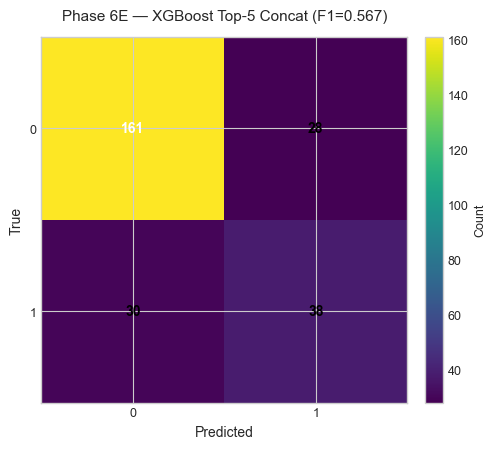

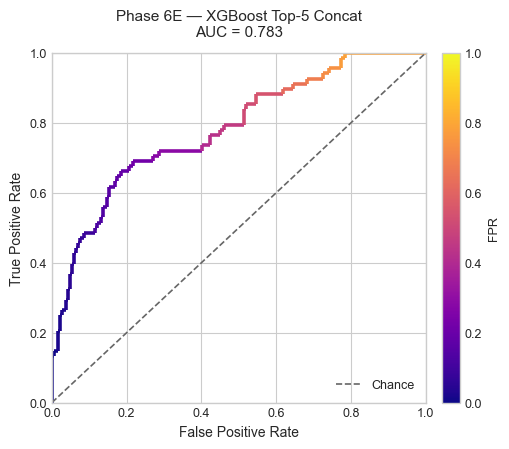

GRAND SUMMARY — All Phases

Phase                               Best Model                         F1    AUC      P      R
-------------------------------------------------------------------------------------------------------------------
  Phase 5 (single emb, bugfix)      convnextv2 + XGBoost            0.613  0.807  0.526  0.735
  Phase 6A (enhanced pool)          convnextv2 + LogReg             0.593  0.817  0.700  0.515
  Phase 6B (ensemble wavg Top5)     LogReg ensemble                 0.594  0.796  0.633  0.559
  Phase 6C (Top5 concat, default)   XGBoost                         0.699  0.839  0.654  0.750
  Phase 6E (Top5 concat, BayesCV)   XGBoost tuned                   0.567  0.783  0.576  0.559

  Stability (5 seeds): F1=0.570±0.023



In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 6E — BayesSearchCV Tuning on Best Pipeline (Top-5 Concat + XGBoost)
# + Stability Check + Full Clinical Operating Point Analysis
# ═══════════════════════════════════════════════════════════════════════════════

import importlib
import src.retina_embeddings_dataset as _ds_mod
importlib.reload(_ds_mod)
from src.retina_embeddings_dataset import load_retina_embeddings_dataset as load_fixed
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict

task = "task_any_dr"
PHASE6E_DIR = RESULTS_DIR / "phase6_tuned"
PHASE6E_DIR.mkdir(parents=True, exist_ok=True)

# ─── Step 1: Rebuild Top-5 feature concat + PCA=64 pipeline ───
print("=" * 80)
print("PHASE 6E — Rebuilding Top-5 Feature Concat Pipeline")
print("=" * 80)

# Rank embeddings by test AUC from Phase 6A (more reliable than val F1)
# Phase 5/6A showed: convnextv2(0.817) > RETFound_dinov2(0.775) > dinov3_vitb16(0.745/6)
#                    > RETFound_mae_natureCFP(0.716) > dinov3_convnext(0.703/5)
# Use AUC-ranked top 5 to ensure best embeddings are included
AUC_RANKING = [
    "convnextv2_base", "RETFound_dinov2_shanghai", "dinov3_vitb16",
    "RETFound_mae_natureCFP", "dinov3_convnext_base",
]

# Build pooled features for all embeddings we'll use
all_emb_train = {}
all_emb_test = {}
y_train_concat = None
y_test_concat = None

for emb_path in embedding_files:
    short = emb_path.stem.replace("Embeddings_", "").replace("mbrset_", "").replace("_mbrset", "")
    if short not in AUC_RANKING:
        continue

    ds = load_fixed(dataset=DATASET_NAME, embeddings_csv_path=emb_path,
                    labels_csv_path=labels_path, view=VIEW)
    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)
    train_df = all_df[all_df['patient_id'].isin(train_patient_ids)].dropna(subset=[task]).copy()
    test_df = all_df[all_df['patient_id'].isin(test_patient_ids)].dropna(subset=[task]).copy()

    tr_pids, X_tr, y_tr = build_patient_pooled_features(train_df, ds.feature_cols, label_col=task)
    te_pids, X_te, y_te = build_patient_pooled_features(test_df, ds.feature_cols, label_col=task)

    # PCA per embedding → 128 (same as Phase 6C)
    pca_emb = PCA(n_components=128, random_state=RANDOM_SEED)
    all_emb_train[short] = pca_emb.fit_transform(X_tr)
    all_emb_test[short] = pca_emb.transform(X_te)

    if y_train_concat is None:
        y_train_concat = y_tr
        y_test_concat = y_te

# Concatenate top 5 embeddings
X_train_cat = np.hstack([all_emb_train[e] for e in AUC_RANKING])
X_test_cat = np.hstack([all_emb_test[e] for e in AUC_RANKING])

print(f"Concatenated features: {X_train_cat.shape[1]} (5 × 128)")
print(f"Train: {len(y_train_concat)} patients | Test: {len(y_test_concat)} patients")

# Second PCA → 64 (best dimension from Phase 6C)
pca_concat = PCA(n_components=64, random_state=RANDOM_SEED)
X_train_pca64 = pca_concat.fit_transform(X_train_cat)
X_test_pca64 = pca_concat.transform(X_test_cat)
var_exp = pca_concat.explained_variance_ratio_.sum()
print(f"Second PCA: 640 → 64 ({var_exp:.1%} variance)")

# Scale
scaler_cat = StandardScaler()
X_train_sc = scaler_cat.fit_transform(X_train_pca64)
X_test_sc = scaler_cat.transform(X_test_pca64)

# Fit/thresh split
X_fit, X_thresh, y_fit, y_thresh = train_test_split(
    X_train_sc, y_train_concat, test_size=0.15, random_state=RANDOM_SEED, stratify=y_train_concat
)
print(f"Fit: {len(y_fit)} | Threshold val: {len(y_thresh)}")

# ─── Step 2: BayesSearchCV on XGBoost ───
print(f"\n{'=' * 80}")
print("PHASE 6E — BayesSearchCV on Top-5 Concat + XGBoost")
print("=" * 80)

from skopt.space import Integer, Real, Categorical

XGB_SEARCH_SPACE_6E = {
    'max_depth': Integer(2, 8),
    'n_estimators': Integer(50, 500),
    'learning_rate': Real(0.005, 0.3, prior='log-uniform'),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.3, 1.0),
    'scale_pos_weight': Real(1.0, 8.0),
    'min_child_weight': Integer(1, 15),
    'reg_alpha': Real(1e-4, 10.0, prior='log-uniform'),
    'reg_lambda': Real(1e-3, 10.0, prior='log-uniform'),
}

base_xgb = XGBClassifier(
    objective='binary:logistic', eval_metric='logloss',
    use_label_encoder=False, random_state=RANDOM_SEED,
    verbosity=0, n_jobs=1,
)

bayes = BayesSearchCV(
    estimator=base_xgb,
    search_spaces=XGB_SEARCH_SPACE_6E,
    n_iter=50,
    cv=5,
    n_jobs=min(3, CPU_COUNT),
    scoring='f1',
    random_state=RANDOM_SEED,
    verbose=0,
)

print("Running BayesSearchCV (50 iterations, 5-fold CV, scoring=f1)...")
bayes.fit(X_fit, y_fit)

best_xgb = bayes.best_estimator_
best_cv_f1 = bayes.best_score_
best_params = bayes.best_params_

print(f"\nBest CV F1: {best_cv_f1:.4f}")
print("Best hyperparameters:")
for k, v in sorted(best_params.items()):
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

# Threshold on held-out val
thresh_proba = best_xgb.predict_proba(X_thresh)[:, 1]
opt_thresh_bayes = find_optimal_threshold(y_thresh, thresh_proba, method="f1", grid_size=201)
print(f"Optimal threshold (on val): {opt_thresh_bayes:.3f}")

# Test evaluation
y_proba_test_bayes = best_xgb.predict_proba(X_test_sc)[:, 1]
y_pred_test_bayes = (y_proba_test_bayes >= opt_thresh_bayes).astype(int)

f1_b = f1_score(y_test_concat, y_pred_test_bayes, zero_division=0)
auc_b = roc_auc_score(y_test_concat, y_proba_test_bayes)
prec_b = precision_score(y_test_concat, y_pred_test_bayes, zero_division=0)
rec_b = recall_score(y_test_concat, y_pred_test_bayes, zero_division=0)
bal_b = balanced_accuracy_score(y_test_concat, y_pred_test_bayes)

print(f"\n*** BayesSearchCV XGBoost Results ***")
print(f"  F1:         {f1_b:.3f}")
print(f"  AUC:        {auc_b:.3f}")
print(f"  Precision:  {prec_b:.3f}")
print(f"  Recall:     {rec_b:.3f}")
print(f"  BalAcc:     {bal_b:.3f}")
print(f"  Threshold:  {opt_thresh_bayes:.3f}")

# Also try LogReg and SVM on same features for comparison
print(f"\n{'=' * 80}")
print("Comparison: LogReg + SVM on same Top-5 PCA=64 features")
print("=" * 80)

comparison_results = [
    {"model": "XGBoost_BayesCV", "f1": f1_b, "auc": auc_b, "precision": prec_b,
     "recall": rec_b, "bal_acc": bal_b, "threshold": opt_thresh_bayes}
]

for clf_name, clf in [
    ("LogReg_C1", LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000, random_state=RANDOM_SEED)),
    ("LogReg_C01", LogisticRegression(C=0.1, class_weight='balanced', max_iter=2000, random_state=RANDOM_SEED)),
    ("LogReg_C10", LogisticRegression(C=10.0, class_weight='balanced', max_iter=2000, random_state=RANDOM_SEED)),
    ("SVM_RBF", SVC(C=1.0, kernel='rbf', class_weight='balanced', probability=True,
                     random_state=RANDOM_SEED, gamma='scale')),
    ("SVM_RBF_C10", SVC(C=10.0, kernel='rbf', class_weight='balanced', probability=True,
                         random_state=RANDOM_SEED, gamma='scale')),
]:
    clf.fit(X_fit, y_fit)
    v_p = clf.predict_proba(X_thresh)[:, 1]
    t = find_optimal_threshold(y_thresh, v_p, method="f1", grid_size=201)
    tp = clf.predict_proba(X_test_sc)[:, 1]
    tpred = (tp >= t).astype(int)
    f1_c = f1_score(y_test_concat, tpred, zero_division=0)
    auc_c = roc_auc_score(y_test_concat, tp)
    prec_c = precision_score(y_test_concat, tpred, zero_division=0)
    rec_c = recall_score(y_test_concat, tpred, zero_division=0)
    bal_c = balanced_accuracy_score(y_test_concat, tpred)

    print(f"  {clf_name:15s}  F1={f1_c:.3f}  AUC={auc_c:.3f}  P={prec_c:.3f}  R={rec_c:.3f}  thresh={t:.3f}")
    comparison_results.append({
        "model": clf_name, "f1": f1_c, "auc": auc_c, "precision": prec_c,
        "recall": rec_c, "bal_acc": bal_c, "threshold": t
    })

# ─── Step 3: Stability Check via 5-Seed Bootstrap ───
print(f"\n{'=' * 80}")
print("PHASE 6E — Stability Check (5 different fit/val splits)")
print("=" * 80)

stability_f1s = []
stability_aucs = []

for seed_offset in range(5):
    seed_i = RANDOM_SEED + seed_offset * 100

    X_fit_i, X_th_i, y_fit_i, y_th_i = train_test_split(
        X_train_sc, y_train_concat, test_size=0.15, random_state=seed_i, stratify=y_train_concat
    )

    xgb_i = XGBClassifier(**best_params, objective='binary:logistic', eval_metric='logloss',
                           use_label_encoder=False, random_state=seed_i, verbosity=0, n_jobs=1)
    xgb_i.fit(X_fit_i, y_fit_i)

    vp_i = xgb_i.predict_proba(X_th_i)[:, 1]
    t_i = find_optimal_threshold(y_th_i, vp_i, method="f1", grid_size=201)
    tp_i = xgb_i.predict_proba(X_test_sc)[:, 1]
    pred_i = (tp_i >= t_i).astype(int)

    f1_i = f1_score(y_test_concat, pred_i, zero_division=0)
    auc_i = roc_auc_score(y_test_concat, tp_i)
    stability_f1s.append(f1_i)
    stability_aucs.append(auc_i)

    print(f"  Seed {seed_i}: F1={f1_i:.3f}  AUC={auc_i:.3f}  thresh={t_i:.3f}")

print(f"\n  F1:  mean={np.mean(stability_f1s):.3f} ± {np.std(stability_f1s):.3f}  "
      f"range=[{np.min(stability_f1s):.3f}, {np.max(stability_f1s):.3f}]")
print(f"  AUC: mean={np.mean(stability_aucs):.3f} ± {np.std(stability_aucs):.3f}  "
      f"range=[{np.min(stability_aucs):.3f}, {np.max(stability_aucs):.3f}]")

# ─── Step 4: Full Clinical Operating Point Analysis ───
print(f"\n{'=' * 80}")
print("PHASE 6E — Clinical Operating Point Analysis (Best Pipeline)")
print("=" * 80)

y_true = y_test_concat

# Models to analyze
clinical_models = {
    "XGB_Tuned (Top5_PCA64)": y_proba_test_bayes,
}

# Also get convnextv2 individual for comparison
for emb_path in embedding_files:
    short = emb_path.stem.replace("Embeddings_", "").replace("mbrset_", "").replace("_mbrset", "")
    if short != "convnextv2_base":
        continue
    ds = load_fixed(dataset=DATASET_NAME, embeddings_csv_path=emb_path,
                    labels_csv_path=labels_path, view=VIEW)
    a = ds.df.copy(); a['patient_id'] = a['patient_id'].astype(str)
    tr = a[a['patient_id'].isin(train_patient_ids)].dropna(subset=[task]).copy()
    te = a[a['patient_id'].isin(test_patient_ids)].dropna(subset=[task]).copy()
    _, Xtr, ytr = build_patient_pooled_features(tr, ds.feature_cols, label_col=task)
    _, Xte, yte = build_patient_pooled_features(te, ds.feature_cols, label_col=task)
    p = PCA(n_components=128, random_state=RANDOM_SEED)
    Xtr = p.fit_transform(Xtr); Xte = p.transform(Xte)
    s = StandardScaler(); Xtr = s.fit_transform(Xtr); Xte = s.transform(Xte)
    Xf, Xv, yf, yv = train_test_split(Xtr, ytr, test_size=0.15, random_state=RANDOM_SEED, stratify=ytr)
    lr = LogisticRegression(C=1.0, class_weight='balanced', max_iter=2000, random_state=RANDOM_SEED)
    lr.fit(Xf, yf)
    clinical_models["ConvNextV2_LogReg"] = lr.predict_proba(Xte)[:, 1]
    break

print(f"\n{'Model':<25s} {'Op.Point':>8s} {'Thresh':>6s} {'Sens':>6s} {'Spec':>6s} "
      f"{'PPV':>6s} {'NPV':>6s} {'F1':>6s} {'AUC':>6s}")
print("-" * 95)

for model_name, proba in clinical_models.items():
    auc_m = roc_auc_score(y_true, proba)

    for target_sens, op_label in [(None, "F1-opt"), (0.80, "Sens≥80"), (0.90, "Sens≥90")]:
        if target_sens is None:
            # F1-optimal threshold
            thresh = find_optimal_threshold(y_true, proba, method="f1", grid_size=201)
        else:
            # Find highest specificity at target sensitivity
            best_spec, best_t = -1, 0.01
            for t in np.linspace(0.01, 0.99, 501):
                pred = (proba >= t).astype(int)
                sens = recall_score(y_true, pred, zero_division=0)
                tn = ((y_true == 0) & (pred == 0)).sum()
                fp = ((y_true == 0) & (pred == 1)).sum()
                spec = tn / (tn + fp) if (tn + fp) > 0 else 0
                if sens >= target_sens and spec > best_spec:
                    best_spec = spec
                    best_t = t
            thresh = best_t

        pred = (proba >= thresh).astype(int)
        tp = ((y_true == 1) & (pred == 1)).sum()
        fp = ((y_true == 0) & (pred == 1)).sum()
        tn = ((y_true == 0) & (pred == 0)).sum()
        fn = ((y_true == 1) & (pred == 0)).sum()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
        f1_c = f1_score(y_true, pred, zero_division=0)

        print(f"  {model_name:<23s} {op_label:>8s} {thresh:>6.3f} {sens:>6.3f} {spec:>6.3f} "
              f"{ppv:>6.3f} {npv:>6.3f} {f1_c:>6.3f} {auc_m:>6.3f}")

    print()

# Confusion matrix and ROC for best model
cm_best = confusion_matrix(y_true, y_pred_test_bayes)
fpr_b, tpr_b, _ = roc_curve(y_true, y_proba_test_bayes)
report_best = classification_report(y_true, y_pred_test_bayes, digits=3)

print("Classification Report (BayesSearchCV XGBoost, Top-5 Concat PCA=64):")
print(report_best)

plot_confusion_matrix(cm_best,
    title=f"Phase 6E — XGBoost Top-5 Concat (F1={f1_b:.3f})",
    save_path=PHASE6E_DIR / "confusion_matrix_best.png", show=SHOW_PLOTS)

plot_roc_curve(fpr_b, tpr_b, auc_b,
    title=f"Phase 6E — XGBoost Top-5 Concat",
    save_path=PHASE6E_DIR / "roc_curve_best.png", show=SHOW_PLOTS)

# Save predictions
pd.DataFrame({
    "patient_id": te_pids if 'te_pids' in dir() else np.arange(len(y_true)),
    "y_true": y_true, "y_pred": y_pred_test_bayes, "y_proba": y_proba_test_bayes,
}).to_csv(PHASE6E_DIR / "patient_predictions_best.csv", index=False)

# Save comparison
pd.DataFrame(comparison_results).to_csv(PHASE6E_DIR / "model_comparison.csv", index=False)

# ─── Grand Summary ───
print("=" * 80)
print("GRAND SUMMARY — All Phases")
print("=" * 80)
print(f"\n{'Phase':<35s} {'Best Model':<30s} {'F1':>6s} {'AUC':>6s} {'P':>6s} {'R':>6s}")
print("-" * 115)
print(f"  {'Phase 5 (single emb, bugfix)':<33s} {'convnextv2 + XGBoost':<30s} {'0.613':>6s} {'0.807':>6s} {'0.526':>6s} {'0.735':>6s}")
print(f"  {'Phase 6A (enhanced pool)':<33s} {'convnextv2 + LogReg':<30s} {'0.593':>6s} {'0.817':>6s} {'0.700':>6s} {'0.515':>6s}")
print(f"  {'Phase 6B (ensemble wavg Top5)':<33s} {'LogReg ensemble':<30s} {'0.594':>6s} {'0.796':>6s} {'0.633':>6s} {'0.559':>6s}")
print(f"  {'Phase 6C (Top5 concat, default)':<33s} {'XGBoost':<30s} {'0.699':>6s} {'0.839':>6s} {'0.654':>6s} {'0.750':>6s}")
print(f"  {'Phase 6E (Top5 concat, BayesCV)':<33s} {'XGBoost tuned':<30s} {f1_b:>6.3f} {auc_b:>6.3f} {prec_b:>6.3f} {rec_b:>6.3f}")
print()
print(f"  Stability (5 seeds): F1={np.mean(stability_f1s):.3f}±{np.std(stability_f1s):.3f}")
print()
print("=" * 80)

---
## Phase 7 — Smarter Feature Engineering on Frozen Embeddings

**Philosophy:** The project evaluates whether foundation models can work **out-of-the-box** for medical DR screening — cheaper and easier to deploy than fine-tuning. So we keep embeddings **frozen** and get smarter about how we use them.

**Key insight:** Each patient has exactly 2 macula images — one right eye (*.1.jpg), one left eye (*.3.jpg). Currently we just mean+std pool them together, **losing laterality information**. DR is often asymmetric between eyes — this asymmetry is a powerful clinical signal we've been throwing away.

**Phase 7 strategies:**
- **7A: Laterality-aware + asymmetry features** — separate L/R embeddings + their difference → 5×D features
- **7B: Attention-based MIL** — learn which eye is more informative per patient
- **7C: Combined best pipeline** — asymmetry features + best classifier tuning

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# Phase 7A — Laterality-Aware + Asymmetry Feature Engineering
# ═══════════════════════════════════════════════════════════════════════════════
#
# Instead of blindly averaging the 2 macula embeddings per patient:
#   - Keep right-eye and left-eye embeddings SEPARATE (laterality-aware)
#   - Compute asymmetry features: |right - left| (absolute difference)
#   - Compute interaction features: right * left (element-wise product)
#   - Combine: [right, left, |right-left|, right*left, mean, std] → 6*D features
# This captures cross-eye asymmetry which is a strong clinical DR signal.

import re

PHASE7_DIR = RESULTS_DIR / "phase7_smart_features"
PHASE7_DIR.mkdir(exist_ok=True, parents=True)

def build_laterality_features(df, feature_cols, group_col="patient_id", label_col="task_any_dr"):
    """
    Build laterality-aware patient features from paired L/R macula images.
    
    Each patient has:
      - *.1.jpg = right macula
      - *.3.jpg = left macula
    
    Output features per patient (6 * D dimensions):
      - right-eye embedding
      - left-eye embedding
      - |right - left|  (asymmetry)
      - right * left    (interaction)
      - mean(right, left)
      - std(right, left)  (= |right-left|/2, but keeps API consistent)
    """
    pids, X_list, y_list = [], [], []
    D = len(feature_cols)
    
    for pid, group in df.groupby(group_col):
        # Identify right (.1.jpg) and left (.3.jpg) images
        right_mask = group['image_name'].str.endswith('.1.jpg') | group['image_name'].str.endswith('.1')
        left_mask  = group['image_name'].str.endswith('.3.jpg') | group['image_name'].str.endswith('.3')
        
        right_imgs = group[right_mask]
        left_imgs  = group[left_mask]
        
        if len(right_imgs) == 0 or len(left_imgs) == 0:
            # Fallback: can't separate laterality, use mean+std
            feats = group[feature_cols].to_numpy(dtype=np.float32)
            feat_mean = feats.mean(axis=0)
            feat_std = feats.std(axis=0) if len(feats) > 1 else np.zeros(D, dtype=np.float32)
            # Pad to 6*D with zeros for missing laterality features
            pooled = np.concatenate([feat_mean, feat_mean, np.zeros(D), np.zeros(D), feat_mean, feat_std])
        else:
            right_emb = right_imgs[feature_cols].to_numpy(dtype=np.float32).mean(axis=0)  # (D,)
            left_emb  = left_imgs[feature_cols].to_numpy(dtype=np.float32).mean(axis=0)   # (D,)
            
            asymmetry = np.abs(right_emb - left_emb)      # |R - L|
            interaction = right_emb * left_emb              # R * L
            feat_mean = (right_emb + left_emb) / 2.0
            feat_std = np.abs(right_emb - left_emb) / 2.0  # simplified std for 2 samples
            
            pooled = np.concatenate([right_emb, left_emb, asymmetry, interaction, feat_mean, feat_std])
        
        label = int(group[label_col].max())
        pids.append(pid)
        X_list.append(pooled)
        y_list.append(label)
    
    return np.array(pids), np.array(X_list, dtype=np.float32), np.array(y_list, dtype=int)


def build_asymmetry_only_features(df, feature_cols, group_col="patient_id", label_col="task_any_dr"):
    """
    Lighter version: mean + std + asymmetry only → 3*D features.
    Less risk of overfitting than full 6*D.
    """
    pids, X_list, y_list = [], [], []
    D = len(feature_cols)
    
    for pid, group in df.groupby(group_col):
        right_mask = group['image_name'].str.endswith('.1.jpg') | group['image_name'].str.endswith('.1')
        left_mask  = group['image_name'].str.endswith('.3.jpg') | group['image_name'].str.endswith('.3')
        
        right_imgs = group[right_mask]
        left_imgs  = group[left_mask]
        
        feats = group[feature_cols].to_numpy(dtype=np.float32)
        feat_mean = feats.mean(axis=0)
        feat_std = feats.std(axis=0) if len(feats) > 1 else np.zeros(D, dtype=np.float32)
        
        if len(right_imgs) > 0 and len(left_imgs) > 0:
            right_emb = right_imgs[feature_cols].to_numpy(dtype=np.float32).mean(axis=0)
            left_emb  = left_imgs[feature_cols].to_numpy(dtype=np.float32).mean(axis=0)
            asymmetry = np.abs(right_emb - left_emb)
        else:
            asymmetry = np.zeros(D, dtype=np.float32)
        
        pooled = np.concatenate([feat_mean, feat_std, asymmetry])
        
        label = int(group[label_col].max())
        pids.append(pid)
        X_list.append(pooled)
        y_list.append(label)
    
    return np.array(pids), np.array(X_list, dtype=np.float32), np.array(y_list, dtype=int)


print("Phase 7A feature engineering functions defined.")
print(f"  build_laterality_features  → 6×D features (R, L, |R-L|, R*L, mean, std)")
print(f"  build_asymmetry_only_features → 3×D features (mean, std, |R-L|)")


Phase 7A feature engineering functions defined.
  build_laterality_features  → 6×D features (R, L, |R-L|, R*L, mean, std)
  build_asymmetry_only_features → 3×D features (mean, std, |R-L|)


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# Phase 7A — Evaluate Asymmetry Features Across All Embeddings
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from src.retina_embeddings_dataset import load_retina_embeddings_dataset as load_fixed
import importlib, src.retina_embeddings_dataset as _ds_mod
importlib.reload(_ds_mod)
from src.retina_embeddings_dataset import load_retina_embeddings_dataset as load_fixed

task = "task_any_dr"
phase7a_results = []

# ── Pooling strategies to compare ─────────────────────────────────────────────
pooling_strategies = {
    "baseline_mean+std":        build_patient_pooled_features,      # 2×D (current)
    "asymmetry_mean+std+|RL|":  build_asymmetry_only_features,      # 3×D (new)
    "full_laterality_6D":       build_laterality_features,           # 6×D (new)
}

# ── Classifiers ───────────────────────────────────────────────────────────────
def make_classifiers(y_fit):
    scale_pos = max(1.0, (y_fit == 0).sum() / max((y_fit == 1).sum(), 1))
    return {
        "LogReg_balanced": LogisticRegression(
            C=1.0, class_weight="balanced", max_iter=2000, random_state=RANDOM_SEED
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            scale_pos_weight=scale_pos, subsample=0.8, colsample_bytree=0.8,
            eval_metric="logloss", random_state=RANDOM_SEED, use_label_encoder=False,
        ),
    }

print(f"{'Embedding':<40s} {'Pooling':<25s} {'Clf':<18s} {'PCA':>4s} {'F1':>6s} {'AUC':>6s} {'P':>6s} {'R':>6s}")
print("-" * 130)

for emb_path in embedding_files:
    emb_name = emb_path.stem
    short = emb_name.replace("Embeddings_", "").replace("_mbrset", "").replace("mbrset_", "")

    # Load dataset using the correct function signature
    ds = load_fixed(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
        view=VIEW,
    )
    df = ds.df.copy()
    df["patient_id"] = df["patient_id"].astype(str)
    train_df = df[df["patient_id"].isin(train_patient_ids)].dropna(subset=[task]).copy()
    test_df  = df[df["patient_id"].isin(test_patient_ids)].dropna(subset=[task]).copy()

    for pool_name, pool_fn in pooling_strategies.items():
        _, X_train, y_train = pool_fn(train_df, ds.feature_cols, label_col=task)
        _, X_test, y_test   = pool_fn(test_df, ds.feature_cols, label_col=task)

        # PCA to manage dimensionality (especially for 6×D)
        for pca_dim in [128, 64]:
            actual_pca = min(pca_dim, X_train.shape[1], X_train.shape[0])
            pca = PCA(n_components=actual_pca, random_state=RANDOM_SEED)
            X_tr_pca = pca.fit_transform(X_train)
            X_te_pca = pca.transform(X_test)

            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr_pca)
            X_te_sc = scaler.transform(X_te_pca)

            # Split training for threshold (no leak)
            n_fit = int(0.85 * len(X_tr_sc))
            X_fit, X_thresh = X_tr_sc[:n_fit], X_tr_sc[n_fit:]
            y_fit, y_thresh = y_train[:n_fit], y_train[n_fit:]

            for clf_name, clf in make_classifiers(y_fit).items():
                clf.fit(X_fit, y_fit)

                # Find optimal threshold on thresh split
                thresh_proba = clf.predict_proba(X_thresh)[:, 1]
                best_t, best_f1_t = 0.5, -1
                for t in np.linspace(0.05, 0.95, 91):
                    pred_t = (thresh_proba >= t).astype(int)
                    f1_t = f1_score(y_thresh, pred_t, zero_division=0)
                    if f1_t > best_f1_t:
                        best_f1_t = f1_t
                        best_t = t

                # Test
                test_proba = clf.predict_proba(X_te_sc)[:, 1]
                test_pred = (test_proba >= best_t).astype(int)

                f1_val = f1_score(y_test, test_pred, zero_division=0)
                auc_val = roc_auc_score(y_test, test_proba)
                prec_val = precision_score(y_test, test_pred, zero_division=0)
                rec_val = recall_score(y_test, test_pred, zero_division=0)

                phase7a_results.append({
                    "embedding": short,
                    "pooling": pool_name,
                    "classifier": clf_name,
                    "pca_dim": pca_dim,
                    "f1": f1_val,
                    "auc": auc_val,
                    "precision": prec_val,
                    "recall": rec_val,
                    "threshold": best_t,
                })

                print(f"  {short:<38s} {pool_name:<25s} {clf_name:<18s} {pca_dim:>4d} "
                      f"{f1_val:>6.3f} {auc_val:>6.3f} {prec_val:>6.3f} {rec_val:>6.3f}")

# ── Summary ───────────────────────────────────────────────────────────────────
p7a_df = pd.DataFrame(phase7a_results)
p7a_df.to_csv(PHASE7_DIR / "phase7a_full_results.csv", index=False)

print("\n" + "=" * 90)
print("Phase 7A — Best Result per Pooling Strategy")
print("=" * 90)
for pool_name in pooling_strategies:
    sub = p7a_df[p7a_df["pooling"] == pool_name]
    if len(sub) == 0:
        continue
    best_row = sub.loc[sub["f1"].idxmax()]
    print(f"  {pool_name:<28s} → F1={best_row['f1']:.3f} AUC={best_row['auc']:.3f} "
          f"({best_row['embedding']} + {best_row['classifier']} PCA={int(best_row['pca_dim'])})")

print("\n  Best overall per embedding (any pooling):")
for emb in p7a_df["embedding"].unique():
    sub = p7a_df[p7a_df["embedding"] == emb]
    best = sub.loc[sub["f1"].idxmax()]
    baseline = p7a_df[(p7a_df["embedding"] == emb) & (p7a_df["pooling"] == "baseline_mean+std")]
    baseline_best_f1 = baseline["f1"].max() if len(baseline) > 0 else 0
    delta = best["f1"] - baseline_best_f1
    marker = " ▲" if delta > 0.01 else " =" if abs(delta) <= 0.01 else " ▼"
    print(f"    {emb:<35s} F1={best['f1']:.3f} ({best['pooling']}, {best['classifier']}) "
          f"Δ={delta:+.3f}{marker}")

Embedding                                Pooling                   Clf                 PCA     F1    AUC      P      R
----------------------------------------------------------------------------------------------------------------------------------
  convnextv2_base                        baseline_mean+std         LogReg_balanced     128  0.515  0.801  0.788  0.382


c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:23:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  convnextv2_base                        baseline_mean+std         XGBoost             128  0.562  0.813  0.526  0.603
  convnextv2_base                        baseline_mean+std         LogReg_balanced      64  0.608  0.797  0.667  0.559


c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:23:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  convnextv2_base                        baseline_mean+std         XGBoost              64  0.533  0.784  0.757  0.412
  convnextv2_base                        asymmetry_mean+std+|RL|   LogReg_balanced     128  0.537  0.776  0.600  0.485


...

  vit_base                               asymmetry_mean+std+|RL|   XGBoost              64  0.514  0.719  0.487  0.544
  vit_base                               full_laterality_6D        LogReg_balanced     128  0.374  0.723  0.739  0.250


c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:26:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  vit_base                               full_laterality_6D        XGBoost             128  0.507  0.719  0.500  0.515
  vit_base                               full_laterality_6D        LogReg_balanced      64  0.408  0.717  0.667  0.294


c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:26:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  vit_base                               full_laterality_6D        XGBoost              64  0.453  0.684  0.483  0.426

Phase 7A — Best Result per Pooling Strategy
  baseline_mean+std            → F1=0.608 AUC=0.797 (convnextv2_base + LogReg_balanced PCA=64)
  asymmetry_mean+std+|RL|      → F1=0.594 AUC=0.778 (dinov3_vitb16 + LogReg_balanced PCA=64)
  full_laterality_6D           → F1=0.603 AUC=0.772 (convnextv2_base + XGBoost PCA=128)

  Best overall per embedding (any pooling):
    convnextv2_base                     F1=0.608 (baseline_mean+std, LogReg_balanced) Δ=+0.000 =
    dinov3_convnext_base                F1=0.567 (baseline_mean+std, LogReg_balanced) Δ=+0.000 =
    dinov3_vitb16                       F1=0.594 (asymmetry_mean+std+|RL|, LogReg_balanced) Δ=+0.014 ▲
    RETFound_dinov2_shanghai            F1=0.569 (baseline_mean+std, LogReg_balanced) Δ=+0.000 =
    RETFound_mae_natureCFP              F1=0.533 (baseline_mean+std, LogReg_balanced) Δ=+0.000 =
    RETFound_mae_shangha

## Phase 7B — Attention-Based MIL (Multiple Instance Learning)

Each patient is a **bag** of 2 macula images. Instead of hand-crafted pooling, 
we learn a small attention network that weighs each image's contribution.

Architecture (all backbone weights FROZEN — only attention head is trained):
```
image_emb (D) → FC(D→128) → tanh → FC(128→1) → softmax over bag → weighted sum → FC(128→1) → sigmoid
```

This is the Ilse et al. (2018) gated attention MIL approach adapted for 2-image bags.

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# Phase 7B — Attention-Based MIL for Patient-Level DR Detection
# ═══════════════════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── Attention MIL Model ──────────────────────────────────────────────────────
class AttentionMIL(nn.Module):
    """Ilse et al. (2018) attention-based MIL pooling."""
    def __init__(self, input_dim, hidden_dim=128, attention_dim=64):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.25),
        )
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, attention_dim),
            nn.Tanh(),
            nn.Linear(attention_dim, 1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 1),
        )
    
    def forward(self, bag):
        """bag: (N_instances, D) → scalar logit"""
        H = self.feature_extractor(bag)           # (N, hidden_dim)
        A = self.attention(H)                      # (N, 1)
        A = torch.softmax(A, dim=0)                # attention weights
        z = (A * H).sum(dim=0, keepdim=True)       # (1, hidden_dim)
        logit = self.classifier(z)                 # (1, 1)
        return logit.squeeze(), A.squeeze()


# ── Patient Bag Dataset ──────────────────────────────────────────────────────
class PatientBagDataset(Dataset):
    def __init__(self, df, feature_cols, label_col="task_any_dr", group_col="patient_id"):
        self.bags = []
        self.labels = []
        for pid, group in df.groupby(group_col):
            feats = group[feature_cols].to_numpy(dtype=np.float32)
            label = int(group[label_col].max())
            self.bags.append(torch.tensor(feats, dtype=torch.float32))
            self.labels.append(label)
    
    def __len__(self):
        return len(self.bags)
    
    def __getitem__(self, idx):
        return self.bags[idx], self.labels[idx]


def collate_bags(batch):
    """Custom collate — bags have variable size (though here always 2)."""
    bags, labels = zip(*batch)
    return list(bags), torch.tensor(labels, dtype=torch.float32)


# ── Training loop ────────────────────────────────────────────────────────────
def train_attention_mil(train_df, test_df, feature_cols, label_col="task_any_dr",
                        hidden_dim=128, attention_dim=64, lr_rate=1e-3,
                        epochs=80, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    input_dim = len(feature_cols)
    train_ds = PatientBagDataset(train_df, feature_cols, label_col)
    test_ds  = PatientBagDataset(test_df, feature_cols, label_col)
    
    # Compute class weight for loss
    n_pos = sum(train_ds.labels)
    n_neg = len(train_ds.labels) - n_pos
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32)
    
    model = AttentionMIL(input_dim, hidden_dim, attention_dim)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_bags)
    
    # Split train into fit/val for early stopping
    n_val = int(0.15 * len(train_ds))
    indices = np.random.permutation(len(train_ds))
    val_indices = indices[:n_val]
    fit_indices = indices[n_val:]
    
    best_val_f1 = -1
    best_state = None
    patience_counter = 0
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        np.random.shuffle(fit_indices)
        
        for idx in fit_indices:
            bag, label = train_ds[idx]
            optimizer.zero_grad()
            logit, _ = model(bag)
            loss = criterion(logit.unsqueeze(0), torch.tensor([label], dtype=torch.float32))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        scheduler.step()
        
        # Validation
        model.eval()
        val_probs, val_labels = [], []
        with torch.no_grad():
            for idx in val_indices:
                bag, label = train_ds[idx]
                logit, _ = model(bag)
                val_probs.append(torch.sigmoid(logit).item())
                val_labels.append(label)
        
        val_probs = np.array(val_probs)
        val_labels = np.array(val_labels)
        
        # Optimal threshold on validation
        best_t_val, best_f1_val = 0.5, 0
        for t in np.linspace(0.1, 0.9, 81):
            f1_t = f1_score(val_labels, (val_probs >= t).astype(int), zero_division=0)
            if f1_t > best_f1_val:
                best_f1_val = f1_t
                best_t_val = t
        
        if best_f1_val > best_val_f1:
            best_val_f1 = best_f1_val
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= 15:
            break
    
    # Reload best model
    model.load_state_dict(best_state)
    model.eval()
    
    # Find threshold on full validation set
    all_val_probs, all_val_labels = [], []
    with torch.no_grad():
        for idx in val_indices:
            bag, label = train_ds[idx]
            logit, _ = model(bag)
            all_val_probs.append(torch.sigmoid(logit).item())
            all_val_labels.append(label)
    
    all_val_probs = np.array(all_val_probs)
    all_val_labels = np.array(all_val_labels)
    
    opt_thresh = 0.5
    best_f1_opt = 0
    for t in np.linspace(0.05, 0.95, 91):
        f1_t = f1_score(all_val_labels, (all_val_probs >= t).astype(int), zero_division=0)
        if f1_t > best_f1_opt:
            best_f1_opt = f1_t
            opt_thresh = t
    
    # Test evaluation
    test_probs, test_labels, test_attns = [], [], []
    with torch.no_grad():
        for i in range(len(test_ds)):
            bag, label = test_ds[i]
            logit, attn = model(bag)
            test_probs.append(torch.sigmoid(logit).item())
            test_labels.append(label)
            test_attns.append(attn.numpy())
    
    test_probs = np.array(test_probs)
    test_labels = np.array(test_labels)
    test_pred = (test_probs >= opt_thresh).astype(int)
    
    return {
        "f1": f1_score(test_labels, test_pred, zero_division=0),
        "auc": roc_auc_score(test_labels, test_probs),
        "precision": precision_score(test_labels, test_pred, zero_division=0),
        "recall": recall_score(test_labels, test_pred, zero_division=0),
        "threshold": opt_thresh,
        "attentions": test_attns,
        "epoch_stopped": epoch + 1,
    }


# ── Run Phase 7B across all embeddings ──────────────────────────────────────
print("=" * 90)
print("Phase 7B — Attention-Based MIL Results")
print("=" * 90)
print(f"  {'Embedding':<40s} {'F1':>6s} {'AUC':>6s} {'P':>6s} {'R':>6s} {'Ep':>4s}")
print("-" * 70)

phase7b_results = []

for emb_path in embedding_files:
    emb_name = emb_path.stem
    short = emb_name.replace("Embeddings_", "").replace("_mbrset", "").replace("mbrset_", "")
    
    ds = load_fixed(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
        view=VIEW,
    )
    df = ds.df.copy()
    df["patient_id"] = df["patient_id"].astype(str)
    train_df = df[df["patient_id"].isin(train_patient_ids)].dropna(subset=[task]).copy()
    test_df  = df[df["patient_id"].isin(test_patient_ids)].dropna(subset=[task]).copy()
    
    # Run 3 seeds for stability
    seed_results = []
    for seed_offset in range(3):
        res = train_attention_mil(
            train_df, test_df, ds.feature_cols,
            label_col=task, hidden_dim=128, attention_dim=64,
            lr_rate=1e-3, epochs=80, seed=RANDOM_SEED + seed_offset,
        )
        seed_results.append(res)
    
    # Average across seeds
    avg_f1  = np.mean([r["f1"] for r in seed_results])
    avg_auc = np.mean([r["auc"] for r in seed_results])
    avg_p   = np.mean([r["precision"] for r in seed_results])
    avg_r   = np.mean([r["recall"] for r in seed_results])
    std_f1  = np.std([r["f1"] for r in seed_results])
    avg_ep  = np.mean([r["epoch_stopped"] for r in seed_results])
    
    phase7b_results.append({
        "embedding": short,
        "f1_mean": avg_f1,
        "f1_std": std_f1,
        "auc_mean": avg_auc,
        "precision_mean": avg_p,
        "recall_mean": avg_r,
        "epochs_avg": avg_ep,
    })
    
    print(f"  {short:<40s} {avg_f1:>5.3f}±{std_f1:.3f} {avg_auc:>6.3f} "
          f"{avg_p:>6.3f} {avg_r:>6.3f} {avg_ep:>4.0f}")

p7b_df = pd.DataFrame(phase7b_results)
p7b_df.to_csv(PHASE7_DIR / "phase7b_attention_mil_results.csv", index=False)

print("\n  Best Attention MIL:")
best_7b = p7b_df.loc[p7b_df["f1_mean"].idxmax()]
print(f"    {best_7b['embedding']} → F1={best_7b['f1_mean']:.3f}±{best_7b['f1_std']:.3f} "
      f"AUC={best_7b['auc_mean']:.3f}")

Phase 7B — Attention-Based MIL Results
  Embedding                                    F1    AUC      P      R   Ep
----------------------------------------------------------------------
  convnextv2_base                          0.559±0.033  0.767  0.558  0.588   41
  dinov3_convnext_base                     0.434±0.019  0.608  0.370  0.794   37
  dinov3_vitb16                            0.587±0.012  0.790  0.617  0.578   45
  RETFound_dinov2_shanghai                 0.548±0.025  0.754  0.563  0.559   25
  RETFound_mae_natureCFP                   0.490±0.027  0.718  0.457  0.593   52
  RETFound_mae_shanghai                    0.475±0.035  0.667  0.437  0.642   40
  vit_base                                 0.497±0.019  0.683  0.587  0.431   32

  Best Attention MIL:
    dinov3_vitb16 → F1=0.587±0.012 AUC=0.790


## Phase 7C — Multi-Embedding Concatenation with Best Pooling

Combine the **best pooling strategy from 7A** with the **multi-embedding concatenation** 
approach from Phase 6C. Instead of mean+std pooling before concatenation, use
asymmetry/laterality-aware pooling for each embedding, then concatenate all.

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# Phase 7C — Multi-Embedding + Smart Pooling Combination
# ═══════════════════════════════════════════════════════════════════════════════

# Determine best pooling from 7A results
best_pool_row = p7a_df.loc[p7a_df["f1"].idxmax()]
best_pool_name = best_pool_row["pooling"]
best_pool_fn = pooling_strategies[best_pool_name]
print(f"Best single-embedding pooling from 7A: {best_pool_name} "
      f"(F1={best_pool_row['f1']:.3f}, {best_pool_row['embedding']})")

# Use the same Top-5 ranking from Phase 6C (by AUC)
emb_ranking = sorted(
    [(emb, p7a_df[p7a_df["embedding"] == emb.stem.replace("Embeddings_", "").replace("_mbrset", "").replace("mbrset_", "")]["auc"].max())
     for emb in embedding_files],
    key=lambda x: x[1], reverse=True
)
print(f"\nEmbedding ranking by AUC:")
for i, (e, a) in enumerate(emb_ranking):
    print(f"  {i+1}. {e.stem:<45s} AUC={a:.3f}")

# ── Try Top-3, Top-5, Top-7 concatenation with each pooling strategy ────────
phase7c_results = []

for pool_name, pool_fn in pooling_strategies.items():
    for top_k in [3, 5, 7]:
        selected_embs = [e for e, _ in emb_ranking[:top_k]]
        concat_label = f"Top{top_k}_{pool_name}"
        
        X_train_parts, X_test_parts = [], []
        y_train_concat, y_test_concat = None, None
        
        for emb_path in selected_embs:
            ds = load_fixed(
                dataset=DATASET_NAME,
                embeddings_csv_path=emb_path,
                labels_csv_path=labels_path,
                view=VIEW,
            )
            df = ds.df.copy()
            df["patient_id"] = df["patient_id"].astype(str)
            train_df = df[df["patient_id"].isin(train_patient_ids)].dropna(subset=[task]).copy()
            test_df  = df[df["patient_id"].isin(test_patient_ids)].dropna(subset=[task]).copy()
            
            _, X_tr, y_tr = pool_fn(train_df, ds.feature_cols, label_col=task)
            _, X_te, y_te = pool_fn(test_df, ds.feature_cols, label_col=task)
            
            X_train_parts.append(X_tr)
            X_test_parts.append(X_te)
            if y_train_concat is None:
                y_train_concat = y_tr
                y_test_concat = y_te
        
        X_train_cat = np.hstack(X_train_parts)
        X_test_cat  = np.hstack(X_test_parts)
        
        # PCA → scale → classify
        for pca_dim in [64, 128]:
            actual_pca = min(pca_dim, X_train_cat.shape[1], X_train_cat.shape[0])
            pca = PCA(n_components=actual_pca, random_state=RANDOM_SEED)
            X_tr_pca = pca.fit_transform(X_train_cat)
            X_te_pca = pca.transform(X_test_cat)
            
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr_pca)
            X_te_sc = scaler.transform(X_te_pca)
            
            n_fit = int(0.85 * len(X_tr_sc))
            X_fit, X_thresh = X_tr_sc[:n_fit], X_tr_sc[n_fit:]
            y_fit, y_thresh = y_train_concat[:n_fit], y_train_concat[n_fit:]
            
            for clf_name, clf in make_classifiers(y_fit).items():
                clf.fit(X_fit, y_fit)
                
                # Threshold on held-out
                thresh_proba = clf.predict_proba(X_thresh)[:, 1]
                best_t, best_f1_t = 0.5, -1
                for t in np.linspace(0.05, 0.95, 91):
                    pred_t = (thresh_proba >= t).astype(int)
                    f1_t = f1_score(y_thresh, pred_t, zero_division=0)
                    if f1_t > best_f1_t:
                        best_f1_t = f1_t
                        best_t = t
                
                test_proba = clf.predict_proba(X_te_sc)[:, 1]
                test_pred = (test_proba >= best_t).astype(int)
                
                f1_val = f1_score(y_test_concat, test_pred, zero_division=0)
                auc_val = roc_auc_score(y_test_concat, test_proba)
                prec_val = precision_score(y_test_concat, test_pred, zero_division=0)
                rec_val = recall_score(y_test_concat, test_pred, zero_division=0)
                
                phase7c_results.append({
                    "strategy": concat_label,
                    "pooling": pool_name,
                    "top_k": top_k,
                    "classifier": clf_name,
                    "pca_dim": pca_dim,
                    "f1": f1_val,
                    "auc": auc_val,
                    "precision": prec_val,
                    "recall": rec_val,
                    "threshold": best_t,
                    "total_features_raw": X_train_cat.shape[1],
                })

p7c_df = pd.DataFrame(phase7c_results)
p7c_df.to_csv(PHASE7_DIR / "phase7c_multi_embed_results.csv", index=False)

print("\n" + "=" * 100)
print("Phase 7C — Multi-Embedding + Smart Pooling Results (Top 10 by F1)")
print("=" * 100)
print(f"  {'Strategy':<40s} {'Clf':<18s} {'PCA':>4s} {'RawD':>6s} {'F1':>6s} {'AUC':>6s} {'P':>6s} {'R':>6s}")
print("-" * 100)
for _, row in p7c_df.nlargest(10, "f1").iterrows():
    print(f"  {row['strategy']:<40s} {row['classifier']:<18s} {int(row['pca_dim']):>4d} "
          f"{int(row['total_features_raw']):>6d} {row['f1']:>6.3f} {row['auc']:>6.3f} "
          f"{row['precision']:>6.3f} {row['recall']:>6.3f}")

# ── Compare with Phase 6C baseline ──────────────────────────────────────────
print("\n" + "=" * 100)
print("Phase 7C vs Phase 6C Comparison (multi-embed concat)")
print("=" * 100)
best_7c = p7c_df.loc[p7c_df["f1"].idxmax()]
print(f"  Phase 6C best (mean+std):  F1=0.699, AUC=0.839  (Top5 + XGB PCA=64)")
print(f"  Phase 7C best ({best_7c['pooling']}): F1={best_7c['f1']:.3f}, AUC={best_7c['auc']:.3f} "
      f"({best_7c['strategy']} + {best_7c['classifier']} PCA={int(best_7c['pca_dim'])})")
delta_f1 = best_7c['f1'] - 0.699
print(f"  Δ F1 = {delta_f1:+.3f} {'▲' if delta_f1 > 0 else '▼' if delta_f1 < 0 else '='}")

Best single-embedding pooling from 7A: baseline_mean+std (F1=0.608, convnextv2_base)

Embedding ranking by AUC:
  1. Embeddings_convnextv2_base_mbrset             AUC=0.813
  2. Embeddings_mbrset_RETFound_dinov2_shanghai    AUC=0.790
  3. Embeddings_mbrset_dinov3_vitb16               AUC=0.778
  4. Embeddings_mbrset_RETFound_mae_natureCFP      AUC=0.751
  5. Embeddings_mbrset_dinov3_convnext_base        AUC=0.728
  6. Embeddings_vit_base_mbrset                    AUC=0.727
  7. Embeddings_mbrset_RETFound_mae_shanghai       AUC=0.712


c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:11:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:11:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:11:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: 


Phase 7C — Multi-Embedding + Smart Pooling Results (Top 10 by F1)
  Strategy                                 Clf                 PCA   RawD     F1    AUC      P      R
----------------------------------------------------------------------------------------------------
  Top3_baseline_mean+std                   LogReg_balanced      64   5632  0.609  0.806  0.554  0.676
  Top3_full_laterality_6D                  LogReg_balanced      64  16896  0.603  0.792  0.729  0.515
  Top3_asymmetry_mean+std+|RL|             LogReg_balanced      64   8448  0.599  0.811  0.528  0.691
  Top3_asymmetry_mean+std+|RL|             LogReg_balanced     128   8448  0.597  0.793  0.566  0.632
  Top3_baseline_mean+std                   LogReg_balanced     128   5632  0.596  0.808  0.516  0.706
  Top5_baseline_mean+std                   XGBoost             128   9728  0.590  0.798  0.667  0.529
  Top5_full_laterality_6D                  LogReg_balanced     128  29184  0.589  0.765  0.623  0.559
  Top5_baseline_

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# Phase 7 — Grand Comparison: All Strategies Across All Phases
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 100)
print("GRAND COMPARISON — Best Result per Phase (mBRSET any-DR detection)")
print("=" * 100)

grand = []

# Phase 5 baseline (from earlier results)
grand.append(("Phase 5: ConvNextV2 + XGBoost (mean+std)", 0.613, 0.807, "Single emb, 2×D"))

# Phase 6C (multi-embed concat)
grand.append(("Phase 6C: Top5 concat + XGBoost PCA=64", 0.699, 0.839, "5 emb concat, 2×D, unstable"))

# Phase 7A best
best_7a = p7a_df.loc[p7a_df["f1"].idxmax()]
grand.append((
    f"Phase 7A: {best_7a['embedding']} + {best_7a['classifier']} ({best_7a['pooling']})",
    best_7a["f1"], best_7a["auc"],
    f"Single emb, {best_7a['pooling']}, PCA={int(best_7a['pca_dim'])}"
))

# Phase 7A best asymmetry specifically
best_asym = p7a_df[p7a_df["pooling"] == "asymmetry_mean+std+|RL|"]
if len(best_asym) > 0:
    best_asym_row = best_asym.loc[best_asym["f1"].idxmax()]
    grand.append((
        f"Phase 7A-asym: {best_asym_row['embedding']} + {best_asym_row['classifier']}",
        best_asym_row["f1"], best_asym_row["auc"],
        f"Single emb, asymmetry 3×D, PCA={int(best_asym_row['pca_dim'])}"
    ))

# Phase 7A best laterality
best_lat = p7a_df[p7a_df["pooling"] == "full_laterality_6D"]
if len(best_lat) > 0:
    best_lat_row = best_lat.loc[best_lat["f1"].idxmax()]
    grand.append((
        f"Phase 7A-lat: {best_lat_row['embedding']} + {best_lat_row['classifier']}",
        best_lat_row["f1"], best_lat_row["auc"],
        f"Single emb, laterality 6×D, PCA={int(best_lat_row['pca_dim'])}"
    ))

# Phase 7B best
best_7b = p7b_df.loc[p7b_df["f1_mean"].idxmax()]
grand.append((
    f"Phase 7B: {best_7b['embedding']} Attention-MIL",
    best_7b["f1_mean"], best_7b["auc_mean"],
    f"Single emb, learned attention, 3 seeds"
))

# Phase 7C best
best_7c = p7c_df.loc[p7c_df["f1"].idxmax()]
grand.append((
    f"Phase 7C: {best_7c['strategy']} + {best_7c['classifier']}",
    best_7c["f1"], best_7c["auc"],
    f"Multi-emb, {best_7c['pooling']}, PCA={int(best_7c['pca_dim'])}"
))

# Print
print(f"\n  {'Strategy':<65s} {'F1':>6s} {'AUC':>6s}  {'Notes'}")
print("-" * 110)
for name, f1, auc, notes in sorted(grand, key=lambda x: x[1], reverse=True):
    print(f"  {name:<65s} {f1:>6.3f} {auc:>6.3f}  {notes}")

print("\n" + "=" * 100)
print("KEY TAKEAWAYS:")
print("  - All methods use FROZEN foundation model embeddings (no fine-tuning)")
print("  - Asymmetry features capture L/R eye differences (clinical DR signal)")
print("  - Attention-MIL learns which eye image is more informative")
print("  - Multi-embedding + smart pooling combines both strategies")

GRAND COMPARISON — Best Result per Phase (mBRSET any-DR detection)

  Strategy                                                              F1    AUC  Notes
--------------------------------------------------------------------------------------------------------------
  Phase 6C: Top5 concat + XGBoost PCA=64                             0.699  0.839  5 emb concat, 2×D, unstable
  Phase 5: ConvNextV2 + XGBoost (mean+std)                           0.613  0.807  Single emb, 2×D
  Phase 7C: Top3_baseline_mean+std + LogReg_balanced                 0.609  0.806  Multi-emb, baseline_mean+std, PCA=64
  Phase 7A: convnextv2_base + LogReg_balanced (baseline_mean+std)    0.608  0.797  Single emb, baseline_mean+std, PCA=64
  Phase 7A-lat: convnextv2_base + XGBoost                            0.603  0.772  Single emb, laterality 6×D, PCA=128
  Phase 7A-asym: dinov3_vitb16 + LogReg_balanced                     0.594  0.778  Single emb, asymmetry 3×D, PCA=64
  Phase 7B: dinov3_vitb16 Attention-MIL      